# Workflow 2

# Phase VII
## Site Harmonization and Classical Statistical Validation
### Objectives

This notebook performs the final classical statistical analysis of the
dynamic graph metrics before representation learning.

The goals are
1. quantify site effects
2. quantify diagnosis effects
3. statistically control acquisition-site variability
4. harmonize graph metrics using ComBat
5. validate harmonization
6. establish the classical baseline that later GNN/DANN models must outperform

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import pearsonr

from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
PROJECT_ROOT = Path("/home/nvidia/23BRS1236")
DATA_ROOT = PROJECT_ROOT / "adhd_data"
WORKFLOW2_ROOT = DATA_ROOT / "workflow2"
V6_ROOT = WORKFLOW2_ROOT / "v6"
OUTPUT_DIR = WORKFLOW2_ROOT / "v7"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

GRAPH_DATASET = (
    V6_ROOT /
    "graph_ml_dataset_v2.parquet"
)

print("Project Root :", PROJECT_ROOT)
print("Data Root    :", DATA_ROOT)
print("Workflow2    :", WORKFLOW2_ROOT)
print("Output       :", OUTPUT_DIR)
print()
print("Dataset")
print(GRAPH_DATASET)
print()
print("Exists :", GRAPH_DATASET.exists())

Project Root : /home/nvidia/23BRS1236
Data Root    : /home/nvidia/23BRS1236/adhd_data
Workflow2    : /home/nvidia/23BRS1236/adhd_data/workflow2
Output       : /home/nvidia/23BRS1236/adhd_data/workflow2/v7

Dataset
/home/nvidia/23BRS1236/adhd_data/workflow2/v6/graph_ml_dataset_v2.parquet

Exists : True


In [5]:
RAW_FEATURES = [
    "avg_strength",
    "clustering",
    "transitivity",
    "efficiency_global",
    "efficiency_local",
    "path_length"
]

NULL_FEATURES = [
    "null_clustering",
    "null_transitivity",
    "null_efficiency",
    "null_path_length",
    "gamma",
    "lambda",
    "sigma"
]

METADATA = [
    "subject_id",
    "site",
    "session",
    "run",
    "window_index",
    "label",
    "Age",
    "Gender",
    "Handedness"
]

In [3]:
graph = pd.read_parquet(GRAPH_DATASET)
print("="*80)
print("Canonical Dataset")
print("="*80)
print("Shape :", graph.shape)
print()

print(graph.columns.tolist())

display(graph.head())

Canonical Dataset
Shape : (31060, 29)

['nodes', 'edges', 'density', 'components', 'avg_degree', 'avg_strength', 'clustering', 'transitivity', 'efficiency_global', 'efficiency_local', 'path_length', 'builder', 'distance_metric', 'subject_id', 'site', 'session', 'run', 'window_index', 'label', 'Age', 'Gender', 'Handedness', 'null_clustering', 'null_transitivity', 'null_efficiency', 'null_path_length', 'gamma', 'lambda', 'sigma']


,nodes,edges,density,components,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,builder,distance_metric,subject_id,site,session,run,window_index,label,Age,Gender,Handedness,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma
0,190,3591,0.2,1,37.8,25.236876,0.342180,0.558689,0.571893,0.720297,0.600203,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,0,0,12.36,0.0,1.0,0.345911,0.391120,0.386014,2.946965,1.034462,0.996910,1.037668
1,190,3591,0.2,1,37.8,24.667315,0.331305,0.538590,0.577439,0.721905,0.616338,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,1,0,12.36,0.0,1.0,0.328007,0.369279,0.383009,2.939382,1.029155,0.998416,1.030787
2,190,3591,0.2,1,37.8,24.528949,0.322564,0.542367,0.578933,0.712654,0.621745,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,2,0,12.36,0.0,1.0,0.318960,0.369538,0.381864,2.941301,1.027200,1.001865,1.025288
3,190,3591,0.2,1,37.8,24.231793,0.321985,0.529712,0.580089,0.723197,0.635170,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,3,0,12.36,0.0,1.0,0.320889,0.356290,0.379751,2.949367,1.033751,1.007655,1.025898
4,190,3591,0.2,1,37.8,24.204246,0.320368,0.521831,0.581700,0.722825,0.629521,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,4,0,12.36,0.0,1.0,0.331577,0.348304,0.381742,2.924067,1.030882,1.011138,1.019527


In [4]:
print("="*80)
print("Rows")
print("="*80)

print(len(graph))
print()
print("Subjects :", graph.subject_id.nunique())
print("Sites    :", graph.site.nunique())

print("Sessions :", graph.session.nunique())

print("Runs     :", graph.run.nunique())

print("Windows  :", graph.window_index.nunique())

print()

print("="*80)
print("Missing Values")
print("="*80)

display(
    graph.isna().sum()
)

Rows
31060

Subjects : 764
Sites    : 9
Sessions : 4
Runs     : 6
Windows  : 46

Missing Values


nodes                 0
edges                 0
density               0
components            0
avg_degree            0
avg_strength          0
clustering            0
transitivity          0
efficiency_global     0
efficiency_local      0
path_length           0
builder               0
distance_metric       0
subject_id            0
site                  0
session               0
run                   0
window_index          0
label                 0
Age                   0
Gender               58
Handedness            0
null_clustering       0
null_transitivity     0
null_efficiency       0
null_path_length      0
gamma                 0
lambda                0
sigma                 0
dtype: int64

# Section 2

# Subject-Level Graph Dataset

The graph metrics are computed per sliding window. Statistical inference,
however, is performed at the participant level.

This section aggregates window-level graph metrics into one feature vector
per subject while preserving demographic and diagnostic information.

This subject-level dataset serves as the input for all subsequent
classical statistical analyses.

In [6]:
subject = (
    graph
    .groupby("subject_id", as_index=False)
    .agg({

        "site": "first",
        "Age": "first",
        "Gender": "first",
        "Handedness": "first",
        "label": "first",
        **{f: "mean" for f in RAW_FEATURES},
        **{f: "mean" for f in NULL_FEATURES}
    })
)
subject["label_binary"] = (
    subject["label"] != 0
).astype(int)

print(subject.shape)

display(subject.head())

(764, 20)


,subject_id,site,Age,Gender,Handedness,label,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary
0,10001,NYU,11.17,0.0,0.52,3,25.518262,0.344015,0.509756,0.579663,0.724173,0.558521,0.342534,0.357549,0.402551,2.771752,1.031700,1.015107,1.016443,1
1,10002,NYU,13.24,0.0,0.52,3,24.530367,0.314482,0.488145,0.586297,0.714373,0.590982,0.317169,0.329402,0.393149,2.810726,1.031020,1.014162,1.016679,1
2,10003,NYU,9.29,0.0,0.11,0,27.194683,0.389314,0.547604,0.567364,0.740329,0.502782,0.380277,0.408043,0.416690,2.734334,1.031541,1.016891,1.014552,0
3,10004,NYU,13.75,0.0,0.13,0,25.240238,0.336547,0.503563,0.582755,0.725845,0.567339,0.336212,0.349103,0.401241,2.766522,1.029559,1.018363,1.011031,0
4,10005,NYU,11.92,1.0,0.68,2,29.780272,0.458207,0.629765,0.533391,0.739297,0.439227,0.459360,0.514125,0.421306,2.896792,1.029069,1.006479,1.022562,1


In [7]:
print("="*80)
print("Subject Dataset")
print("="*80)

print("Subjects :", len(subject))
print("Sites    :", subject.site.nunique())
print()
print("Diagnosis")
display(subject.label.value_counts().sort_index())
print()
print("Binary Diagnosis")
display(subject.label_binary.value_counts())
print()
print("Missing Values")
display(subject.isna().sum())

Subject Dataset
Subjects : 764
Sites    : 9

Diagnosis


label
0    484
1    159
2     11
3    110
Name: count, dtype: int64


Binary Diagnosis


label_binary
0    484
1    280
Name: count, dtype: int64


Missing Values


subject_id           0
site                 0
Age                  0
Gender               1
Handedness           0
label                0
avg_strength         0
clustering           0
transitivity         0
efficiency_global    0
efficiency_local     0
path_length          0
null_clustering      0
null_transitivity    0
null_efficiency      0
null_path_length     0
gamma                0
lambda               0
sigma                0
label_binary         0
dtype: int64

In [8]:
subject.to_parquet(
    OUTPUT_DIR / "subject_dataset.parquet",
    index=False
)

subject.to_csv(
    OUTPUT_DIR / "subject_dataset.csv",
    index=False
)

print("Saved subject dataset.")

Saved subject dataset.


# Section 3

# Mixed Effects Modeling

Previous analyses demonstrated that acquisition site explains a substantial
fraction of the variance in graph metrics.

A simple pooled t-test cannot distinguish diagnosis-related variation from
site-related variation.

This section fits linear mixed-effects models with acquisition site treated
as a random effect while diagnosis, age, and gender are included as fixed
effects.

This provides the first statistically rigorous estimate of whether ADHD is
associated with graph topology after accounting for multi-site variability.

In [9]:
mixed_df = subject.copy()
# Fill the only missing gender values
mixed_df["Gender"] = (
    mixed_df["Gender"]
    .fillna(
        mixed_df["Gender"].mode()[0]
    )
)
# Treat these as categorical variables
mixed_df["site"] = mixed_df["site"].astype("category")
mixed_df["label_binary"] = mixed_df["label_binary"].astype("category")
mixed_df["Gender"] = mixed_df["Gender"].astype("category")

print(mixed_df.shape)

display(mixed_df.head())

(764, 20)


,subject_id,site,Age,Gender,Handedness,label,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary
0,10001,NYU,11.17,0.0,0.52,3,25.518262,0.344015,0.509756,0.579663,0.724173,0.558521,0.342534,0.357549,0.402551,2.771752,1.031700,1.015107,1.016443,1
1,10002,NYU,13.24,0.0,0.52,3,24.530367,0.314482,0.488145,0.586297,0.714373,0.590982,0.317169,0.329402,0.393149,2.810726,1.031020,1.014162,1.016679,1
2,10003,NYU,9.29,0.0,0.11,0,27.194683,0.389314,0.547604,0.567364,0.740329,0.502782,0.380277,0.408043,0.416690,2.734334,1.031541,1.016891,1.014552,0
3,10004,NYU,13.75,0.0,0.13,0,25.240238,0.336547,0.503563,0.582755,0.725845,0.567339,0.336212,0.349103,0.401241,2.766522,1.029559,1.018363,1.011031,0
4,10005,NYU,11.92,1.0,0.68,2,29.780272,0.458207,0.629765,0.533391,0.739297,0.439227,0.459360,0.514125,0.421306,2.896792,1.029069,1.006479,1.022562,1


In [10]:
print("="*80)
print("Mixed Model Design")
print("="*80)

print()

print("Sites")
display(
    mixed_df.site.value_counts()
)
print()

print("Diagnosis")
display(
    mixed_df.label_binary.value_counts()
)

print()

print("Gender")
display(
    mixed_df.Gender.value_counts()
)

Mixed Model Design

Sites


site
NYU           215
Pittsburgh     88
Peking_1       85
KKI            83
OHSU           79
Peking_2       67
WashU          57
NeuroIMAGE     48
Peking_3       42
Name: count, dtype: int64


Diagnosis


label_binary
0    484
1    280
Name: count, dtype: int64


Gender


Gender
1.0    482
0.0    282
Name: count, dtype: int64

In [13]:
mixed_results = []
FEATURES = RAW_FEATURES + NULL_FEATURES
for feature in FEATURES:
    try:
        model = smf.mixedlm(
            formula = f'Q("{feature}") ~ label_binary + Age + Gender',
            data=mixed_df,
            groups=mixed_df["site"]
        )
        result = model.fit(reml=False)
        coef = result.params.get(
            "label_binary[T.1]",
            np.nan
        )
        pval = result.pvalues.get(
            "label_binary[T.1]",
            np.nan
        )

        mixed_results.append({

            "feature": feature,
            "coef": coef,
            "p_value": pval,
            "AIC": result.aic,
            "BIC": result.bic
        })

    except Exception as e:

        mixed_results.append({
            "feature": feature,
            "coef": np.nan,
            "p_value": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "error": str(e)
        })
mixed_results = pd.DataFrame(mixed_results)

display(
    mixed_results.sort_values("p_value")
)

,feature,coef,p_value,AIC,BIC
8,null_efficiency,0.001531,0.005816,-5461.551112,-5433.719705
5,path_length,-0.006799,0.008939,-3106.132880,-3078.301473
6,null_clustering,0.005709,0.019515,-3213.233079,-3185.401672
0,avg_strength,0.181916,0.026023,2155.407522,2183.238929
4,efficiency_local,0.001696,0.029765,-4957.223952,-4929.392545
1,clustering,0.004795,0.041998,-3268.039778,-3240.208371
7,null_transitivity,0.005322,0.072246,-2921.726439,-2893.895032
3,efficiency_global,-0.001270,0.084024,-5053.726281,-5025.894874
2,transitivity,0.003739,0.133452,-3187.853357,-3160.021950
11,lambda,0.000340,0.333360,-6186.030841,-6158.199435


# Section 4

# ANCOVA

The previous section modeled acquisition site as a random effect.

This section performs an Analysis of Covariance (ANCOVA), treating site as a
fixed effect while controlling for age and gender.

Comparing ANCOVA with the mixed-effects models provides converging evidence
for diagnosis-related effects and evaluates the robustness of the statistical
conclusions.

In [14]:
ancova_df = subject.copy()
ancova_df["Gender"] = (
    ancova_df["Gender"]
    .fillna(
        ancova_df["Gender"].mode()[0]
    )
)
ancova_df["site"] = ancova_df["site"].astype("category")
ancova_df["Gender"] = ancova_df["Gender"].astype("category")
ancova_df["label_binary"] = ancova_df["label_binary"].astype("category")

print(ancova_df.shape)

display(ancova_df.head())

(764, 20)


,subject_id,site,Age,Gender,Handedness,label,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary
0,10001,NYU,11.17,0.0,0.52,3,25.518262,0.344015,0.509756,0.579663,0.724173,0.558521,0.342534,0.357549,0.402551,2.771752,1.031700,1.015107,1.016443,1
1,10002,NYU,13.24,0.0,0.52,3,24.530367,0.314482,0.488145,0.586297,0.714373,0.590982,0.317169,0.329402,0.393149,2.810726,1.031020,1.014162,1.016679,1
2,10003,NYU,9.29,0.0,0.11,0,27.194683,0.389314,0.547604,0.567364,0.740329,0.502782,0.380277,0.408043,0.416690,2.734334,1.031541,1.016891,1.014552,0
3,10004,NYU,13.75,0.0,0.13,0,25.240238,0.336547,0.503563,0.582755,0.725845,0.567339,0.336212,0.349103,0.401241,2.766522,1.029559,1.018363,1.011031,0
4,10005,NYU,11.92,1.0,0.68,2,29.780272,0.458207,0.629765,0.533391,0.739297,0.439227,0.459360,0.514125,0.421306,2.896792,1.029069,1.006479,1.022562,1


In [15]:
from statsmodels.stats.anova import anova_lm
ancova_results = []
FEATURES = RAW_FEATURES + NULL_FEATURES
for feature in FEATURES:
    formula = (
        f'Q("{feature}") ~ '
        'label_binary + site + Age + Gender'
    )
    model = smf.ols(
        formula,
        data=ancova_df
    ).fit()

    table = anova_lm(
        model,
        typ=2
    )
    ancova_results.append({
        "feature": feature,
        "F":
            table.loc[
                "label_binary",
                "F"
            ],
        "p_value":
            table.loc[
                "label_binary",
                "PR(>F)"
            ]
    })

ancova_results = pd.DataFrame(
    ancova_results
)

ancova_results = (
    ancova_results
    .sort_values("p_value")
)

display(ancova_results)

,feature,F,p_value
8,null_efficiency,7.611265,0.005941
5,path_length,6.855520,0.009015
6,null_clustering,5.587343,0.018344
0,avg_strength,4.995364,0.025708
4,efficiency_local,4.872481,0.027589
1,clustering,4.231334,0.040029
7,null_transitivity,3.332312,0.068328
3,efficiency_global,3.227790,0.072800
2,transitivity,2.398611,0.121864
11,lambda,1.258037,0.262381


In [16]:
reject, p_adj, _, _ = multipletests(
    ancova_results["p_value"],
    method="fdr_bh"
)
ancova_results["p_adj"] = p_adj
ancova_results["significant"] = reject
display(
    ancova_results
)

,feature,F,p_value,p_adj,significant
8,null_efficiency,7.611265,0.005941,0.058595,False
5,path_length,6.855520,0.009015,0.058595,False
6,null_clustering,5.587343,0.018344,0.071733,False
0,avg_strength,4.995364,0.025708,0.071733,False
4,efficiency_local,4.872481,0.027589,0.071733,False
1,clustering,4.231334,0.040029,0.086729,False
7,null_transitivity,3.332312,0.068328,0.118299,False
3,efficiency_global,3.227790,0.072800,0.118299,False
2,transitivity,2.398611,0.121864,0.176025,False
11,lambda,1.258037,0.262381,0.341095,False


# Section 5

# ADHD Subtype Analysis

Previous analyses treated ADHD as a binary condition by combining all clinical
subtypes into a single diagnostic group. While this increases statistical power,
it assumes that all ADHD subtypes exhibit similar alterations in graph topology.

This assumption may not hold. The Combined, Hyperactive/Impulsive, and Inattentive subtypes have distinct clinical characteristics and may exhibit different functional connectivity patterns. If subtype-specific effects occur in different directions, collapsing them into a single binary label can attenuate or completely obscure meaningful differences. To investigate this possibility, this section performs subtype-specific comparisons using the subject-level graph metrics.

The analyses include:
1. Control vs Combined ADHD
2. Control vs Inattentive ADHD
3. Control vs Hyperactive/Impulsive ADHD

For each comparison, graph metrics are evaluated independently using univariate statistical testing and standardized effect sizes. Because the Hyperactive/Impulsive subgroup contains relatively few participants, its results are interpreted as exploratory rather than confirmatory.

The objective of this analysis is to determine whether the weak diagnosis
effects observed in the pooled analyses are driven by subtype heterogeneity
rather than the absence of disease-related alterations.

**Interpretation Strategy**

Three outcomes are possible:

- If one subtype exhibits substantially stronger effects than the pooled ADHD
  analysis, subtype heterogeneity is likely diluting the binary diagnosis
  comparison.

- If all subtypes exhibit similarly weak effects, the limitation is more likely
  the graph representation itself rather than the diagnostic grouping.

- If harmonization in later sections substantially strengthens subtype-specific
  effects, this will provide evidence that acquisition-site variability masked
  biologically meaningful differences.

In [17]:
FEATURES = RAW_FEATURES + NULL_FEATURES

print("Number of features:", len(FEATURES))
print(FEATURES)

Number of features: 13
['avg_strength', 'clustering', 'transitivity', 'efficiency_global', 'efficiency_local', 'path_length', 'null_clustering', 'null_transitivity', 'null_efficiency', 'null_path_length', 'gamma', 'lambda', 'sigma']


In [18]:
LABEL_NAMES = {
    0: "Control",
    1: "Combined",
    2: "Hyperactive",
    3: "Inattentive"
}

counts = (
    subject["label"]
    .value_counts()
    .sort_index()
    .rename(index=LABEL_NAMES)
)

print("="*80)
print("Subtype Distribution")
print("="*80)

display(counts)

print()

print("Percent")

display(
    (counts / counts.sum() * 100).round(2)
)

Subtype Distribution


label
Control        484
Combined       159
Hyperactive     11
Inattentive    110
Name: count, dtype: int64


Percent


label
Control        63.35
Combined       20.81
Hyperactive     1.44
Inattentive    14.40
Name: count, dtype: float64

In [19]:
from scipy.stats import ttest_ind

def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled = np.sqrt(
        (
            (nx - 1) * x.var(ddof=1)
            +
            (ny - 1) * y.var(ddof=1)
        )
        /
        (nx + ny - 2)
    )
    return (x.mean() - y.mean()) / pooled
def compare_subtype(subtype):
    control = subject[
        subject.label == 0
    ]
    disease = subject[
        subject.label == subtype
    ]
    rows = []
    for feature in FEATURES:
        t, p = ttest_ind(
            control[feature],
            disease[feature],
            equal_var=False
        )
        d = cohens_d(
            control[feature],
            disease[feature]
        )
        rows.append({
            "feature": feature,
            "t": t,
            "p": p,
            "cohens_d": d
        })
    rows = pd.DataFrame(rows)
    reject, p_adj, _, _ = multipletests(
        rows["p"],
        method="fdr_bh"
    )
    rows["p_adj"] = p_adj
    rows["significant"] = reject
    return rows.sort_values("p_adj")

In [20]:
combined_results = compare_subtype(1)
print("="*80)
print("Control vs Combined ADHD")
print("="*80)

display(combined_results)

Control vs Combined ADHD


,feature,t,p,cohens_d,p_adj,significant
9,null_path_length,-2.053686,0.040738,-0.163048,0.480579,False
12,sigma,-1.598825,0.110903,-0.137015,0.480579,False
8,null_efficiency,1.597386,0.110884,0.115089,0.480579,False
5,path_length,-1.113563,0.266268,-0.090976,0.692297,False
11,lambda,1.226248,0.221124,0.108882,0.692297,False
0,avg_strength,0.545213,0.586029,0.048009,0.952140,False
3,efficiency_global,0.599896,0.549251,0.068407,0.952140,False
2,transitivity,-0.342301,0.732415,-0.033036,0.952140,False
10,gamma,-0.677249,0.498894,-0.066262,0.952140,False
6,null_clustering,-0.409677,0.682387,-0.038722,0.952140,False


In [21]:
inattentive_results = compare_subtype(3)

print("="*80)
print("Control vs Inattentive ADHD")
print("="*80)

display(inattentive_results)

Control vs Inattentive ADHD


,feature,t,p,cohens_d,p_adj,significant
0,avg_strength,-0.252351,0.801001,-0.021313,0.914875,False
1,clustering,-0.481754,0.630527,-0.044524,0.914875,False
2,transitivity,-0.609677,0.542864,-0.060326,0.914875,False
3,efficiency_global,0.579192,0.563292,0.063281,0.914875,False
4,efficiency_local,-0.267348,0.789470,-0.023781,0.914875,False
5,path_length,-0.179312,0.857821,-0.013621,0.914875,False
6,null_clustering,-0.691302,0.490228,-0.065018,0.914875,False
7,null_transitivity,-0.422013,0.673505,-0.040138,0.914875,False
8,null_efficiency,0.106975,0.914875,0.007661,0.914875,False
9,null_path_length,-0.221740,0.824649,-0.015611,0.914875,False


In [22]:
hyper_results = compare_subtype(2)

print("="*80)
print("Control vs Hyperactive ADHD")
print("="*80)
print("Interpret cautiously (n = 11).")

display(hyper_results)

Control vs Hyperactive ADHD
Interpret cautiously (n = 11).


,feature,t,p,cohens_d,p_adj,significant
0,avg_strength,0.006974,0.994568,0.002301,0.994568,False
1,clustering,0.023952,0.981351,0.009617,0.994568,False
2,transitivity,0.047334,0.963163,0.022809,0.994568,False
3,efficiency_global,0.330544,0.747745,0.207283,0.994568,False
4,efficiency_local,1.004557,0.337552,0.276576,0.994568,False
5,path_length,-0.255966,0.802750,-0.057366,0.994568,False
6,null_clustering,0.235881,0.818177,0.098245,0.994568,False
7,null_transitivity,-0.017876,0.986083,-0.008038,0.994568,False
8,null_efficiency,0.576987,0.574696,0.091407,0.994568,False
9,null_path_length,-1.163069,0.267234,-0.176803,0.994568,False


In [23]:
summary = pd.DataFrame({
    "Combined":
        combined_results.iloc[0],
    "Inattentive":
        inattentive_results.iloc[0],
    "Hyperactive":
        hyper_results.iloc[0]
}).T
display(summary)

,feature,t,p,cohens_d,p_adj,significant
Combined,null_path_length,-2.053686,0.040738,-0.163048,0.480579,False
Inattentive,avg_strength,-0.252351,0.801001,-0.021313,0.914875,False
Hyperactive,avg_strength,0.006974,0.994568,0.002301,0.994568,False


# Section 6

# Within-Site Standardization

Acquisition site was identified as the dominant source of variability in both
raw and null-normalized graph metrics. Before applying ComBat harmonization,
a simpler normalization strategy is evaluated.

Each graph metric is standardized independently within each acquisition site
using z-score normalization.

This removes differences in feature mean and variance across sites while
preserving relative differences between participants within the same site.

The standardized features are then evaluated using the same statistical
analyses performed on the original data.

Comparing the original features, within-site standardized features, and
ComBat-harmonized features provides an interpretable progression of
harmonization strategies.

In [24]:
# Within-Site Z-score Normalization
subject_z = subject.copy()
FEATURES = RAW_FEATURES + NULL_FEATURES

for f in FEATURES:
    subject_z[f+"_z"] = subject_z.groupby("site")[f].transform(
        lambda x: (x-x.mean())/x.std(ddof=0)
    )

print(subject_z.shape)

display(subject_z.head())

(764, 33)


,subject_id,site,Age,Gender,Handedness,label,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary,avg_strength_z,clustering_z,transitivity_z,efficiency_global_z,efficiency_local_z,path_length_z,null_clustering_z,null_transitivity_z,null_efficiency_z,null_path_length_z,gamma_z,lambda_z,sigma_z
0,10001,NYU,11.17,0.0,0.52,3,25.518262,0.344015,0.509756,0.579663,0.724173,0.558521,0.342534,0.357549,0.402551,2.771752,1.031700,1.015107,1.016443,1,0.315540,0.352092,0.271248,-0.257637,0.237884,-0.263644,0.168839,0.265417,0.364650,-0.242685,0.193526,-0.595566,0.651073
1,10002,NYU,13.24,0.0,0.52,3,24.530367,0.314482,0.488145,0.586297,0.714373,0.590982,0.317169,0.329402,0.393149,2.810726,1.031020,1.014162,1.016679,1,-0.862436,-0.865992,-0.555877,0.613837,-1.023346,0.996060,-0.868957,-0.647731,-1.293715,1.073817,-0.111884,-0.848256,0.708979
2,10003,NYU,9.29,0.0,0.11,0,27.194683,0.389314,0.547604,0.567364,0.740329,0.502782,0.380277,0.408043,0.416690,2.734334,1.031541,1.016891,1.014552,0,2.314519,2.220393,1.719797,-1.873405,2.317356,-2.426618,1.713040,1.903525,2.858444,-1.506605,0.121901,-0.118691,0.187070
3,10004,NYU,13.75,0.0,0.13,0,25.240238,0.336547,0.503563,0.582755,0.725845,0.567339,0.336212,0.349103,0.401241,2.766522,1.029559,1.018363,1.011031,0,-0.015979,0.044065,0.034221,0.148567,0.453180,0.078577,-0.089859,-0.008577,0.133554,-0.419347,-0.768771,0.274621,-0.677033
4,10005,NYU,11.92,1.0,0.68,2,29.780272,0.458207,0.629765,0.533391,0.739297,0.439227,0.459360,0.514125,0.421306,2.896792,1.029069,1.006479,1.022562,1,5.397599,5.061860,4.864366,-6.336484,2.184573,-4.892911,4.948700,5.344995,3.672694,3.981059,-0.988793,-2.901822,2.152361


In [25]:
check = subject_z.groupby("site")[[f+"_z" for f in FEATURES]].agg(["mean","std"])
display(check.round(4))

avg_strength_z         clustering_z         transitivity_z         efficiency_global_z         efficiency_local_z         path_length_z         null_clustering_z          \
                     mean     std         mean     std           mean     std                mean     std               mean     std          mean     std              mean     std   
site                                                                                                                                                                                   
KKI                   0.0  1.0061          0.0  1.0061            0.0  1.0061                 0.0  1.0061                0.0  1.0061           0.0  1.0061               0.0  1.0061   
NYU                   0.0  1.0023          0.0  1.0023           -0.0  1.0023                 0.0  1.0023               -0.0  1.0023          -0.0  1.0023               0.0  1.0023   
NeuroIMAGE            0.0  1.0106         -0.0  1.0106           -0.0  1.0106                -0.0  1.0106               -0.0  1.0106           0.0  1.0106               0.0  1.0106   
OHSU                 -0.0  1.0064         -0.0  1.0064            0.0  1.0064                -0.0  1.0064                0.0  1.0064          -0.0  1.0064              -0.0  1.0064   
Peking_1              0.0  1.0059         -0.0  1.0059            0.0  1.0059                -0.0  1.0059               -0.0  1.0059           0.0  1.0059               0.0  1.0059   
Peking_2              0.0  1.0075          0.0  1.0075           -0.0  1.0075                -0.0  1.0075               -0.0  1.0075           0.0  1.0075              -0.0  1.0075   
Peking_3              0.0  1.0121          0.0  1.0121           -0.0  1.0121                -0.0  1.0121               -0.0  1.0121           0.0  1.0121              -0.0  1.0121   
Pittsburgh           -0.0  1.0057          0.0  1.0057            0.0  1.0057                 0.0  1.0057               -0.0  1.0057          -0.0  1.0057              -0.0  1.0057   
WashU                -0.0  1.0089          0.0  1.0089            0.0  1.0089                 0.0  1.0089               -0.0  1.0089          -0.0  1.0089               0.0  1.0089   

           null_transitivity_z         null_efficiency_z         null_path_length_z         gamma_z         lambda_z         sigma_z          
                          mean     std              mean     std               mean     std    mean     std     mean     std    mean     std  
site                                                                                                                                          
KKI                        0.0  1.0061              -0.0  1.0061               -0.0  1.0061     0.0  1.0061      0.0  1.0061    -0.0  1.0061  
NYU                        0.0  1.0023               0.0  1.0023               -0.0  1.0023     0.0  1.0023      0.0  1.0023     0.0  1.0023  
NeuroIMAGE                 0.0  1.0106              -0.0  1.0106                0.0  1.0106    -0.0  1.0106     -0.0  1.0106     0.0  1.0106  
OHSU                      -0.0  1.0064               0.0  1.0064               -0.0  1.0064     0.0  1.0064     -0.0  1.0064    -0.0  1.0064  
Peking_1                   0.0  1.0059               0.0  1.0059                0.0  1.0059     0.0  1.0059      0.0  1.0059    -0.0  1.0059  
Peking_2                  -0.0  1.0075               0.0  1.0075               -0.0  1.0075    -0.0  1.0075     -0.0  1.0075     0.0  1.0075  
Peking_3                   0.0  1.0121              -0.0  1.0121                0.0  1.0121     0.0  1.0121      0.0  1.0121    -0.0  1.0121  
Pittsburgh                 0.0  1.0057              -0.0  1.0057                0.0  1.0057     0.0  1.0057      0.0  1.0057     0.0  1.0057  
WashU                      0.0  1.0089               0.0  1.0089               -0.0  1.0089     0.0  1.0089      0.0  1.0089    -0.0  1.0089

In [26]:
# Binary t test
results_z=[]

for f in FEATURES:

    x=subject_z.loc[subject_z.label_binary==0,f+"_z"]
    y=subject_z.loc[subject_z.label_binary==1,f+"_z"]

    t,p=ttest_ind(x,y,equal_var=False)

    results_z.append({
        "feature":f,
        "t":t,
        "p":p,
        "d":cohens_d(x,y)
    })

results_z=pd.DataFrame(results_z)

results_z["p_adj"]=multipletests(results_z.p,method="fdr_bh")[1]
results_z["significant"]=results_z.p_adj<0.05

display(results_z.sort_values("p"))

,feature,t,p,d,p_adj,significant
8,null_efficiency,-2.313942,0.021039,-0.177102,0.212419,False
5,path_length,2.009123,0.045054,0.157745,0.212419,False
9,null_path_length,1.972905,0.049020,0.152161,0.212419,False
4,efficiency_local,-1.805799,0.071474,-0.136275,0.215281,False
6,null_clustering,-1.737940,0.082800,-0.134401,0.215281,False
0,avg_strength,-1.567016,0.117723,-0.122298,0.255067,False
1,clustering,-1.418156,0.156737,-0.110010,0.291083,False
11,lambda,-1.300719,0.193872,-0.097871,0.315042,False
7,null_transitivity,-1.198201,0.231380,-0.093096,0.334216,False
3,efficiency_global,1.072497,0.284014,0.084568,0.339520,False


In [29]:
subject_z["Gender"] = subject_z["Gender"].fillna(
    subject_z["Gender"].mode()[0]
)

In [30]:
print(subject_z["Gender"].isna().sum())

0


In [32]:
mixed_df = subject_z.copy()

mixed_df = mixed_df.dropna().reset_index(drop=True)

print(mixed_df.shape)
print(mixed_df.index.min(), mixed_df.index.max())

(764, 33)
0 763


In [36]:
ancova_z=[]

for f in FEATURES:

    model=smf.ols(
        f'Q("{f}_z")~label_binary+site+Age+Gender',
        data=subject_z
    ).fit()

    table=anova_lm(model,typ=2)

    ancova_z.append({
        "feature":f,
        "F":table.loc["label_binary","F"],
        "p":table.loc["label_binary","PR(>F)"]
    })

ancova_z=pd.DataFrame(ancova_z)

ancova_z["p_adj"]=multipletests(ancova_z.p,method="fdr_bh")[1]
ancova_z["significant"]=ancova_z.p_adj<0.05

display(ancova_z.sort_values("p"))

,feature,F,p,p_adj,significant
8,null_efficiency,6.271500,0.012480,0.118132,False
5,path_length,5.113551,0.024025,0.118132,False
9,null_path_length,4.466917,0.034886,0.118132,False
6,null_clustering,4.209054,0.040555,0.118132,False
4,efficiency_local,4.015754,0.045435,0.118132,False
0,avg_strength,3.415324,0.064986,0.140803,False
1,clustering,2.933864,0.087152,0.161853,False
7,null_transitivity,2.207636,0.137748,0.223841,False
3,efficiency_global,1.859652,0.173073,0.249994,False
2,transitivity,1.698924,0.192828,0.250676,False


In [33]:
#Mixedlm
mixed_z=[]

for f in FEATURES:
    model=smf.mixedlm(
        f"{f}_z ~ label_binary+Age+Gender",
        data=subject_z,
        groups=subject_z["site"]
    )

    fit=model.fit()

    mixed_z.append({
        "feature":f,
        "coef":fit.params["label_binary"],
        "p":fit.pvalues["label_binary"],
        "AIC":fit.aic,
        "BIC":fit.bic
    })

mixed_z=pd.DataFrame(mixed_z).sort_values("p")

display(mixed_z)

,feature,coef,p,AIC,BIC
8,null_efficiency,0.175502,0.015455,NaN,NaN
5,path_length,-0.159350,0.032887,NaN,NaN
9,null_path_length,-0.146087,0.048543,NaN,NaN
6,null_clustering,0.146586,0.053789,NaN,NaN
4,efficiency_local,0.142005,0.061682,NaN,NaN
0,avg_strength,0.133130,0.083782,NaN,NaN
1,clustering,0.124358,0.107994,NaN,NaN
7,null_transitivity,0.109225,0.160728,NaN,NaN
3,efficiency_global,-0.100206,0.198836,NaN,NaN
2,transitivity,0.097422,0.212631,NaN,NaN


In [34]:
comparison=pd.DataFrame({
    "Feature":FEATURES,
    "Raw_p":mixed_results.set_index("feature").loc[FEATURES,"p_value"].values,
    "Zscore_p":mixed_z.set_index("feature").loc[FEATURES,"p"].values
})

comparison["Improvement"]=comparison["Raw_p"]-comparison["Zscore_p"]

display(comparison.sort_values("Zscore_p"))

,Feature,Raw_p,Zscore_p,Improvement
8,null_efficiency,0.005816,0.015455,-0.009639
5,path_length,0.008939,0.032887,-0.023948
9,null_path_length,0.398103,0.048543,0.349560
6,null_clustering,0.019515,0.053789,-0.034274
4,efficiency_local,0.029765,0.061682,-0.031917
0,avg_strength,0.026023,0.083782,-0.057759
1,clustering,0.041998,0.107994,-0.065996
7,null_transitivity,0.072246,0.160728,-0.088482
3,efficiency_global,0.084024,0.198836,-0.114812
2,transitivity,0.133452,0.212631,-0.079180


In [37]:
subject_z.to_parquet(OUTPUT_DIR/"subject_graph_features_zscore.parquet",index=False)

results_z.to_csv(OUTPUT_DIR/"ttest_zscore.csv",index=False)
mixed_z.to_csv(OUTPUT_DIR/"mixedlm_zscore.csv",index=False)
ancova_z.to_csv(OUTPUT_DIR/"ancova_zscore.csv",index=False)

print("Within-site normalization results saved.")

Within-site normalization results saved.


# Section 7

# Empirical Bayes Site Harmonization (ComBat)

Previous analyses demonstrated that acquisition site is the dominant source of
variation in both raw and null-normalized graph metrics.

A simple within-site z-score normalization was evaluated but did not improve
diagnostic sensitivity, indicating that naïve standardization is insufficient
for harmonizing multi-site neuroimaging data.

This section applies ComBat harmonization, an empirical Bayes method widely
used in multi-site neuroimaging studies to remove acquisition-site effects
while preserving biological variability.

Diagnosis, age, and sex are included as protected covariates during
harmonization so that ComBat removes only unwanted site-specific variation
without attenuating disease-related signal.

The harmonized features are subsequently evaluated using the same statistical
framework established in the previous sections.

In [38]:
try:
    from neuroCombat import neuroCombat
    print("neuroCombat already installed.")
except:
    import sys
    !{sys.executable} -m pip install neuroCombat -q
    from neuroCombat import neuroCombat

neuroCombat already installed.


In [39]:
FEATURES = RAW_FEATURES + NULL_FEATURES

combat_df = subject.copy()
combat_df["Gender"] = combat_df["Gender"].fillna(
    combat_df["Gender"].mode()[0]
)
combat_df = combat_df.reset_index(drop=True)
display(combat_df.head())

,subject_id,site,Age,Gender,Handedness,label,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary
0,10001,NYU,11.17,0.0,0.52,3,25.518262,0.344015,0.509756,0.579663,0.724173,0.558521,0.342534,0.357549,0.402551,2.771752,1.031700,1.015107,1.016443,1
1,10002,NYU,13.24,0.0,0.52,3,24.530367,0.314482,0.488145,0.586297,0.714373,0.590982,0.317169,0.329402,0.393149,2.810726,1.031020,1.014162,1.016679,1
2,10003,NYU,9.29,0.0,0.11,0,27.194683,0.389314,0.547604,0.567364,0.740329,0.502782,0.380277,0.408043,0.416690,2.734334,1.031541,1.016891,1.014552,0
3,10004,NYU,13.75,0.0,0.13,0,25.240238,0.336547,0.503563,0.582755,0.725845,0.567339,0.336212,0.349103,0.401241,2.766522,1.029559,1.018363,1.011031,0
4,10005,NYU,11.92,1.0,0.68,2,29.780272,0.458207,0.629765,0.533391,0.739297,0.439227,0.459360,0.514125,0.421306,2.896792,1.029069,1.006479,1.022562,1


In [40]:
covars = combat_df[
    ["site","Age","Gender","label_binary"]
].copy()

covars["site"] = covars["site"].astype(str)
covars["Gender"] = covars["Gender"].astype(int)
covars["label_binary"] = covars["label_binary"].astype(int)

display(covars.head())

,site,Age,Gender,label_binary
0,NYU,11.17,0,1
1,NYU,13.24,0,1
2,NYU,9.29,0,0
3,NYU,13.75,0,0
4,NYU,11.92,1,1


In [41]:
combat_input = combat_df[FEATURES].T.values

combat = neuroCombat(
    dat=combat_input,
    covars=covars,
    batch_col="site",
    categorical_cols=["Gender","label_binary"],
    continuous_cols=["Age"]
)

combat_output = combat["data"].T

combat_df_h = combat_df.copy()

for i,f in enumerate(FEATURES):
    combat_df_h[f+"_combat"] = combat_output[:,i]

print(combat_output.shape)

display(combat_df_h.head())

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
(764, 13)


,subject_id,site,Age,Gender,Handedness,label,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary,avg_strength_combat,clustering_combat,transitivity_combat,efficiency_global_combat,efficiency_local_combat,path_length_combat,null_clustering_combat,null_transitivity_combat,null_efficiency_combat,null_path_length_combat,gamma_combat,lambda_combat,sigma_combat
0,10001,NYU,11.17,0.0,0.52,3,25.518262,0.344015,0.509756,0.579663,0.724173,0.558521,0.342534,0.357549,0.402551,2.771752,1.031700,1.015107,1.016443,1,25.476799,0.343759,0.508226,0.579679,0.724779,0.559452,0.341987,0.356017,0.402171,2.775942,1.032409,1.016157,1.015840
1,10002,NYU,13.24,0.0,0.52,3,24.530367,0.314482,0.488145,0.586297,0.714373,0.590982,0.317169,0.329402,0.393149,2.810726,1.031020,1.014162,1.016679,1,24.355096,0.310238,0.484003,0.587192,0.713386,0.597258,0.312601,0.324373,0.391432,2.826674,1.031714,1.015151,1.016075
2,10003,NYU,9.29,0.0,0.11,0,27.194683,0.389314,0.547604,0.567364,0.740329,0.502782,0.380277,0.408043,0.416690,2.734334,1.031541,1.016891,1.014552,0,27.409218,0.395907,0.551104,0.565548,0.743903,0.493101,0.386814,0.413504,0.418582,2.726257,1.032241,1.018138,1.013963
3,10004,NYU,13.75,0.0,0.13,0,25.240238,0.336547,0.503563,0.582755,0.725845,0.567339,0.336212,0.349103,0.401241,2.766522,1.029559,1.018363,1.011031,0,25.190795,0.336050,0.501740,0.582982,0.727106,0.568235,0.335857,0.347246,0.400966,2.767412,1.030207,1.019853,1.010468
4,10005,NYU,11.92,1.0,0.68,2,29.780272,0.458207,0.629765,0.533391,0.739297,0.439227,0.459360,0.514125,0.421306,2.896792,1.029069,1.006479,1.022562,1,30.341829,0.473986,0.642873,0.527051,0.742564,0.419166,0.478734,0.532525,0.423766,2.940207,1.029690,1.006617,1.021915


In [42]:
combat_df_h.filter(like="_combat").describe().T

,count,mean,std,min,25%,50%,75%,max
avg_strength_combat,764.0,25.150797,0.949443,22.575492,24.511267,25.053339,25.606126,31.030996
clustering_combat,764.0,0.333361,0.027542,0.257963,0.314481,0.330727,0.347518,0.493965
transitivity_combat,764.0,0.499601,0.029323,0.408025,0.479568,0.496610,0.517198,0.649479
efficiency_global_combat,764.0,0.582107,0.008395,0.525276,0.578537,0.583570,0.587689,0.600343
efficiency_local_combat,764.0,0.722443,0.009197,0.690717,0.716172,0.721512,0.727809,0.758303
path_length_combat,764.0,0.568185,0.029857,0.354391,0.554831,0.572734,0.587940,0.647830
null_clustering_combat,764.0,0.336426,0.028614,0.255856,0.317267,0.332678,0.351391,0.496808
null_transitivity_combat,764.0,0.345952,0.034559,0.247739,0.322711,0.341661,0.364797,0.548680
null_efficiency_combat,764.0,0.399618,0.006485,0.380938,0.395185,0.398980,0.402996,0.428059
null_path_length_combat,764.0,2.785445,0.038731,2.647388,2.763890,2.784350,2.806865,3.072772


# Section 8

# Validation of ComBat Harmonization

ComBat should satisfy three requirements:

1. Reduce acquisition-site variability.

2. Preserve biologically meaningful variation associated with diagnosis,
   age and sex.

3. Improve statistical sensitivity compared with the original features.

This section quantitatively validates each of these requirements before
performing downstream analyses.

In [43]:
# Site ANOVA
from scipy.stats import f_oneway

combat_site=[]

for f in FEATURES:

    groups=[
        g[f"{f}_combat"].values
        for _,g in combat_df_h.groupby("site")
    ]

    F,p=f_oneway(*groups)

    ss_between=sum(len(g)*(g.mean()-combat_df_h[f"{f}_combat"].mean())**2 for g in groups)
    ss_total=((combat_df_h[f"{f}_combat"]-combat_df_h[f"{f}_combat"].mean())**2).sum()

    combat_site.append({
        "feature":f,
        "F":F,
        "p":p,
        "eta_squared":ss_between/ss_total
    })

combat_site=pd.DataFrame(combat_site).sort_values("eta_squared")

display(combat_site)

,feature,F,p,eta_squared
2,transitivity,0.075395,0.999725,0.000798
12,sigma,0.120436,0.998450,0.001275
7,null_transitivity,0.132821,0.997796,0.001405
1,clustering,0.211064,0.989014,0.002231
3,efficiency_global,0.226002,0.986217,0.002389
0,avg_strength,0.289583,0.969503,0.003059
4,efficiency_local,0.392459,0.924891,0.004141
9,null_path_length,0.434107,0.900841,0.004579
6,null_clustering,0.466770,0.879809,0.004922
5,path_length,0.615829,0.765019,0.006483


In [45]:
from scipy.stats import f_oneway

raw_site=[]

for f in FEATURES:

    groups=[g[f].values for _,g in combat_df_h.groupby("site")]

    F,p=f_oneway(*groups)

    grand=combat_df_h[f].mean()

    ss_between=sum(len(g)*(g.mean()-grand)**2 for g in groups)
    ss_total=((combat_df_h[f]-grand)**2).sum()

    raw_site.append({
        "feature":f,
        "F_raw":F,
        "p_raw":p,
        "eta_raw":ss_between/ss_total
    })

raw_site=pd.DataFrame(raw_site)

display(raw_site)

,feature,F_raw,p_raw,eta_raw
0,avg_strength,114.659648,6.397329e-125,0.548520
1,clustering,51.349502,2.408736e-66,0.352374
2,transitivity,21.368272,2.053275e-29,0.184618
3,efficiency_global,11.055928,7.746969e-15,0.104864
4,efficiency_local,56.692648,3.627139e-72,0.375280
5,path_length,246.124639,1.487249e-204,0.722834
6,null_clustering,48.091476,0.000000e+00,0.337564
7,null_transitivity,41.023945,0.000000e+00,0.302986
8,null_efficiency,413.995758,0.000000e+00,0.814359
9,null_path_length,412.179993,0.000000e+00,0.813693


In [47]:
comparison_site=raw_site.merge(
    combat_site,
    on="feature"
)

comparison_site=comparison_site.rename(columns={
    "F":"F_combat",
    "p":"p_combat",
    "eta_squared":"eta_combat"
})

comparison_site["eta_reduction"]=(
    comparison_site["eta_raw"]
    - comparison_site["eta_combat"]
)

comparison_site["percent_reduction"]=(
    100*comparison_site["eta_reduction"]/comparison_site["eta_raw"]
)

display(
    comparison_site.sort_values(
        "percent_reduction",
        ascending=False
    )
)

,feature,F_raw,p_raw,eta_raw,F_combat,p_combat,eta_combat,eta_reduction,percent_reduction
12,sigma,41.551958,4.062755e-55,0.305693,0.120436,0.998450,0.001275,0.304419,99.583074
2,transitivity,21.368272,2.053275e-29,0.184618,0.075395,0.999725,0.000798,0.183820,99.567622
7,null_transitivity,41.023945,0.000000e+00,0.302986,0.132821,0.997796,0.001405,0.301580,99.536149
0,avg_strength,114.659648,6.397329e-125,0.548520,0.289583,0.969503,0.003059,0.545461,99.442310
9,null_path_length,412.179993,0.000000e+00,0.813693,0.434107,0.900841,0.004579,0.809114,99.437288
1,clustering,51.349502,2.408736e-66,0.352374,0.211064,0.989014,0.002231,0.350142,99.366737
8,null_efficiency,413.995758,0.000000e+00,0.814359,0.670765,0.717577,0.007057,0.807301,99.133393
5,path_length,246.124639,1.487249e-204,0.722834,0.615829,0.765019,0.006483,0.716351,99.103108
4,efficiency_local,56.692648,3.627139e-72,0.375280,0.392459,0.924891,0.004141,0.371139,98.896480
6,null_clustering,48.091476,0.000000e+00,0.337564,0.466770,0.879809,0.004922,0.332642,98.542035


In [49]:
#Diagnosis Preservation
diagnosis_check=[]

for f in FEATURES:

    x=combat_df_h.loc[
        combat_df_h.label_binary==0,
        f+"_combat"
    ]
    y=combat_df_h.loc[
        combat_df_h.label_binary==1,
        f+"_combat"
    ]
    t,p=ttest_ind(x,y,equal_var=False)
    diagnosis_check.append({
        "feature":f,
        "p":p,
        "d":cohens_d(x,y)
    })
diagnosis_check=pd.DataFrame(diagnosis_check)
display(
    diagnosis_check.sort_values("p")
)

,feature,p,d
8,null_efficiency,0.002709,-0.230976
5,path_length,0.013466,0.195518
4,efficiency_local,0.027386,-0.166690
6,null_clustering,0.031746,-0.166686
0,avg_strength,0.046299,-0.156286
9,null_path_length,0.052163,0.150662
1,clustering,0.076894,-0.137703
11,lambda,0.094043,-0.125810
7,null_transitivity,0.135746,-0.116242
12,sigma,0.208215,0.095676


In [50]:
combat_site.to_csv(
    OUTPUT_DIR/"combat_site_validation.csv",
    index=False
)

age_check.to_csv(
    OUTPUT_DIR/"combat_age_validation.csv",
    index=False
)

diagnosis_check.to_csv(
    OUTPUT_DIR/"combat_diagnosis_validation.csv",
    index=False
)

print("ComBat validation saved.")

ComBat validation saved.


In [51]:
from statsmodels.stats.multitest import multipletests

diagnosis_check["p_adj"] = multipletests(
    diagnosis_check["p"],
    method="fdr_bh"
)[1]

diagnosis_check["significant"] = diagnosis_check["p_adj"] < 0.05

diagnosis_check = diagnosis_check.sort_values("p")

display(diagnosis_check)

,feature,p,d,p_adj,significant
8,null_efficiency,0.002709,-0.230976,0.035214,True
5,path_length,0.013466,0.195518,0.087528,False
4,efficiency_local,0.027386,-0.166690,0.103173,False
6,null_clustering,0.031746,-0.166686,0.103173,False
0,avg_strength,0.046299,-0.156286,0.113019,False
9,null_path_length,0.052163,0.150662,0.113019,False
1,clustering,0.076894,-0.137703,0.142803,False
11,lambda,0.094043,-0.125810,0.152821,False
7,null_transitivity,0.135746,-0.116242,0.196078,False
12,sigma,0.208215,0.095676,0.243595,False


# Section 9

# Mixed Effects Models after ComBat Harmonization

Although ComBat substantially removes acquisition-site effects, age and sex
remain important biological covariates.

Mixed-effects models are therefore fitted to each harmonized graph metric,
using diagnosis as the primary predictor while accounting for age and sex.
Acquisition site is retained as a random intercept to provide a conservative
estimate of diagnosis-related effects.

In [52]:
import statsmodels.formula.api as smf
mixed_results=[]
for f in FEATURES:
    try:
        fit=smf.mixedlm(
            f"{f}_combat ~ label_binary+Age+Gender",
            data=combat_df_h,
            groups=combat_df_h["site"]
        ).fit()

        mixed_results.append({
            "feature":f,
            "coef":fit.params["label_binary"],
            "p":fit.pvalues["label_binary"],
            "AIC":fit.aic,
            "BIC":fit.bic
        })
    except Exception as e:
        mixed_results.append({
            "feature":f,
            "coef":None,
            "p":None,
            "AIC":None,
            "BIC":None,
            "error":str(e)
        })

mixed_results=pd.DataFrame(mixed_results)
mixed_results=mixed_results.sort_values("p")

display(mixed_results)

,feature,coef,p,AIC,BIC
8,null_efficiency,0.001452,0.003917,NaN,NaN
5,path_length,-0.005548,0.016810,NaN,NaN
6,null_clustering,0.004868,0.029021,NaN,NaN
4,efficiency_local,0.001520,0.034632,NaN,NaN
0,avg_strength,0.154389,0.036577,NaN,NaN
1,clustering,0.004058,0.059026,NaN,NaN
9,null_path_length,-0.005229,0.083092,NaN,NaN
7,null_transitivity,0.004487,0.096112,NaN,NaN
2,transitivity,0.003314,0.148239,NaN,NaN
3,efficiency_global,-0.000864,0.187160,NaN,NaN


In [53]:
from statsmodels.stats.multitest import multipletests

mixed_results["p_adj"]=multipletests(
    mixed_results["p"],
    method="fdr_bh"
)[1]

mixed_results["significant"]=mixed_results["p_adj"]<0.05

display(mixed_results)

,feature,coef,p,AIC,BIC,p_adj,significant
8,null_efficiency,0.001452,0.003917,NaN,NaN,0.050924,False
5,path_length,-0.005548,0.016810,NaN,NaN,0.095101,False
6,null_clustering,0.004868,0.029021,NaN,NaN,0.095101,False
4,efficiency_local,0.001520,0.034632,NaN,NaN,0.095101,False
0,avg_strength,0.154389,0.036577,NaN,NaN,0.095101,False
1,clustering,0.004058,0.059026,NaN,NaN,0.127891,False
9,null_path_length,-0.005229,0.083092,NaN,NaN,0.154314,False
7,null_transitivity,0.004487,0.096112,NaN,NaN,0.156183,False
2,transitivity,0.003314,0.148239,NaN,NaN,0.214123,False
3,efficiency_global,-0.000864,0.187160,NaN,NaN,0.243308,False


# Section 10

# ANCOVA after ComBat Harmonization

To confirm the mixed-effects analysis, an ANCOVA is performed using diagnosis
as the factor of interest while adjusting for age, sex, and acquisition site.

Agreement between MixedLM and ANCOVA provides converging statistical evidence.

In [54]:
from statsmodels.stats.anova import anova_lm

ancova_results=[]

for f in FEATURES:

    model=smf.ols(
        f'Q("{f}_combat")~label_binary+Age+Gender+site',
        data=combat_df_h
    ).fit()

    table=anova_lm(model,typ=2)

    ancova_results.append({
        "feature":f,
        "F":table.loc["label_binary","F"],
        "p":table.loc["label_binary","PR(>F)"]
    })

ancova_results=pd.DataFrame(ancova_results)

ancova_results["p_adj"]=multipletests(
    ancova_results["p"],
    method="fdr_bh"
)[1]

ancova_results["significant"]=ancova_results["p_adj"]<0.05

display(
    ancova_results.sort_values("p")
)

,feature,F,p,p_adj,significant
8,null_efficiency,5.753219,0.016701,0.201023,False
5,path_length,3.880665,0.049212,0.201023,False
4,efficiency_local,3.616902,0.057577,0.201023,False
6,null_clustering,3.497405,0.061853,0.201023,False
0,avg_strength,2.794572,0.095000,0.210847,False
9,null_path_length,2.755885,0.097314,0.210847,False
1,clustering,2.443298,0.118449,0.219976,False
7,null_transitivity,1.819602,0.177767,0.288871,False
11,lambda,1.567378,0.210977,0.296111,False
2,transitivity,1.457061,0.227778,0.296111,False


In [55]:
summary=mixed_results.merge(
    ancova_results,
    on="feature",
    suffixes=("_mixed","_ancova")
)

summary=summary.merge(
    diagnosis_check[["feature","d"]],
    on="feature"
)

summary=summary.sort_values("p_mixed")

display(summary)

,feature,coef,p_mixed,AIC,BIC,p_adj_mixed,significant_mixed,F,p_ancova,p_adj_ancova,significant_ancova,d
0,null_efficiency,0.001452,0.003917,NaN,NaN,0.050924,False,5.753219,0.016701,0.201023,False,-0.230976
1,path_length,-0.005548,0.016810,NaN,NaN,0.095101,False,3.880665,0.049212,0.201023,False,0.195518
2,null_clustering,0.004868,0.029021,NaN,NaN,0.095101,False,3.497405,0.061853,0.201023,False,-0.166686
3,efficiency_local,0.001520,0.034632,NaN,NaN,0.095101,False,3.616902,0.057577,0.201023,False,-0.166690
4,avg_strength,0.154389,0.036577,NaN,NaN,0.095101,False,2.794572,0.095000,0.210847,False,-0.156286
5,clustering,0.004058,0.059026,NaN,NaN,0.127891,False,2.443298,0.118449,0.219976,False,-0.137703
6,null_path_length,-0.005229,0.083092,NaN,NaN,0.154314,False,2.755885,0.097314,0.210847,False,0.150662
7,null_transitivity,0.004487,0.096112,NaN,NaN,0.156183,False,1.819602,0.177767,0.288871,False,-0.116242
8,transitivity,0.003314,0.148239,NaN,NaN,0.214123,False,1.457061,0.227778,0.296111,False,-0.094385
9,efficiency_global,-0.000864,0.187160,NaN,NaN,0.243308,False,1.162561,0.281281,0.332423,False,0.096287


In [56]:
final_table=comparison_site[
    ["feature","eta_raw","eta_combat"]
].merge(
    diagnosis_check[
        ["feature","p","p_adj","d"]
    ],
    on="feature"
)

final_table=final_table.rename(columns={
    "eta_raw":"Site_eta_before",
    "eta_combat":"Site_eta_after",
    "p":"Diagnosis_p",
    "p_adj":"Diagnosis_FDR",
    "d":"Cohens_d"
})

display(final_table.sort_values("Diagnosis_FDR"))

final_table.to_csv(
    OUTPUT_DIR/"final_statistical_summary.csv",
    index=False
)

,feature,Site_eta_before,Site_eta_after,Diagnosis_p,Diagnosis_FDR,Cohens_d
8,null_efficiency,0.814359,0.007057,0.002709,0.035214,-0.230976
5,path_length,0.722834,0.006483,0.013466,0.087528,0.195518
6,null_clustering,0.337564,0.004922,0.031746,0.103173,-0.166686
4,efficiency_local,0.375280,0.004141,0.027386,0.103173,-0.166690
9,null_path_length,0.813693,0.004579,0.052163,0.113019,0.150662
0,avg_strength,0.548520,0.003059,0.046299,0.113019,-0.156286
1,clustering,0.352374,0.002231,0.076894,0.142803,-0.137703
11,lambda,0.128720,0.008469,0.094043,0.152821,-0.125810
7,null_transitivity,0.302986,0.001405,0.135746,0.196078,-0.116242
3,efficiency_global,0.104864,0.002389,0.224857,0.243595,0.096287


# Workflow 2 - Phase VII
# Temporal Dynamics Analysis of Dynamic Functional Connectivity

Objective:
Investigate whether temporal characteristics of dynamic functional connectivity contain diagnostic information that is lost when graph metrics are averaged across windows.

Previous notebooks demonstrated:

• Dynamic FC contains meaningful temporal structure.
• Site effects dominate raw graph metrics.
• ComBat successfully removes site effects.
• Subject-level mean graph metrics show weak ADHD discrimination.

This notebook therefore shifts the analysis from static subject averages to temporal graph behaviour.

Research Question

Can temporal evolution of graph topology reveal ADHD-related biomarkers that are invisible after temporal averaging?

In [73]:
from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import ttest_ind, mannwhitneyu, levene, pearsonr
from scipy.signal import correlate

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

In [87]:
BASE=Path("/home/nvidia/23BRS1236/adhd_data")

DATA=BASE/"workflow2/v7/dynamic_graph_metrics.parquet"
OUT=BASE/"workflow2/v7"

OUT.mkdir(exist_ok=True)

In [88]:
graph=pd.read_parquet(DATA)

graph["label_binary"]=(graph["label"]!=0).astype(int)

print(graph.shape)
display(graph.head())

(31060, 30)


,nodes,edges,density,components,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,builder,distance_metric,subject_id,site,session,run,window_index,label,Age,Gender,Handedness,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary
0,190,3591,0.2,1,37.8,25.236876,0.342180,0.558689,0.571893,0.720297,0.600203,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,0,0,12.36,0.0,1.0,0.345911,0.391120,0.386014,2.946965,1.034462,0.996910,1.037668,0
1,190,3591,0.2,1,37.8,24.667315,0.331305,0.538590,0.577439,0.721905,0.616338,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,1,0,12.36,0.0,1.0,0.328007,0.369279,0.383009,2.939382,1.029155,0.998416,1.030787,0
2,190,3591,0.2,1,37.8,24.528949,0.322564,0.542367,0.578933,0.712654,0.621745,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,2,0,12.36,0.0,1.0,0.318960,0.369538,0.381864,2.941301,1.027200,1.001865,1.025288,0
3,190,3591,0.2,1,37.8,24.231793,0.321985,0.529712,0.580089,0.723197,0.635170,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,3,0,12.36,0.0,1.0,0.320889,0.356290,0.379751,2.949367,1.033751,1.007655,1.025898,0
4,190,3591,0.2,1,37.8,24.204246,0.320368,0.521831,0.581700,0.722825,0.629521,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,4,0,12.36,0.0,1.0,0.331577,0.348304,0.381742,2.924067,1.030882,1.011138,1.019527,0


In [89]:
print("="*80)
print("WINDOW LEVEL DATASET")
print("="*80)

print("Rows :",len(graph))
print("Subjects :",graph.subject_id.nunique())
print("Sites :",graph.site.nunique())
print("Sessions :",graph.session.nunique())
print("Runs :",graph.run.nunique())
print("Windows :",graph.window_index.nunique())

print()

print(graph.isna().sum())

print()

display(graph.describe().T)

WINDOW LEVEL DATASET
Rows : 31060
Subjects : 764
Sites : 9
Sessions : 4
Runs : 6
Windows : 46

nodes                 0
edges                 0
density               0
components            0
avg_degree            0
avg_strength          0
clustering            0
transitivity          0
efficiency_global     0
efficiency_local      0
path_length           0
builder               0
distance_metric       0
subject_id            0
site                  0
session               0
run                   0
window_index          0
label                 0
Age                   0
Gender               58
Handedness            0
null_clustering       0
null_transitivity     0
null_efficiency       0
null_path_length      0
gamma                 0
lambda                0
sigma                 0
label_binary          0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
nodes,31060.0,1.900000e+02,0.000000e+00,190.000000,190.000000,1.900000e+02,1.900000e+02,1.900000e+02
edges,31060.0,3.591000e+03,0.000000e+00,3591.000000,3591.000000,3.591000e+03,3.591000e+03,3.591000e+03
density,31060.0,2.000000e-01,2.775602e-17,0.200000,0.200000,2.000000e-01,2.000000e-01,2.000000e-01
components,31060.0,1.000000e+00,0.000000e+00,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
avg_degree,31060.0,3.780000e+01,0.000000e+00,37.800000,37.800000,3.780000e+01,3.780000e+01,3.780000e+01
avg_strength,31060.0,2.519488e+01,1.736785e+00,20.639677,24.050135,2.499208e+01,2.614123e+01,3.747927e+01
clustering,31060.0,3.341918e-01,4.710183e-02,0.217681,0.301261,3.284524e-01,3.602029e-01,7.052360e-01
transitivity,31060.0,5.004562e-01,5.362671e-02,0.371642,0.461993,4.936097e-01,5.315715e-01,7.878657e-01
efficiency_global,31060.0,5.819103e-01,1.431371e-02,0.403197,0.577200,5.857885e-01,5.910424e-01,5.987283e-01
efficiency_local,31060.0,7.226102e-01,1.664239e-02,0.575642,0.711069,7.218255e-01,7.330492e-01,8.282401e-01


In [90]:
FEATURES=[
"avg_strength",
"clustering",
"transitivity",
"efficiency_global",
"efficiency_local",
"path_length",
"null_clustering",
"null_transitivity",
"null_efficiency",
"null_path_length",
"gamma",
"lambda",
"sigma"
]

## Phase VII-A

Instead of averaging dynamic graph metrics, we characterise their temporal behaviour.

For every subject we compute

• Mean
• Standard deviation
• Coefficient of variation
• Range
• Minimum
• Maximum
• Median
• Interquartile Range

These descriptors preserve temporal variability while remaining compatible with classical statistical analysis.

In [92]:
from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import (
    ttest_ind,
    mannwhitneyu,
    skew,
    kurtosis,
    entropy,
    pearsonr
)

from scipy.signal import detrend
from scipy.stats import linregress

from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [94]:
summary=[]

for sid,g in graph.groupby("subject_id"):

    g=g.sort_values(["session","run","window_index"])

    row={
        "subject_id":sid,
        "site":g["site"].iloc[0],
        "Age":g["Age"].iloc[0],
        "Gender":g["Gender"].iloc[0],
        "Handedness":g["Handedness"].iloc[0],
        "label":g["label"].iloc[0],
        "label_binary":g["label_binary"].iloc[0]
    }

    for f in FEATURES:

        x=g[f].values

        m=np.mean(x)
        s=np.std(x)

        row[f"{f}_mean"]=m
        row[f"{f}_std"]=s
        row[f"{f}_var"]=np.var(x)
        row[f"{f}_cv"]=s/m if m!=0 else np.nan

        row[f"{f}_median"]=np.median(x)
        row[f"{f}_min"]=np.min(x)
        row[f"{f}_max"]=np.max(x)
        row[f"{f}_range"]=np.max(x)-np.min(x)

        row[f"{f}_iqr"]=np.percentile(x,75)-np.percentile(x,25)

        row[f"{f}_p10"]=np.percentile(x,10)
        row[f"{f}_p90"]=np.percentile(x,90)

        row[f"{f}_skew"]=skew(x)
        row[f"{f}_kurtosis"]=kurtosis(x)

    summary.append(row)

subject_dynamic=pd.DataFrame(summary)

print(subject_dynamic.shape)
display(subject_dynamic.head())

(764, 176)


,subject_id,site,Age,Gender,Handedness,label,label_binary,avg_strength_mean,avg_strength_std,avg_strength_var,avg_strength_cv,avg_strength_median,avg_strength_min,avg_strength_max,avg_strength_range,avg_strength_iqr,avg_strength_p10,avg_strength_p90,avg_strength_skew,avg_strength_kurtosis,clustering_mean,clustering_std,clustering_var,clustering_cv,clustering_median,clustering_min,clustering_max,clustering_range,clustering_iqr,clustering_p10,clustering_p90,clustering_skew,clustering_kurtosis,transitivity_mean,transitivity_std,transitivity_var,transitivity_cv,transitivity_median,transitivity_min,transitivity_max,transitivity_range,transitivity_iqr,transitivity_p10,transitivity_p90,transitivity_skew,transitivity_kurtosis,efficiency_global_mean,efficiency_global_std,efficiency_global_var,efficiency_global_cv,efficiency_global_median,efficiency_global_min,efficiency_global_max,efficiency_global_range,efficiency_global_iqr,efficiency_global_p10,efficiency_global_p90,efficiency_global_skew,efficiency_global_kurtosis,efficiency_local_mean,efficiency_local_std,efficiency_local_var,efficiency_local_cv,efficiency_local_median,efficiency_local_min,efficiency_local_max,efficiency_local_range,efficiency_local_iqr,efficiency_local_p10,efficiency_local_p90,efficiency_local_skew,efficiency_local_kurtosis,path_length_mean,path_length_std,path_length_var,path_length_cv,path_length_median,path_length_min,path_length_max,path_length_range,path_length_iqr,path_length_p10,path_length_p90,path_length_skew,path_length_kurtosis,null_clustering_mean,null_clustering_std,null_clustering_var,null_clustering_cv,null_clustering_median,null_clustering_min,null_clustering_max,null_clustering_range,null_clustering_iqr,null_clustering_p10,null_clustering_p90,null_clustering_skew,null_clustering_kurtosis,null_transitivity_mean,null_transitivity_std,null_transitivity_var,null_transitivity_cv,null_transitivity_median,null_transitivity_min,null_transitivity_max,null_transitivity_range,null_transitivity_iqr,null_transitivity_p10,null_transitivity_p90,null_transitivity_skew,null_transitivity_kurtosis,null_efficiency_mean,null_efficiency_std,null_efficiency_var,null_efficiency_cv,null_efficiency_median,null_efficiency_min,null_efficiency_max,null_efficiency_range,null_efficiency_iqr,null_efficiency_p10,null_efficiency_p90,null_efficiency_skew,null_efficiency_kurtosis,null_path_length_mean,null_path_length_std,null_path_length_var,null_path_length_cv,null_path_length_median,null_path_length_min,null_path_length_max,null_path_length_range,null_path_length_iqr,null_path_length_p10,null_path_length_p90,null_path_length_skew,null_path_length_kurtosis,gamma_mean,gamma_std,gamma_var,gamma_cv,gamma_median,gamma_min,gamma_max,gamma_range,gamma_iqr,gamma_p10,gamma_p90,gamma_skew,gamma_kurtosis,lambda_mean,lambda_std,lambda_var,lambda_cv,lambda_median,lambda_min,lambda_max,lambda_range,lambda_iqr,lambda_p10,lambda_p90,lambda_skew,lambda_kurtosis,sigma_mean,sigma_std,sigma_var,sigma_cv,sigma_median,sigma_min,sigma_max,sigma_range,sigma_iqr,sigma_p10,sigma_p90,sigma_skew,sigma_kurtosis
0,10001,NYU,11.17,0.0,0.52,3,1,25.518262,1.267477,1.606498,0.049669,25.517587,22.493887,28.185926,5.692038,1.941528,23.837528,27.091671,-0.066349,-0.535167,0.344015,0.038767,0.001503,0.112689,0.344624,0.249568,0.441052,0.191484,0.055630,0.294783,0.390115,0.025615,-0.163042,0.509756,0.048208,0.002324,0.094571,0.502120,0.397207,0.609125,0.211918,0.053989,0.455062,0.585307,0.253458,-0.425039,0.579663,0.011639,0.000135,0.020080,0.581574,0.552983,0.597122,0.044139,0.013876,0.562348,0.592788,-0.721004,-0.426582,0.724173,0.015251,0.000233,0.021061,0.723352,0.683697,0.763286,0.079589,0.015986,0.704994,0.741428,0.063489,0.511504,0.558521,0.036069,0.001301,0.064580,0.555808,0.490716,0.646642,0.155926,0.046480,0.512252,0.607404,0.242645,-0.462422,0.342534,0.036067,0.001301,0.105295,0.342488,0.266694,0.420207,0.153513,0.050737,0.298038,0.385247,-0.048143,-0.582954,0.357549,0.052056,0.002710,0.145592,0.352301,0.2

In [95]:
subject_dynamic.to_parquet(
    OUT/"subject_temporal_features.parquet",
    index=False
)

print(subject_dynamic.shape)
print("Saved:",OUT/"subject_temporal_features.parquet")

(764, 176)
Saved: /home/nvidia/23BRS1236/adhd_data/workflow2/v7/subject_temporal_features.parquet


In [96]:
subject_dynamic=pd.read_parquet(
    OUT/"subject_temporal_features.parquet"
)

print(subject_dynamic.shape)

display(subject_dynamic.head())

print()

print(subject_dynamic.isna().sum().sum())

(764, 176)


,subject_id,site,Age,Gender,Handedness,label,label_binary,avg_strength_mean,avg_strength_std,avg_strength_var,avg_strength_cv,avg_strength_median,avg_strength_min,avg_strength_max,avg_strength_range,avg_strength_iqr,avg_strength_p10,avg_strength_p90,avg_strength_skew,avg_strength_kurtosis,clustering_mean,clustering_std,clustering_var,clustering_cv,clustering_median,clustering_min,clustering_max,clustering_range,clustering_iqr,clustering_p10,clustering_p90,clustering_skew,clustering_kurtosis,transitivity_mean,transitivity_std,transitivity_var,transitivity_cv,transitivity_median,transitivity_min,transitivity_max,transitivity_range,transitivity_iqr,transitivity_p10,transitivity_p90,transitivity_skew,transitivity_kurtosis,efficiency_global_mean,efficiency_global_std,efficiency_global_var,efficiency_global_cv,efficiency_global_median,efficiency_global_min,efficiency_global_max,efficiency_global_range,efficiency_global_iqr,efficiency_global_p10,efficiency_global_p90,efficiency_global_skew,efficiency_global_kurtosis,efficiency_local_mean,efficiency_local_std,efficiency_local_var,efficiency_local_cv,efficiency_local_median,efficiency_local_min,efficiency_local_max,efficiency_local_range,efficiency_local_iqr,efficiency_local_p10,efficiency_local_p90,efficiency_local_skew,efficiency_local_kurtosis,path_length_mean,path_length_std,path_length_var,path_length_cv,path_length_median,path_length_min,path_length_max,path_length_range,path_length_iqr,path_length_p10,path_length_p90,path_length_skew,path_length_kurtosis,null_clustering_mean,null_clustering_std,null_clustering_var,null_clustering_cv,null_clustering_median,null_clustering_min,null_clustering_max,null_clustering_range,null_clustering_iqr,null_clustering_p10,null_clustering_p90,null_clustering_skew,null_clustering_kurtosis,null_transitivity_mean,null_transitivity_std,null_transitivity_var,null_transitivity_cv,null_transitivity_median,null_transitivity_min,null_transitivity_max,null_transitivity_range,null_transitivity_iqr,null_transitivity_p10,null_transitivity_p90,null_transitivity_skew,null_transitivity_kurtosis,null_efficiency_mean,null_efficiency_std,null_efficiency_var,null_efficiency_cv,null_efficiency_median,null_efficiency_min,null_efficiency_max,null_efficiency_range,null_efficiency_iqr,null_efficiency_p10,null_efficiency_p90,null_efficiency_skew,null_efficiency_kurtosis,null_path_length_mean,null_path_length_std,null_path_length_var,null_path_length_cv,null_path_length_median,null_path_length_min,null_path_length_max,null_path_length_range,null_path_length_iqr,null_path_length_p10,null_path_length_p90,null_path_length_skew,null_path_length_kurtosis,gamma_mean,gamma_std,gamma_var,gamma_cv,gamma_median,gamma_min,gamma_max,gamma_range,gamma_iqr,gamma_p10,gamma_p90,gamma_skew,gamma_kurtosis,lambda_mean,lambda_std,lambda_var,lambda_cv,lambda_median,lambda_min,lambda_max,lambda_range,lambda_iqr,lambda_p10,lambda_p90,lambda_skew,lambda_kurtosis,sigma_mean,sigma_std,sigma_var,sigma_cv,sigma_median,sigma_min,sigma_max,sigma_range,sigma_iqr,sigma_p10,sigma_p90,sigma_skew,sigma_kurtosis
0,10001,NYU,11.17,0.0,0.52,3,1,25.518262,1.267477,1.606498,0.049669,25.517587,22.493887,28.185926,5.692038,1.941528,23.837528,27.091671,-0.066349,-0.535167,0.344015,0.038767,0.001503,0.112689,0.344624,0.249568,0.441052,0.191484,0.055630,0.294783,0.390115,0.025615,-0.163042,0.509756,0.048208,0.002324,0.094571,0.502120,0.397207,0.609125,0.211918,0.053989,0.455062,0.585307,0.253458,-0.425039,0.579663,0.011639,0.000135,0.020080,0.581574,0.552983,0.597122,0.044139,0.013876,0.562348,0.592788,-0.721004,-0.426582,0.724173,0.015251,0.000233,0.021061,0.723352,0.683697,0.763286,0.079589,0.015986,0.704994,0.741428,0.063489,0.511504,0.558521,0.036069,0.001301,0.064580,0.555808,0.490716,0.646642,0.155926,0.046480,0.512252,0.607404,0.242645,-0.462422,0.342534,0.036067,0.001301,0.105295,0.342488,0.266694,0.420207,0.153513,0.050737,0.298038,0.385247,-0.048143,-0.582954,0.357549,0.052056,0.002710,0.145592,0.352301,0.2


1


In [97]:
print("="*80)
print("TEMPORAL FEATURE DATASET")
print("="*80)

print("Subjects :",subject_dynamic.subject_id.nunique())
print("Rows :",len(subject_dynamic))
print("Columns :",len(subject_dynamic.columns))

print()

print("Missing values")
print(subject_dynamic.isna().sum().sum())

print()

print("Duplicate subjects")
print(subject_dynamic.subject_id.duplicated().sum())

TEMPORAL FEATURE DATASET
Subjects : 764
Rows : 764
Columns : 176

Missing values
1

Duplicate subjects
0


In [98]:
rows=[]

for f in FEATURES:

    rows.append({
        "feature":f,
        "descriptors":13
    })

inventory=pd.DataFrame(rows)

display(inventory)

,feature,descriptors
0,avg_strength,13
1,clustering,13
2,transitivity,13
3,efficiency_global,13
4,efficiency_local,13
5,path_length,13
6,null_clustering,13
7,null_transitivity,13
8,null_efficiency,13
9,null_path_length,13


In [99]:
rows=[]

for f in FEATURES:

    rows.append({
        "feature":f,
        "mean_std":subject_dynamic[f"{f}_std"].mean(),
        "median_std":subject_dynamic[f"{f}_std"].median(),
        "max_std":subject_dynamic[f"{f}_std"].max(),
        "mean_cv":subject_dynamic[f"{f}_cv"].mean()
    })

temporal_validation=pd.DataFrame(rows)

display(
    temporal_validation.sort_values(
        "mean_std",
        ascending=False
    )
)

,feature,mean_std,median_std,max_std,mean_cv
0,avg_strength,1.043326,0.986761,4.850692,0.041269
9,null_path_length,0.053251,0.045600,0.499498,0.019066
7,null_transitivity,0.044403,0.042928,0.160846,0.127205
2,transitivity,0.041491,0.040383,0.106728,0.082593
1,clustering,0.032007,0.031004,0.114234,0.095247
6,null_clustering,0.031153,0.029865,0.106964,0.091996
5,path_length,0.028856,0.026483,0.183571,0.052444
4,efficiency_local,0.012022,0.011372,0.049315,0.016621
3,efficiency_global,0.009524,0.008668,0.055500,0.016481
11,lambda,0.009017,0.008914,0.016440,0.008856


In [100]:
display(subject_dynamic.describe().T)

,count,mean,std,min,25%,50%,75%,max
subject_id,764.0,2.248696e+06,2.360622e+06,10001.000000,16011.750000,1.914538e+06,3.451418e+06,9.956994e+06
Age,764.0,1.203042e+01,3.201664e+00,7.090000,9.420000,1.152000e+01,1.392000e+01,2.183000e+01
Gender,763.0,6.304063e-01,4.830114e-01,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00
Handedness,764.0,-6.974948e+00,8.831817e+01,-999.000000,0.860000,1.000000e+00,1.000000e+00,3.000000e+00
label,764.0,6.688482e-01,1.056229e+00,0.000000,0.000000,0.000000e+00,1.000000e+00,3.000000e+00
...,...,...,...,...,...,...,...,...
sigma_iqr,764.0,1.233550e-02,4.072648e-03,0.003144,0.009490,1.171079e-02,1.458192e-02,3.205264e-02
sigma_p10,764.0,1.002695e+00,4.602542e-03,0.986744,1.000367,1.002899e+00,1.005323e+00,1.025788e+00
sigma_p90,764.0,1.025142e+00,6.682600e-03,1.005449,1.020718,1.024667e+00,1.029130e+00,1.057375e+00
sigma_skew,764.0,4.061804e-01,4.103976e-01,-1.029691,0.162758,4.028196e-01,6.532177e-01,1.790233e+00


# Phase VII-C

## Statistical Analysis of Temporal Features

Following successful construction and validation of the temporal feature representation, the next objective is to determine whether the temporal characteristics of graph evolution differ between ADHD and healthy controls.

Unlike the previous workflow, which compared only the temporal mean of each graph metric, the current analysis investigates whether the variability, dispersion and distribution of graph trajectories provide additional diagnostic information.

Each engineered temporal descriptor is therefore evaluated independently using statistical hypothesis testing.

The objective of this phase is not feature selection, but biological interpretation of temporal graph behaviour.

In [109]:
META=["subject_id","site","Age","Gender","Handedness","label","label_binary"]

In [110]:
TEMP_FEATURES=[c for c in subject_dynamic.columns if c not in META]

print(len(TEMP_FEATURES))
TEMP_FEATURES[:20]

169


['avg_strength_mean',
 'avg_strength_std',
 'avg_strength_var',
 'avg_strength_cv',
 'avg_strength_median',
 'avg_strength_min',
 'avg_strength_max',
 'avg_strength_range',
 'avg_strength_iqr',
 'avg_strength_p10',
 'avg_strength_p90',
 'avg_strength_skew',
 'avg_strength_kurtosis',
 'clustering_mean',
 'clustering_std',
 'clustering_var',
 'clustering_cv',
 'clustering_median',
 'clustering_min',
 'clustering_max']

In [111]:
print("="*80)
print("TEMPORAL FEATURES")
print("="*80)

print("Subjects :",len(subject_dynamic))
print("Controls :",sum(subject_dynamic.label_binary==0))
print("ADHD :",sum(subject_dynamic.label_binary==1))

print()

print("Temporal descriptors :",len(TEMP_FEATURES))

TEMPORAL FEATURES
Subjects : 764
Controls : 484
ADHD : 280

Temporal descriptors : 169


In [112]:
control=subject_dynamic.query("label_binary==0")
adhd=subject_dynamic.query("label_binary==1")

print(control.shape)
print(adhd.shape)

(484, 176)
(280, 176)


In [113]:
from scipy.stats import ttest_ind
results=[]
for f in TEMP_FEATURES:
    x=control[f].dropna()
    y=adhd[f].dropna()

    t,p=ttest_ind(x,y,equal_var=False)

    d=(x.mean()-y.mean())/np.sqrt((x.var()+y.var())/2)

    results.append({
        "feature":f,
        "t":t,
        "p":p,
        "d":d
    })

temporal_stats=pd.DataFrame(results)

display(
    temporal_stats.sort_values("p").head(20)
)

,feature,t,p,d
111,null_efficiency_range,-5.333860,1.405382e-07,-0.404024
72,path_length_range,-4.567183,6.379830e-06,-0.356564
105,null_efficiency_std,-4.330826,1.772009e-05,-0.329251
107,null_efficiency_cv,-4.228351,2.743702e-05,-0.318831
59,efficiency_local_range,-3.961096,8.810183e-05,-0.314466
7,avg_strength_range,-3.627768,3.161618e-04,-0.280251
66,path_length_std,-3.553640,4.232711e-04,-0.280863
55,efficiency_local_cv,-3.536923,4.492305e-04,-0.278694
20,clustering_range,-3.507211,4.929337e-04,-0.269019
53,efficiency_local_std,-3.503234,5.086840e-04,-0.276421


In [114]:
reject,p_adj,_,_=multipletests(
    temporal_stats.p,
    method="fdr_bh"
)

temporal_stats["p_adj"]=p_adj
temporal_stats["significant"]=reject

display(
    temporal_stats.sort_values("p_adj").head(30)
)

,feature,t,p,d,p_adj,significant
111,null_efficiency_range,-5.333860,1.405382e-07,-0.404024,0.000024,True
72,path_length_range,-4.567183,6.379830e-06,-0.356564,0.000539,True
105,null_efficiency_std,-4.330826,1.772009e-05,-0.329251,0.000998,True
107,null_efficiency_cv,-4.228351,2.743702e-05,-0.318831,0.001159,True
59,efficiency_local_range,-3.961096,8.810183e-05,-0.314466,0.002978,True
7,avg_strength_range,-3.627768,3.161618e-04,-0.280251,0.007565,True
55,efficiency_local_cv,-3.536923,4.492305e-04,-0.278694,0.007565,True
20,clustering_range,-3.507211,4.929337e-04,-0.269019,0.007565,True
53,efficiency_local_std,-3.503234,5.086840e-04,-0.276421,0.007565,True
85,null_clustering_range,-3.490636,5.249774e-04,-0.268878,0.007565,True


In [115]:
temporal_stats["abs_d"]=temporal_stats.d.abs()
display(
    temporal_stats.sort_values(
        "abs_d",
        ascending=False
    ).head(20)
)

,feature,t,p,d,p_adj,significant,abs_d
111,null_efficiency_range,-5.333860,1.405382e-07,-0.404024,0.000024,True,0.404024
72,path_length_range,-4.567183,6.379830e-06,-0.356564,0.000539,True,0.356564
105,null_efficiency_std,-4.330826,1.772009e-05,-0.329251,0.000998,True,0.329251
107,null_efficiency_cv,-4.228351,2.743702e-05,-0.318831,0.001159,True,0.318831
59,efficiency_local_range,-3.961096,8.810183e-05,-0.314466,0.002978,True,0.314466
66,path_length_std,-3.553640,4.232711e-04,-0.280863,0.007565,True,0.280863
7,avg_strength_range,-3.627768,3.161618e-04,-0.280251,0.007565,True,0.280251
55,efficiency_local_cv,-3.536923,4.492305e-04,-0.278694,0.007565,True,0.278694
53,efficiency_local_std,-3.503234,5.086840e-04,-0.276421,0.007565,True,0.276421
106,null_efficiency_var,-3.485176,5.371356e-04,-0.269886,0.007565,True,0.269886


# Phase VII-D

## Characterization of Temporal Graph Dynamics

The previous statistical analysis identified multiple temporal descriptors that significantly differentiated ADHD from healthy controls.

However, interpreting individual significant features provides limited biological insight.

The objective of this phase is to characterize the diagnostic signal at a higher level by identifying

- which graph metrics contribute most strongly,
- which temporal descriptor families carry the greatest diagnostic information,
- whether central tendency or temporal variability explains the observed differences.

Rather than interpreting isolated statistical tests, this analysis summarizes the overall behaviour of the temporal representation and establishes the biological characteristics that motivate subsequent dynamic graph learning.

In [116]:
rows=[]
for _,r in temporal_stats.iterrows():
    parts=r.feature.split("_")
    descriptor=parts[-1]
    metric="_".join(parts[:-1])
    rows.append({
        "metric":metric,
        "descriptor":descriptor,
        "p":r.p,
        "p_adj":r.p_adj,
        "d":r.d,
        "significant":r.significant
    })

temporal_breakdown=pd.DataFrame(rows)

display(temporal_breakdown.head())

,metric,descriptor,p,p_adj,d,significant
0,avg_strength,mean,0.781232,0.874359,0.020403,False
1,avg_strength,std,0.011379,0.058273,-0.198041,False
2,avg_strength,var,0.014590,0.066641,-0.198829,False
3,avg_strength,cv,0.009267,0.055936,-0.202039,False
4,avg_strength,median,0.847963,0.919355,0.014099,False


In [117]:
descriptor_summary=(
    temporal_breakdown
    .groupby("descriptor")
    .agg(
        n_features=("metric","count"),
        significant=("significant","sum"),
        mean_abs_d=("d",lambda x:x.abs().mean()),
        best_p=("p","min")
    )
    .reset_index()
)

descriptor_summary["percent_sig"]=100*descriptor_summary.significant/descriptor_summary.n_features

descriptor_summary=descriptor_summary.sort_values(
    "percent_sig",
    ascending=False
)

display(descriptor_summary)

,descriptor,n_features,significant,mean_abs_d,best_p,percent_sig
9,range,13,7,0.213190,1.405382e-07,53.846154
11,std,13,4,0.171996,1.772009e-05,30.769231
12,var,13,4,0.170723,5.371356e-04,30.769231
0,cv,13,3,0.165050,2.743702e-05,23.076923
6,min,13,2,0.121154,4.018122e-03,15.384615
2,kurtosis,13,1,0.119447,1.923740e-03,7.692308
3,max,13,1,0.104986,3.179361e-03,7.692308
1,iqr,13,1,0.093894,2.375287e-03,7.692308
4,mean,13,0,0.060096,5.776345e-02,0.000000
8,p90,13,0,0.074839,2.472248e-02,0.000000


In [118]:
metric_summary=(
    temporal_breakdown
    .groupby("metric")
    .agg(
        significant=("significant","sum"),
        mean_abs_d=("d",lambda x:x.abs().mean()),
        best_p=("p","min")
    )
    .reset_index()
)

metric_summary=metric_summary.sort_values(
    ["significant","mean_abs_d"],
    ascending=[False,False]
)

display(metric_summary)

,metric,significant,mean_abs_d,best_p
7,null_efficiency,6,0.184066,1.405382e-07
3,efficiency_local,5,0.153598,8.810183e-05
10,path_length,4,0.166497,6.379830e-06
4,gamma,4,0.150442,2.097245e-03
6,null_clustering,2,0.123160,5.249774e-04
0,avg_strength,1,0.125201,3.161618e-04
1,clustering,1,0.124528,4.929337e-04
8,null_path_length,0,0.106819,3.064152e-02
9,null_transitivity,0,0.085525,1.973001e-02
2,efficiency_global,0,0.077505,7.210637e-02


In [119]:
display(
    temporal_breakdown
    .query("significant")
    .groupby("descriptor")
    .size()
    .sort_values(ascending=False)
)

descriptor
range       7
std         4
var         4
cv          3
min         2
max         1
iqr         1
kurtosis    1
dtype: int64

In [120]:
display(
    temporal_breakdown
    .query("significant")
    .groupby("metric")
    .size()
    .sort_values(ascending=False)
)

metric
null_efficiency     6
efficiency_local    5
gamma               4
path_length         4
null_clustering     2
clustering          1
avg_strength        1
dtype: int64

In [121]:
print(graph.shape)
print(graph.columns.tolist())
graph.head()

(31060, 30)
['nodes', 'edges', 'density', 'components', 'avg_degree', 'avg_strength', 'clustering', 'transitivity', 'efficiency_global', 'efficiency_local', 'path_length', 'builder', 'distance_metric', 'subject_id', 'site', 'session', 'run', 'window_index', 'label', 'Age', 'Gender', 'Handedness', 'null_clustering', 'null_transitivity', 'null_efficiency', 'null_path_length', 'gamma', 'lambda', 'sigma', 'label_binary']


,nodes,edges,density,components,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,builder,distance_metric,subject_id,site,session,run,window_index,label,Age,Gender,Handedness,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,label_binary
0,190,3591,0.2,1,37.8,25.236876,0.342180,0.558689,0.571893,0.720297,0.600203,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,0,0,12.36,0.0,1.0,0.345911,0.391120,0.386014,2.946965,1.034462,0.996910,1.037668,0
1,190,3591,0.2,1,37.8,24.667315,0.331305,0.538590,0.577439,0.721905,0.616338,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,1,0,12.36,0.0,1.0,0.328007,0.369279,0.383009,2.939382,1.029155,0.998416,1.030787,0
2,190,3591,0.2,1,37.8,24.528949,0.322564,0.542367,0.578933,0.712654,0.621745,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,2,0,12.36,0.0,1.0,0.318960,0.369538,0.381864,2.941301,1.027200,1.001865,1.025288,0
3,190,3591,0.2,1,37.8,24.231793,0.321985,0.529712,0.580089,0.723197,0.635170,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,3,0,12.36,0.0,1.0,0.320889,0.356290,0.379751,2.949367,1.033751,1.007655,1.025898,0
4,190,3591,0.2,1,37.8,24.204246,0.320368,0.521831,0.581700,0.722825,0.629521,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,4,0,12.36,0.0,1.0,0.331577,0.348304,0.381742,2.924067,1.030882,1.011138,1.019527,0


# Phase VIII

# Discovery of Dynamic Brain States

## Objective

The previous analyses demonstrated that ADHD-related information is concentrated within temporal descriptors that quantify graph variability rather than average graph topology.

However, summary statistics cannot explain **how** this variability arises.

Specifically, temporal descriptors such as the standard deviation, coefficient of variation and range indicate that graph topology fluctuates differently between diagnostic groups, but they do not describe the sequence of network configurations responsible for these fluctuations.

The objective of this phase is therefore to identify recurrent dynamic graph states that emerge throughout the resting-state scan.

Instead of representing each subject using summary statistics, every dynamic functional connectivity window is treated as an individual graph observation. Unsupervised clustering is then used to determine whether these windows naturally organize into a finite set of recurring graph states.

After identifying these states, each subject can be represented by their temporal state trajectory, enabling quantitative analysis of

- State occupancy
- State dwell time
- State transition probability
- Switching frequency
- Temporal entropy

These descriptors preserve the temporal evolution of brain organization and provide the foundation for subsequent Dynamic Graph Neural Networks and Domain-Adversarial representation learning.

In [122]:
STATE_FEATURES=[
    "null_clustering",
    "null_transitivity",
    "null_efficiency",
    "null_path_length",
    "gamma",
    "lambda",
    "sigma"
]

state_df=graph[
    ["subject_id","site","window_index","label","label_binary"]+STATE_FEATURES
].copy()

print(state_df.shape)
display(state_df.head())

(31060, 12)


,subject_id,site,window_index,label,label_binary,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma
0,1018959,KKI,0,0,0,0.345911,0.391120,0.386014,2.946965,1.034462,0.996910,1.037668
1,1018959,KKI,1,0,0,0.328007,0.369279,0.383009,2.939382,1.029155,0.998416,1.030787
2,1018959,KKI,2,0,0,0.318960,0.369538,0.381864,2.941301,1.027200,1.001865,1.025288
3,1018959,KKI,3,0,0,0.320889,0.356290,0.379751,2.949367,1.033751,1.007655,1.025898
4,1018959,KKI,4,0,0,0.331577,0.348304,0.381742,2.924067,1.030882,1.011138,1.019527


In [123]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(state_df[STATE_FEATURES])
print(X.shape)

(31060, 7)


In [124]:
state_df_std=state_df.copy()
state_df_std[STATE_FEATURES]=X
display(state_df_std.head())

,subject_id,site,window_index,label,label_binary,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma
0,1018959,KKI,0,0,0,0.182422,0.712510,-0.905770,1.518910,0.564093,-2.100728,2.389928
1,1018959,KKI,1,0,0,-0.198819,0.359001,-1.098547,1.449157,-0.546353,-1.953887,1.718928
2,1018959,KKI,2,0,0,-0.391459,0.363193,-1.172048,1.466816,-0.955401,-1.617628,1.182604
3,1018959,KKI,3,0,0,-0.350384,0.148760,-1.307600,1.541008,0.415474,-1.053118,1.242150
4,1018959,KKI,4,0,0,-0.122797,0.019494,-1.179841,1.308283,-0.185035,-0.713564,0.620777


# Phase VIII-A

# Validation of the Dynamic State Space

## Objective

Previous analyses demonstrated that temporal graph variability contains significantly stronger diagnostic information than temporal averages.

Before identifying recurrent brain states, it is necessary to determine whether the window-level graph representation naturally exhibits cluster structure.

Applying clustering algorithms to data without intrinsic cluster tendency can produce artificial states that lack biological meaning.

Therefore, this phase evaluates the structure of the standardized graph-metric space before any clustering is performed.

The following analyses are carried out:

- Principal Component Analysis (PCA) to estimate intrinsic dimensionality.
- Cumulative explained variance analysis.
- Cluster tendency assessment.
- Estimation of the optimal number of brain states using multiple internal clustering criteria.

Only after demonstrating meaningful structure will unsupervised state discovery be performed.

In [130]:
import os

os.environ["OMP_NUM_THREADS"]="64"
os.environ["OPENBLAS_NUM_THREADS"]="64"
os.environ["MKL_NUM_THREADS"]="64"
os.environ["NUMEXPR_NUM_THREADS"]="64"
os.environ["VECLIB_MAXIMUM_THREADS"]="64"

In [131]:
from threadpoolctl import threadpool_info
for lib in threadpool_info():
    print(lib)

{'user_api': 'blas', 'internal_api': 'openblas', 'num_threads': 64, 'prefix': 'libscipy_openblas', 'filepath': '/home/nvidia/.venv/lib/python3.12/site-packages/numpy.libs/libscipy_openblas64_-32a4b2a6.so', 'version': '0.3.31.188.0', 'threading_layer': 'pthreads', 'architecture': 'Haswell'}
{'user_api': 'blas', 'internal_api': 'openblas', 'num_threads': 64, 'prefix': 'libscipy_openblas', 'filepath': '/home/nvidia/.venv/lib/python3.12/site-packages/scipy.libs/libscipy_openblas-6cdc3b4a.so', 'version': '0.3.30', 'threading_layer': 'pthreads', 'architecture': 'Haswell'}
{'user_api': 'openmp', 'internal_api': 'openmp', 'num_threads': 96, 'prefix': 'libgomp', 'filepath': '/home/nvidia/.venv/lib/python3.12/site-packages/scikit_learn.libs/libgomp-e985bcbb.so.1.0.0', 'version': None}


In [167]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import matplotlib.pyplot as plt

In [168]:
pca=PCA()

X_pca=pca.fit_transform(X)

explained=pca.explained_variance_ratio_

pca_summary=pd.DataFrame({
    "PC":np.arange(1,len(explained)+1),
    "ExplainedVariance":explained,
    "CumulativeVariance":explained.cumsum()
})

display(pca_summary)

,PC,ExplainedVariance,CumulativeVariance
0,1,0.451305,0.451305
1,2,0.346803,0.798108
2,3,0.136979,0.935087
3,4,0.054741,0.989829
4,5,0.007516,0.997344
5,6,0.002645,0.999990
6,7,0.000010,1.000000


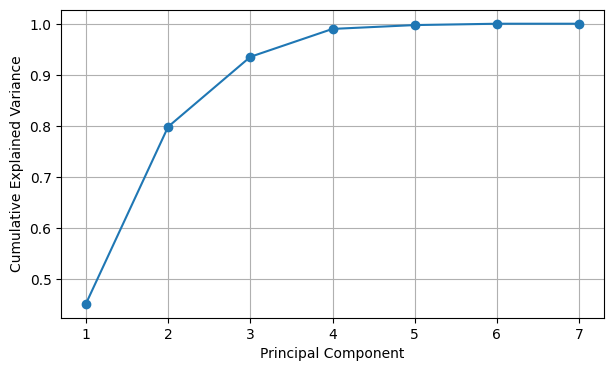

In [127]:
plt.figure(figsize=(7,4))

plt.plot(
    pca_summary.PC,
    pca_summary.CumulativeVariance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)

plt.show()

In [128]:
for t in [0.80,0.90,0.95,0.99]:
    n=(pca_summary.CumulativeVariance>=t).idxmax()+1
    print(f"{int(t*100)}% variance : {n} PCs")

80% variance : 3 PCs
90% variance : 3 PCs
95% variance : 4 PCs
99% variance : 5 PCs


### Interpretation

If only a small number of principal components explain most of the variance, the graph-metric representation possesses an intrinsically low-dimensional structure.

Such behaviour supports the hypothesis that dynamic functional connectivity repeatedly visits a limited number of graph configurations rather than exploring the feature space uniformly.

This provides the first indication that recurrent dynamic brain states may exist.

In [134]:
from tqdm.auto import tqdm
from threadpoolctl import threadpool_limits
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

scores=[]

with threadpool_limits(limits=64):

    pbar=tqdm(range(2,11),desc="Evaluating K",unit="K")

    for k in pbar:

        pbar.set_postfix(stage="KMeans",K=k)

        km=KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20,
            algorithm="lloyd"
        )

        labels=km.fit_predict(X)

        pbar.set_postfix(stage="Silhouette",K=k)
        sil=silhouette_score(X,labels)

        pbar.set_postfix(stage="Calinski",K=k)
        ch=calinski_harabasz_score(X,labels)

        pbar.set_postfix(stage="Davies",K=k)
        db=davies_bouldin_score(X,labels)

        scores.append({
            "K":k,
            "Inertia":km.inertia_,
            "Silhouette":sil,
            "CalinskiHarabasz":ch,
            "DaviesBouldin":db
        })

cluster_scores=pd.DataFrame(scores)

display(cluster_scores)

Evaluating K: 100%|██████████| 9/9 [07:32<00:00, 50.28s/K, K=10, stage=Davies]    


,K,Inertia,Silhouette,CalinskiHarabasz,DaviesBouldin
0,2,155739.444497,0.290854,12300.551478,1.388056
1,3,118794.132837,0.277190,12892.174590,1.166856
2,4,104252.943916,0.239111,11237.175275,1.282598
3,5,91555.431652,0.236905,10673.146984,1.250569
4,6,83869.308815,0.230228,9889.932715,1.217808
5,7,76687.390476,0.235015,9497.832691,1.117980
6,8,70236.775921,0.237311,9295.778551,1.125572
7,9,65623.024749,0.219530,8978.291473,1.169286
8,10,61870.604439,0.211194,8673.721564,1.160425


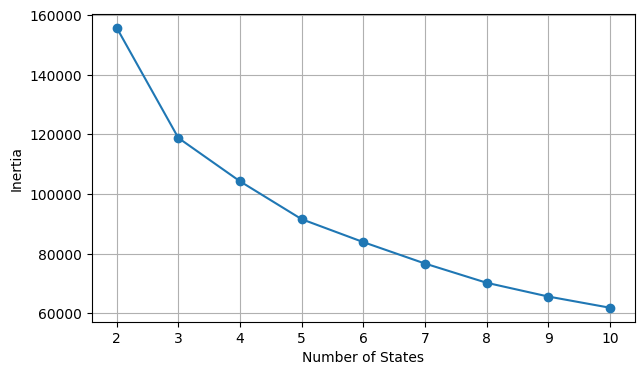

In [135]:
plt.figure(figsize=(7,4))

plt.plot(
    cluster_scores.K,
    cluster_scores.Inertia,
    marker="o"
)

plt.xlabel("Number of States")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

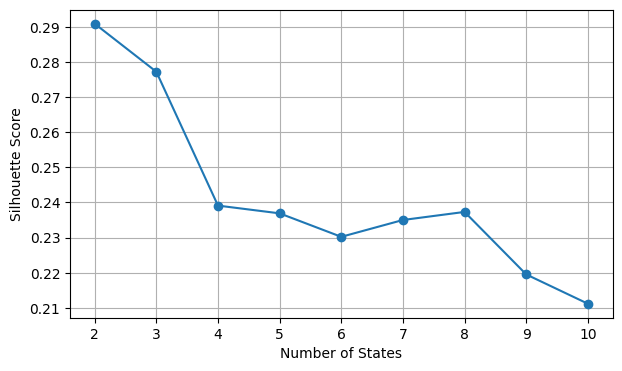

In [136]:
plt.figure(figsize=(7,4))

plt.plot(
    cluster_scores.K,
    cluster_scores.Silhouette,
    marker="o"
)

plt.xlabel("Number of States")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

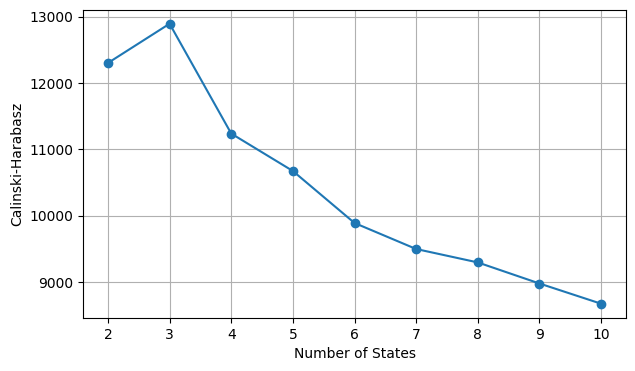

In [137]:
plt.figure(figsize=(7,4))

plt.plot(
    cluster_scores.K,
    cluster_scores.CalinskiHarabasz,
    marker="o"
)

plt.xlabel("Number of States")
plt.ylabel("Calinski-Harabasz")
plt.grid(True)

plt.show()

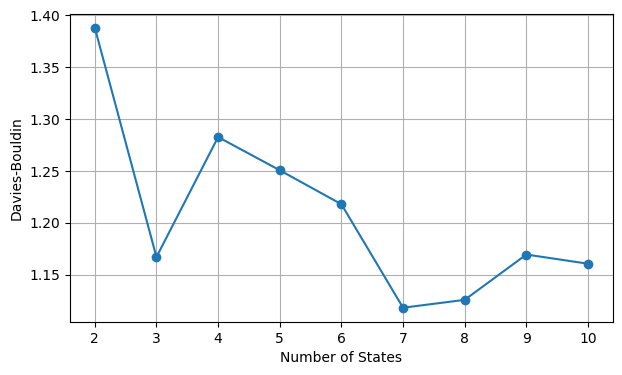

In [138]:
plt.figure(figsize=(7,4))

plt.plot(
    cluster_scores.K,
    cluster_scores.DaviesBouldin,
    marker="o"
)

plt.xlabel("Number of States")
plt.ylabel("Davies-Bouldin")
plt.grid(True)

plt.show()

In [139]:
summary=cluster_scores.copy()

summary["SilhouetteRank"]=summary.Silhouette.rank(ascending=False)
summary["CHRank"]=summary.CalinskiHarabasz.rank(ascending=False)
summary["DBRank"]=summary.DaviesBouldin.rank()
summary["MeanRank"]=summary[
    ["SilhouetteRank","CHRank","DBRank"]
].mean(axis=1)

summary=summary.sort_values("MeanRank")

display(summary)

,K,Inertia,Silhouette,CalinskiHarabasz,DaviesBouldin,SilhouetteRank,CHRank,DBRank,MeanRank
1,3,118794.132837,0.277190,12892.174590,1.166856,2.0,1.0,4.0,2.333333
0,2,155739.444497,0.290854,12300.551478,1.388056,1.0,2.0,9.0,4.000000
6,8,70236.775921,0.237311,9295.778551,1.125572,4.0,7.0,2.0,4.333333
5,7,76687.390476,0.235015,9497.832691,1.117980,6.0,6.0,1.0,4.333333
2,4,104252.943916,0.239111,11237.175275,1.282598,3.0,3.0,8.0,4.666667
3,5,91555.431652,0.236905,10673.146984,1.250569,5.0,4.0,7.0,5.333333
4,6,83869.308815,0.230228,9889.932715,1.217808,7.0,5.0,6.0,6.000000
7,9,65623.024749,0.219530,8978.291473,1.169286,8.0,8.0,5.0,7.000000
8,10,61870.604439,0.211194,8673.721564,1.160425,9.0,9.0,3.0,7.000000


In [153]:
from pathlib import Path

BASE = Path("/home/nvidia/23BRS1236")

for f in BASE.rglob("*CC200*"):
    print(f)

/home/nvidia/23BRS1236/adhd_data/02_timeseries/athena_cc200_tc_data/ADHD200_CC200_TCs_filtfix-20260701T074714Z-3-001.zip
/home/nvidia/23BRS1236/adhd_data/02_timeseries/athena_cc200_tc_data/ADHD200_CC200_TCs_filtfix


# Phase VIII-B — Cluster Stability and State Validation

## Objective

Internal clustering metrics identified **K = 3** as the most balanced solution, providing the best trade-off between cluster separation (Silhouette), compactness (Davies–Bouldin), and overall structure (Calinski–Harabasz).

However, internal metrics alone do not guarantee that the discovered brain states are reproducible.

In this phase, we evaluate the robustness of the clustering solution by assessing:

- Reproducibility across multiple K-Means initializations.
- Stability of cluster assignments.
- Distribution of windows across states.
- Biological plausibility of the discovered states.

Only after confirming that the clustering solution is stable will the identified states be used for downstream analyses, including occupancy, dwell time, transition probabilities, and dynamic biomarkers.

In [155]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import time

N_RUNS = 30
K = 3

labels_list = []

start = time.time()

print("Running K-Means stability analysis...")

for seed in tqdm(range(N_RUNS), desc="KMeans Runs"):

    km = KMeans(
        n_clusters=K,
        random_state=seed,
        n_init=20,
        algorithm="lloyd"
    )

    labels = km.fit_predict(X)

    labels_list.append(labels)

aris = []

pairs = [
    (i, j)
    for i in range(N_RUNS)
    for j in range(i + 1, N_RUNS)
]

for i, j in tqdm(pairs, desc="ARI Comparisons"):

    aris.append(
        adjusted_rand_score(
            labels_list[i],
            labels_list[j]
        )
    )

aris = np.asarray(aris)

elapsed = time.time() - start

print("=" * 60)
print("Cluster Stability")
print("=" * 60)
print(f"Mean ARI : {aris.mean():.4f}")
print(f"Std ARI  : {aris.std():.4f}")
print(f"Min ARI  : {aris.min():.4f}")
print(f"Max ARI  : {aris.max():.4f}")
print(f"Elapsed  : {elapsed:.1f} seconds")

Running K-Means stability analysis...


ARI Comparisons: 100%|██████████| 435/435 [00:01<00:00, 350.54it/s]

Cluster Stability
Mean ARI : 0.9950
Std ARI  : 0.0024
Min ARI  : 0.9882
Max ARI  : 1.0000
Elapsed  : 506.9 seconds


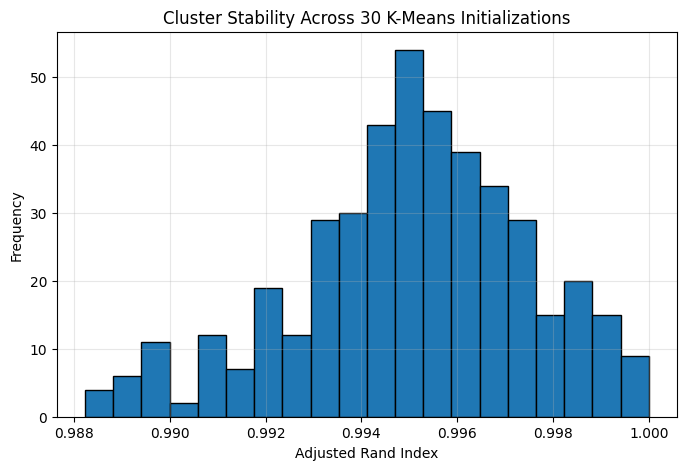

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    aris,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Adjusted Rand Index")
plt.ylabel("Frequency")
plt.title("Cluster Stability Across 30 K-Means Initializations")

plt.grid(alpha=0.3)

plt.show()

In [158]:
import pandas as pd

window_df = pd.read_parquet(
    "/home/nvidia/23BRS1236/adhd_data/workflow2/v7/dynamic_graph_metrics.parquet"
)

print(window_df.shape)
display(window_df.head())

(31060, 29)


,nodes,edges,density,components,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,builder,distance_metric,subject_id,site,session,run,window_index,label,Age,Gender,Handedness,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma
0,190,3591,0.2,1,37.8,25.236876,0.342180,0.558689,0.571893,0.720297,0.600203,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,0,0,12.36,0.0,1.0,0.345911,0.391120,0.386014,2.946965,1.034462,0.996910,1.037668
1,190,3591,0.2,1,37.8,24.667315,0.331305,0.538590,0.577439,0.721905,0.616338,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,1,0,12.36,0.0,1.0,0.328007,0.369279,0.383009,2.939382,1.029155,0.998416,1.030787
2,190,3591,0.2,1,37.8,24.528949,0.322564,0.542367,0.578933,0.712654,0.621745,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,2,0,12.36,0.0,1.0,0.318960,0.369538,0.381864,2.941301,1.027200,1.001865,1.025288
3,190,3591,0.2,1,37.8,24.231793,0.321985,0.529712,0.580089,0.723197,0.635170,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,3,0,12.36,0.0,1.0,0.320889,0.356290,0.379751,2.949367,1.033751,1.007655,1.025898
4,190,3591,0.2,1,37.8,24.204246,0.320368,0.521831,0.581700,0.722825,0.629521,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,4,0,12.36,0.0,1.0,0.331577,0.348304,0.381742,2.924067,1.030882,1.011138,1.019527


In [159]:
K = 3

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=20,
    algorithm="lloyd"
)

cluster_labels = kmeans.fit_predict(X)

window_df = window_df.copy()

window_df["brain_state"] = cluster_labels

print(window_df["brain_state"].value_counts().sort_index())

brain_state
0    14957
1     8471
2     7632
Name: count, dtype: int64


In [161]:
cluster_summary = (
    window_df
    .groupby("brain_state")
    .size()
    .reset_index(name="n_windows")
)

cluster_summary["percentage"] = (
    cluster_summary["n_windows"]
    / cluster_summary["n_windows"].sum()
    * 100
)

display(cluster_summary)

,brain_state,n_windows,percentage
0,0,14957,48.155184
1,1,8471,27.273020
2,2,7632,24.571797


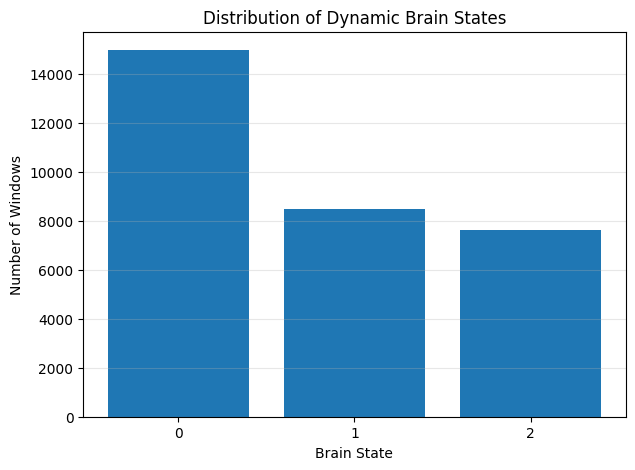

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    cluster_summary["brain_state"].astype(str),
    cluster_summary["n_windows"]
)

plt.xlabel("Brain State")
plt.ylabel("Number of Windows")
plt.title("Distribution of Dynamic Brain States")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [176]:
window_df = pd.read_parquet(
    "/home/nvidia/23BRS1236/adhd_data/workflow2/v7/dynamic_graph_metrics.parquet"
)

print(window_df.columns.tolist())

['nodes', 'edges', 'density', 'components', 'avg_degree', 'avg_strength', 'clustering', 'transitivity', 'efficiency_global', 'efficiency_local', 'path_length', 'builder', 'distance_metric', 'subject_id', 'site', 'session', 'run', 'window_index', 'label', 'Age', 'Gender', 'Handedness', 'null_clustering', 'null_transitivity', 'null_efficiency', 'null_path_length', 'gamma', 'lambda', 'sigma']


In [170]:
window_df = window_df.copy()
window_df["brain_state"] = cluster_labels

In [171]:
graph_features = [

    "avg_degree",
    "avg_strength",

    "clustering",
    "transitivity",

    "efficiency_global",
    "efficiency_local",

    "path_length",

    "null_clustering",
    "null_transitivity",
    "null_efficiency",
    "null_path_length",

    "gamma",
    "lambda",
    "sigma"

]

In [172]:
state_profiles = (
    window_df
    .groupby("brain_state")[graph_features]
    .mean()
)
display(state_profiles.round(3))

,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma
brain_state,,,,,,,,,,,,,,
0,37.8,23.895,0.299,0.462,0.590,0.711,0.609,0.303,0.302,0.390,2.815,1.033,1.022,1.011
1,37.8,26.225,0.358,0.510,0.581,0.735,0.517,0.363,0.365,0.416,2.675,1.030,1.024,1.006
2,37.8,26.598,0.377,0.564,0.567,0.732,0.537,0.377,0.415,0.404,2.836,1.031,1.005,1.026


In [173]:
from sklearn.preprocessing import StandardScaler

scaled = pd.DataFrame(
    StandardScaler().fit_transform(window_df[graph_features]),
    columns=graph_features
)

scaled["brain_state"] = window_df["brain_state"]

state_profiles_z = (
    scaled
    .groupby("brain_state")
    .mean()
)

display(state_profiles_z.round(2))

,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma
brain_state,,,,,,,,,,,,,,
0,0.0,-0.75,-0.75,-0.71,0.60,-0.71,0.69,-0.74,-0.73,-0.68,0.30,0.32,0.36,-0.22
1,0.0,0.59,0.50,0.18,-0.09,0.72,-0.79,0.55,0.29,0.99,-0.98,-0.42,0.54,-0.73
2,0.0,0.81,0.91,1.19,-1.06,0.59,-0.48,0.83,1.10,0.23,0.50,-0.16,-1.31,1.24


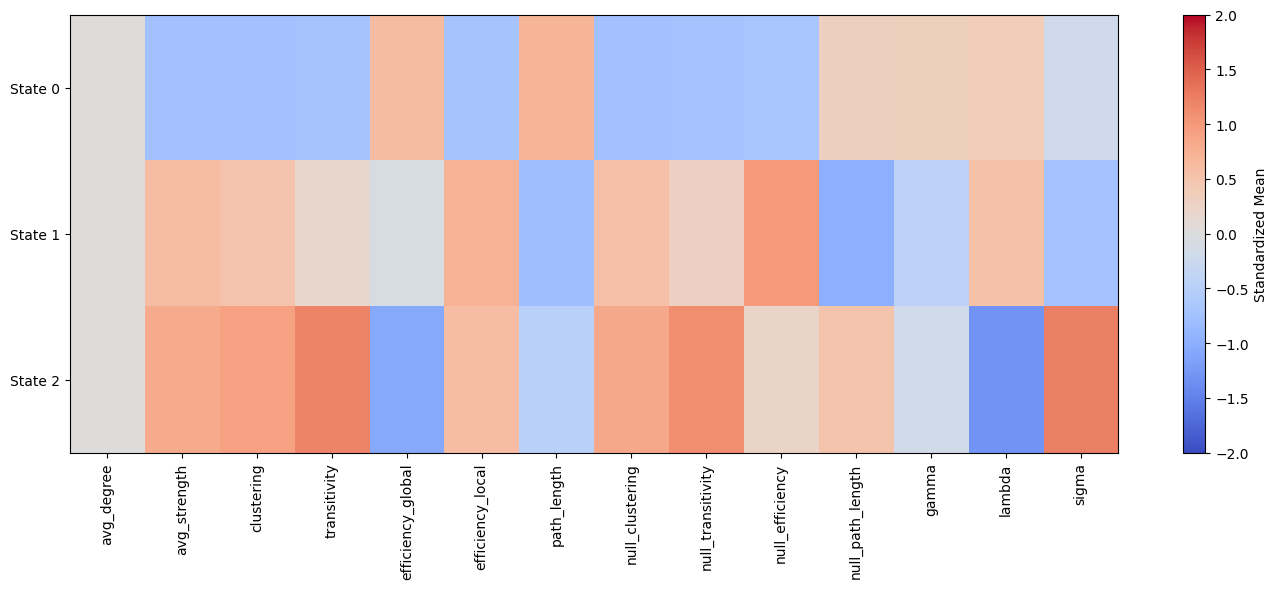

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.imshow(
    state_profiles_z,
    aspect="auto",
    cmap="coolwarm",
    vmin=-2,
    vmax=2
)

plt.xticks(
    range(len(graph_features)),
    graph_features,
    rotation=90
)

plt.yticks(
    range(3),
    [f"State {i}" for i in range(3)]
)

plt.colorbar(label="Standardized Mean")

plt.tight_layout()

plt.show()

# Phase VIII-C — Subject-Level Brain State Dynamics

## Objective

Phase VIII-B established that the discovered brain states are reproducible, well-populated, and biologically interpretable.

The objective of this phase is to convert the window-level clustering results into subject-level temporal state sequences.

Each subject is represented by an ordered sequence of dynamic brain states across all sliding windows.

These sequences form the basis for all downstream dynamic biomarkers, including:

- Fractional Occupancy
- Mean Dwell Time
- Transition Probability Matrix
- Switching Rate
- Transition Entropy

Unlike previous phases, the unit of analysis is now the **subject** rather than the individual dynamic window.

No statistical comparison between ADHD and Control groups is performed in this phase. Instead, the complete temporal representation for every subject is constructed and validated for downstream analyses.

In [194]:
window_df.groupby(
    ["subject_id", "session", "run"]
).size().reset_index(name="n_windows").head(20)

,subject_id,session,run,n_windows
0,10001,1,1,29
1,10001,1,2,29
2,10002,1,1,29
3,10002,1,2,29
4,10003,1,1,29
5,10004,1,1,29
6,10004,1,2,29
7,10005,1,1,29
8,10006,1,1,29
9,10007,1,1,29


In [195]:
window_df.groupby("subject_id")[["session","run"]].nunique().describe()

,session,run
count,764.0,764.000000
mean,1.0,1.561518
std,0.0,0.806355
min,1.0,1.000000
25%,1.0,1.000000
50%,1.0,1.000000
75%,1.0,2.000000
max,1.0,6.000000


In [196]:
state_table = (
    window_df[
        [
            "subject_id",
            "site",
            "session",
            "run",
            "label_binary",
            "window_index",
            "brain_state"
        ]
    ]
    .sort_values(
        [
            "subject_id",
            "session",
            "run",
            "window_index"
        ]
    )
    .reset_index(drop=True)
)

display(state_table.head())
print(state_table.shape)

,subject_id,site,session,run,label_binary,window_index,brain_state
0,10001,NYU,1,1,3,0,1
1,10001,NYU,1,1,3,1,1
2,10001,NYU,1,1,3,2,1
3,10001,NYU,1,1,3,3,1
4,10001,NYU,1,1,3,4,1


(31060, 7)


In [189]:
required = [
    "subject_id",
    "window_index",
    "brain_state",
    "label_binary",
    "site"
]

missing = [c for c in required if c not in window_df.columns]

if len(missing):
    raise ValueError(f"Missing columns: {missing}")

print(window_df[required].head())

   subject_id  window_index  brain_state  label_binary site
0     1018959             0            2             0  KKI
1     1018959             1            2             0  KKI
2     1018959             2            2             0  KKI
3     1018959             3            2             0  KKI
4     1018959             4            0             0  KKI


In [190]:
sequence_lengths = (
    state_table
    .groupby("subject_id")
    .size()
    .reset_index(name="n_windows")
)

display(sequence_lengths.describe())

,subject_id,n_windows
count,7.640000e+02,764.000000
mean,2.248696e+06,40.654450
std,2.360622e+06,13.163195
min,1.000100e+04,9.000000
25%,1.601175e+04,29.000000
50%,1.914538e+06,41.000000
75%,3.451418e+06,58.000000
max,9.956994e+06,60.000000


In [191]:
print(sequence_lengths["n_windows"].value_counts())

n_windows
41    194
58    179
33     88
27     75
19     54
46     48
29     36
60     32
24     30
20     13
40      8
54      4
36      2
9       1
Name: count, dtype: int64


In [192]:
subject_sequences = (
    state_table
    .groupby(
        [
            "subject_id",
            "site",
            "label_binary"
        ]
    )["brain_state"]
    .apply(list)
    .reset_index(name="state_sequence")
)

display(subject_sequences.head())

,subject_id,site,label_binary,state_sequence
0,10001,NYU,3,"[1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 2, ..."
1,10002,NYU,3,"[1, 1, 0, 1, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, ..."
2,10003,NYU,0,"[1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, ..."
3,10004,NYU,0,"[1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, ..."
4,10005,NYU,2,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, ..."


In [193]:
example = subject_sequences.iloc[0]

print("Subject:", example.subject_id)
print("Diagnosis:", example.label_binary)
print("Length:", len(example.state_sequence))
print(example.state_sequence)

Subject: 10001
Diagnosis: 3
Length: 58
[1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 2, 0, 2, 0, 1, 2, 1, 2, 2, 2, 1, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2]


## Objective

The previous phase established that three reproducible brain states exist within the dynamic graph-topological feature space.

The objective of this phase is to convert the window-level state assignments into temporally ordered run-level state sequences while preserving the original acquisition structure.

Each resting-state run is treated as an independent temporal observation.

Sequences are **not concatenated across runs**, preventing artificial transitions between separate acquisitions.

These run-level sequences form the canonical representation used to derive all subsequent dynamic biomarkers.

## Outputs

- Run-level brain state sequences
- Sequence quality-control summary
- Sequence length distribution
- State occurrence statistics

In [197]:
run_sequences = (
    state_table
    .groupby(
        [
            "subject_id",
            "site",
            "session",
            "run",
            "label_binary"
        ]
    )["brain_state"]
    .apply(list)
    .reset_index(name="state_sequence")
)

display(run_sequences.head())

,subject_id,site,session,run,label_binary,state_sequence
0,10001,NYU,1,1,3,"[1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 2, 1, 1, 2, ..."
1,10001,NYU,1,2,3,"[0, 0, 1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 0, 2, 2, ..."
2,10002,NYU,1,1,3,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,10002,NYU,1,2,3,"[1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, ..."
4,10003,NYU,1,1,0,"[1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, ..."


In [198]:
run_sequences["n_windows"] = (
    run_sequences["state_sequence"]
    .apply(len)
)

display(
    run_sequences["n_windows"].describe()
)

count    1193.000000
mean       26.035205
std        11.348230
min         6.000000
25%        19.000000
50%        29.000000
75%        33.000000
max        46.000000
Name: n_windows, dtype: float64

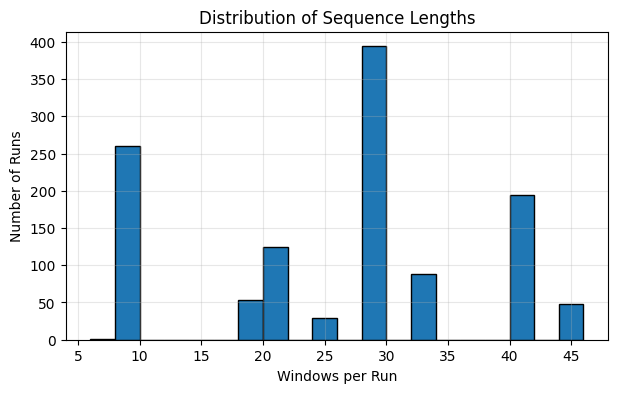

In [199]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.hist(
    run_sequences["n_windows"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Windows per Run")
plt.ylabel("Number of Runs")
plt.title("Distribution of Sequence Lengths")
plt.grid(alpha=0.3)
plt.show()

In [200]:
def unique_states(seq):
    return sorted(set(seq))

run_sequences["states_present"] = (
    run_sequences["state_sequence"]
    .apply(unique_states)
)
display(
    run_sequences[
        [
            "subject_id",
            "run",
            "states_present"
        ]
    ].head()
)

,subject_id,run,states_present
0,10001,1,"[0, 1, 2]"
1,10001,2,"[0, 1, 2]"
2,10002,1,"[0, 1, 2]"
3,10002,2,"[0, 1, 2]"
4,10003,1,"[0, 1, 2]"


In [201]:
run_sequences["n_states"] = (
    run_sequences["states_present"]
    .apply(len)
)
display(
    run_sequences["n_states"]
    .value_counts()
)

n_states
3    657
2    377
1    159
Name: count, dtype: int64

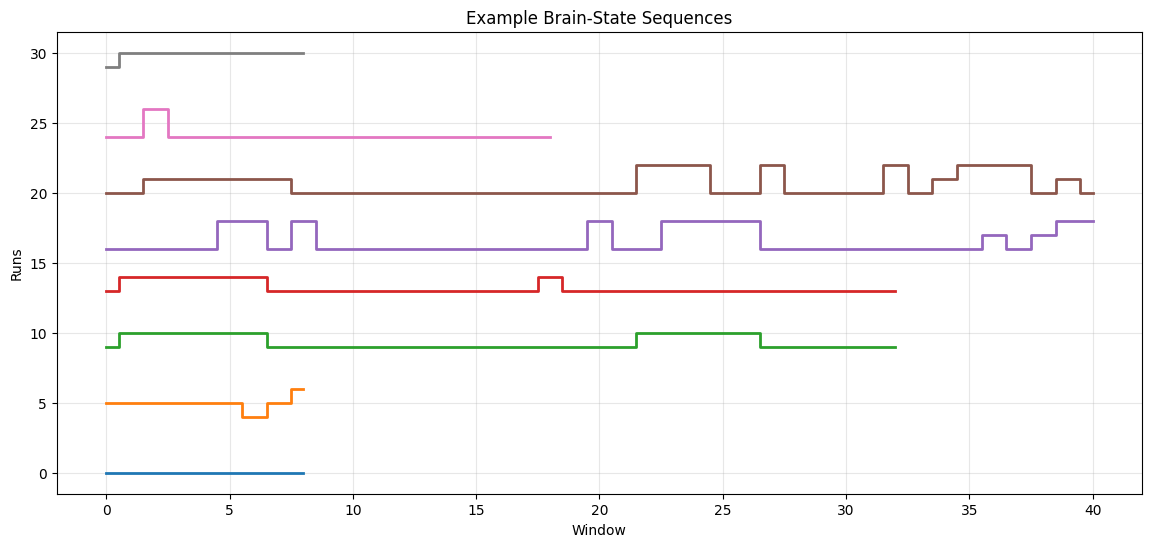

In [202]:
import numpy as np
import matplotlib.pyplot as plt

examples = run_sequences.sample(
    8,
    random_state=42
)
plt.figure(figsize=(14,6))
for i, (_, row) in enumerate(examples.iterrows()):
    seq = row["state_sequence"]
    plt.step(
        np.arange(len(seq)),
        np.array(seq) + i*4,
        where="mid",
        linewidth=2,
        label=f"{row.subject_id}-R{row.run}"
    )
plt.xlabel("Window")
plt.ylabel("Runs")
plt.title("Example Brain-State Sequences")
plt.grid(alpha=0.3)
plt.show()

In [203]:
from pathlib import Path

OUT = Path("/home/nvidia/23BRS1236/adhd_data/workflow2/v8")
OUT.mkdir(exist_ok=True)

run_sequences.to_parquet(
    OUT / "run_state_sequences.parquet",
    index=False
)

run_sequences.to_csv(
    OUT / "run_state_sequences.csv",
    index=False
)

print("Run-level sequences saved.")

Run-level sequences saved.


# Phase VIII-D — Dynamic Brain State Biomarker Extraction

## Objective

The validated run-level brain state sequences provide a compact representation of the temporal evolution of functional brain organization.

In this phase, quantitative dynamic biomarkers are extracted from each run.

Unlike static graph metrics, these biomarkers describe how the brain transitions between recurrent network configurations over time.

The extracted biomarkers include:

- Fractional Occupancy
- Mean Dwell Time
- Switching Rate
- Transition Probability Matrix
- Transition Entropy

Each biomarker captures a complementary aspect of temporal brain organization and will later be aggregated at the subject level before statistical comparison between ADHD and control participants.

In [204]:
import numpy as np
N_STATES = 3
def fractional_occupancy(seq):
    seq = np.asarray(seq)
    return np.array([
        np.mean(seq == s)
        for s in range(N_STATES)
    ])

def switching_rate(seq):
    seq = np.asarray(seq)
    return np.sum(seq[:-1] != seq[1:]) / (len(seq)-1)

def dwell_times(seq):
    seq = np.asarray(seq)
    dwell = {s: [] for s in range(N_STATES)}
    current = seq[0]
    length = 1
    for x in seq[1:]:
        if x == current:
            length += 1
        else:
            dwell[current].append(length)
            current = x
            length = 1
    dwell[current].append(length)
    return dwell

def mean_dwell(seq):
    dwell = dwell_times(seq)
    return np.array([
        np.mean(dwell[s]) if len(dwell[s]) else 0
        for s in range(N_STATES)
    ])

In [205]:
run_features = []
for _, row in run_sequences.iterrows():
    seq = row.state_sequence
    occ = fractional_occupancy(seq)
    dwell = mean_dwell(seq)
    switch = switching_rate(seq)
    run_features.append({
        "subject_id": row.subject_id,
        "site": row.site,
        "session": row.session,
        "run": row.run,
        "label_binary": row.label_binary,
        "occupancy_state0": occ[0],
        "occupancy_state1": occ[1],
        "occupancy_state2": occ[2],
        "dwell_state0": dwell[0],
        "dwell_state1": dwell[1],
        "dwell_state2": dwell[2],
        "switching_rate": switch
    })
run_features = pd.DataFrame(run_features)
display(run_features.head())

,subject_id,site,session,run,label_binary,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate
0,10001,NYU,1,1,3,0.310345,0.379310,0.310345,9.000000,2.75,2.250000,0.285714
1,10001,NYU,1,2,3,0.413793,0.172414,0.413793,3.000000,2.50,4.000000,0.285714
2,10002,NYU,1,1,3,0.655172,0.034483,0.310345,6.333333,1.00,4.500000,0.178571
3,10002,NYU,1,2,3,0.689655,0.068966,0.241379,3.333333,2.00,1.166667,0.428571
4,10003,NYU,1,1,0,0.034483,0.551724,0.413793,1.000000,8.00,6.000000,0.142857


In [206]:
display(
    run_features.describe().T
)

,count,mean,std,min,25%,50%,75%,max
subject_id,1193.0,2.092083e+06,2.315157e+06,10001.0,15035.000000,1.696588e+06,3.262042e+06,9956994.000
session,1193.0,1.038558e+00,2.689563e-01,1.0,1.000000,1.000000e+00,1.000000e+00,4.000
run,1193.0,1.488684e+00,7.608815e-01,1.0,1.000000,1.000000e+00,2.000000e+00,6.000
label_binary,1193.0,6.831517e-01,1.059565e+00,0.0,0.000000,0.000000e+00,1.000000e+00,3.000
occupancy_state0,1193.0,5.186731e-01,3.229662e-01,0.0,0.250000,5.217391e-01,7.777778e-01,1.000
occupancy_state1,1193.0,2.358298e-01,2.656033e-01,0.0,0.000000,1.463415e-01,3.658537e-01,1.000
occupancy_state2,1193.0,2.454971e-01,2.051979e-01,0.0,0.097561,2.121212e-01,3.658537e-01,1.000
dwell_state0,1193.0,6.140973e+00,6.179236e+00,0.0,2.333333,4.333333e+00,8.333333e+00,46.000
dwell_state1,1193.0,2.766813e+00,4.704130e+00,0.0,0.000000,1.800000e+00,3.000000e+00,33.000
dwell_state2,1193.0,2.756823e+00,2.601769e+00,0.0,1.000000,2.333333e+00,4.000000e+00,46.000


In [207]:
OUT = Path("/home/nvidia/23BRS1236/adhd_data/workflow2/v8")

run_features.to_parquet(
    OUT/"run_dynamic_biomarkers.parquet",
    index=False
)

run_features.to_csv(
    OUT/"run_dynamic_biomarkers.csv",
    index=False
)

In [208]:
print(run_features["label_binary"].value_counts())

label_binary
0    743
1    260
3    175
2     15
Name: count, dtype: int64


# Rename diagnosis variable according to ADHD-200 convention

In [209]:
for df_name in ["state_table", "run_sequences", "run_features"]:

    df = globals()[df_name]

    df = df.rename(
        columns={
            "label_binary": "diagnosis_code"
        }
    )
    df["diagnosis_binary"] = (
        df["diagnosis_code"] > 0
    ).astype(int)

    globals()[df_name] = df

print("Diagnosis variables updated.")

Diagnosis variables updated.


In [210]:
print(run_features.columns.tolist())
print()
print(run_features["diagnosis_code"].value_counts().sort_index())
print()
print(run_features["diagnosis_binary"].value_counts().sort_index())

['subject_id', 'site', 'session', 'run', 'diagnosis_code', 'occupancy_state0', 'occupancy_state1', 'occupancy_state2', 'dwell_state0', 'dwell_state1', 'dwell_state2', 'switching_rate', 'diagnosis_binary']

diagnosis_code
0    743
1    260
2     15
3    175
Name: count, dtype: int64

diagnosis_binary
0    743
1    450
Name: count, dtype: int64


In [211]:
OUT = Path("/home/nvidia/23BRS1236/adhd_data/workflow2/v8")
state_table.to_parquet(
    OUT / "brain_state_table.parquet",
    index=False
)
run_sequences.to_parquet(
    OUT / "run_state_sequences.parquet",
    index=False
)
run_features.to_parquet(
    OUT / "run_dynamic_biomarkers.parquet",
    index=False
)

print("Updated datasets saved.")

Updated datasets saved.


# Phase VIII-E — Brain State Transition Dynamics

## Objective

Previous analyses quantified the temporal properties of individual brain states using fractional occupancy, dwell time, and switching rate.

However, these metrics do not describe **how transitions occur between states**.

In this phase, transition dynamics are quantified by constructing state-transition matrices for every resting-state run.

Each transition matrix summarizes the probability of moving from one brain state to another while preserving temporal ordering.

The resulting transition matrices provide a compact description of the temporal organization of large-scale functional brain networks and will later be aggregated to the subject level for statistical comparison between ADHD and control participants.

## Outputs

- Transition count matrices
- Transition probability matrices
- Self-transition probabilities
- Transition entropy

In [215]:
#Transition Matrix Functions
import numpy as np
N_STATES = 3

def transition_counts(sequence):
    counts = np.zeros((N_STATES, N_STATES), dtype=int)
    for i in range(len(sequence) - 1):
        counts[
            sequence[i],
            sequence[i + 1]
        ] += 1
    return counts

def transition_probabilities(sequence):
    counts = transition_counts(sequence).astype(float)
    probs = np.zeros_like(counts)
    row_sum = counts.sum(axis=1, keepdims=True)
    np.divide(
        counts,
        row_sum,
        out=probs,
        where=row_sum > 0
    )
    return probs

In [216]:
transition_results = []
transition_matrices = {}
for _, row in run_sequences.iterrows():
    P = transition_probabilities(
        row.state_sequence
    )
    transition_matrices[
        (
            row.subject_id,
            row.run
        )
    ] = P
    transition_results.append({
        "subject_id": row.subject_id,
        "site": row.site,
        "session": row.session,
        "run": row.run,
        "diagnosis_code": row.diagnosis_code,
        "diagnosis_binary": row.diagnosis_binary,
        "P00": P[0,0],
        "P01": P[0,1],
        "P02": P[0,2],
        "P10": P[1,0],
        "P11": P[1,1],
        "P12": P[1,2],
        "P20": P[2,0],
        "P21": P[2,1],
        "P22": P[2,2]
    })
transition_df = pd.DataFrame(
    transition_results
)
display(transition_df.head())

,subject_id,site,session,run,diagnosis_code,diagnosis_binary,P00,P01,P02,P10,P11,P12,P20,P21,P22
0,10001,NYU,1,1,3,1,0.888889,0.111111,0.000000,0.0,0.636364,0.363636,0.125000,0.250000,0.625000
1,10001,NYU,1,2,3,1,0.666667,0.166667,0.166667,0.2,0.600000,0.200000,0.181818,0.000000,0.818182
2,10002,NYU,1,1,3,1,0.888889,0.000000,0.111111,1.0,0.000000,0.000000,0.222222,0.000000,0.777778
3,10002,NYU,1,2,3,1,0.736842,0.000000,0.263158,0.0,0.500000,0.500000,0.857143,0.000000,0.142857
4,10003,NYU,1,1,0,0,0.000000,0.000000,1.000000,0.0,0.933333,0.066667,0.083333,0.083333,0.833333


In [217]:
mean_transition = np.mean(
    list(transition_matrices.values()),
    axis=0
)

mean_transition = pd.DataFrame(
    mean_transition,
    index=[
        "State 0",
        "State 1",
        "State 2"
    ],
    columns=[
        "State 0",
        "State 1",
        "State 2"
    ]
)

display(mean_transition.round(3))

,State 0,State 1,State 2
State 0,0.694,0.093,0.103
State 1,0.157,0.395,0.122
State 2,0.196,0.141,0.492


# Phase VIII-E — Transition Dynamics

## Objective

The previously extracted dynamic biomarkers quantify the temporal properties of individual brain states.
This phase characterizes **state-to-state transitions** by modelling the temporal evolution of brain states as a first-order Markov process.
For every resting-state run, both the transition count matrix and the corresponding transition probability matrix are computed.
Transition counts preserve the complete transition information and serve as the canonical representation.
Transition probabilities are subsequently derived through row-wise normalization of the count matrices.
Finally, transition entropy is computed to quantify the predictability and complexity of temporal brain-state evolution.

## Outputs

- Transition count matrices
- Transition probability matrices
- Self-transition probabilities
- Transition entropy

In [218]:
transition_summary = []
transition_counts_dict = {}
transition_probability_dict = {}
for _, row in run_sequences.iterrows():
    counts = transition_counts(
        row.state_sequence
    )
    probs = transition_probabilities(
        row.state_sequence
    )
    transition_counts_dict[
        (
            row.subject_id,
            row.run
        )
    ] = counts
    transition_probability_dict[
        (
            row.subject_id,
            row.run
        )
    ] = probs
    transition_summary.append({

        "subject_id": row.subject_id,
        "site": row.site,
        "session": row.session,
        "run": row.run,

        "diagnosis_code": row.diagnosis_code,
        "diagnosis_binary": row.diagnosis_binary,

        # Counts

        "C00": counts[0,0],
        "C01": counts[0,1],
        "C02": counts[0,2],

        "C10": counts[1,0],
        "C11": counts[1,1],
        "C12": counts[1,2],

        "C20": counts[2,0],
        "C21": counts[2,1],
        "C22": counts[2,2],

        # Probabilities

        "P00": probs[0,0],
        "P01": probs[0,1],
        "P02": probs[0,2],

        "P10": probs[1,0],
        "P11": probs[1,1],
        "P12": probs[1,2],

        "P20": probs[2,0],
        "P21": probs[2,1],
        "P22": probs[2,2]
    })

transition_summary = pd.DataFrame(
    transition_summary
)

display(transition_summary.head())

,subject_id,site,session,run,diagnosis_code,diagnosis_binary,C00,C01,C02,C10,C11,C12,C20,C21,C22,P00,P01,P02,P10,P11,P12,P20,P21,P22
0,10001,NYU,1,1,3,1,8,1,0,0,7,4,1,2,5,0.888889,0.111111,0.000000,0.0,0.636364,0.363636,0.125000,0.250000,0.625000
1,10001,NYU,1,2,3,1,8,2,2,1,3,1,2,0,9,0.666667,0.166667,0.166667,0.2,0.600000,0.200000,0.181818,0.000000,0.818182
2,10002,NYU,1,1,3,1,16,0,2,1,0,0,2,0,7,0.888889,0.000000,0.111111,1.0,0.000000,0.000000,0.222222,0.000000,0.777778
3,10002,NYU,1,2,3,1,14,0,5,0,1,1,6,0,1,0.736842,0.000000,0.263158,0.0,0.500000,0.500000,0.857143,0.000000,0.142857
4,10003,NYU,1,1,0,0,0,0,1,0,14,1,1,1,10,0.000000,0.000000,1.000000,0.0,0.933333,0.066667,0.083333,0.083333,0.833333


In [219]:
total_counts = np.zeros((3,3))
for M in transition_counts_dict.values():
    total_counts += M
population_transition = (
    total_counts
    / total_counts.sum(axis=1, keepdims=True)
)
population_transition = pd.DataFrame(
    population_transition,
    index=[
        "State 0",
        "State 1",
        "State 2"
    ],
    columns=[
        "State 0",
        "State 1",
        "State 2"
    ]
)

display(
    population_transition.round(3)
)

,State 0,State 1,State 2
State 0,0.848,0.072,0.080
State 1,0.129,0.740,0.131
State 2,0.152,0.147,0.701


In [220]:
from scipy.stats import entropy
transition_entropy = []
for P in transition_probability_dict.values():
    H = []
    for row in P:
        if row.sum() > 0:
            H.append(
                entropy(
                    row,
                    base=2
                )
            )
    transition_entropy.append(
        np.mean(H)
    )
transition_summary[
    "transition_entropy"
] = transition_entropy
display(
    transition_summary[
        [
            "transition_entropy"
        ]
    ].describe()
)

,transition_entropy
count,1193.000000
mean,0.656060
std,0.399537
min,0.000000
25%,0.360964
50%,0.690912
75%,0.959517
max,1.512497


In [221]:
transition_summary.to_parquet(
    OUT/"run_transition_dynamics.parquet",
    index=False
)

transition_summary.to_csv(
    OUT/"run_transition_dynamics.csv",
    index=False
)

Population Transition Matrix

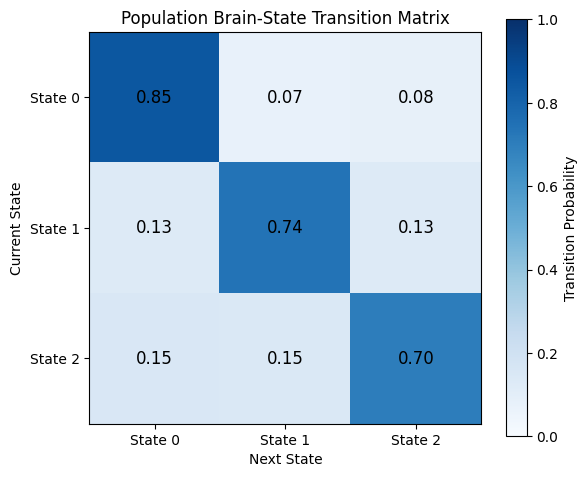

In [222]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))

plt.imshow(
    population_transition,
    cmap="Blues",
    vmin=0,
    vmax=1
)

for i in range(3):
    for j in range(3):

        plt.text(
            j,
            i,
            f"{population_transition.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=12,
            color="black"
        )

plt.xticks(
    [0,1,2],
    ["State 0","State 1","State 2"]
)

plt.yticks(
    [0,1,2],
    ["State 0","State 1","State 2"]
)

plt.xlabel("Next State")
plt.ylabel("Current State")
plt.title("Population Brain-State Transition Matrix")
plt.colorbar(label="Transition Probability")
plt.tight_layout()
plt.show()

Transition Entropy Distribution

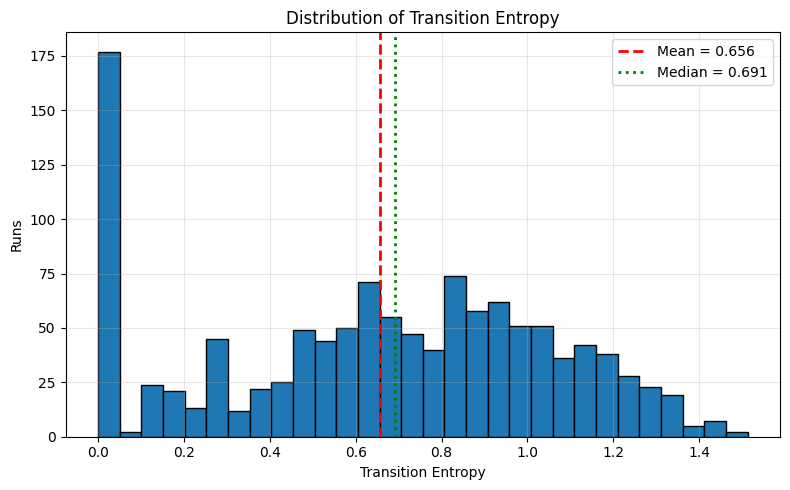

In [228]:
import matplotlib.pyplot as plt
mean_entropy = transition_summary["transition_entropy"].mean()
median_entropy = transition_summary["transition_entropy"].median()
plt.figure(figsize=(8,5))
plt.hist(
    transition_summary["transition_entropy"],
    bins=30,
    edgecolor="black"
)
plt.axvline(
    mean_entropy,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_entropy:.3f}"
)
plt.axvline(
    median_entropy,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_entropy:.3f}"
)
plt.xlabel("Transition Entropy")
plt.ylabel("Runs")
plt.title("Distribution of Transition Entropy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [229]:
zero_entropy = transition_summary[
    transition_summary["transition_entropy"] == 0
]

print("="*60)
print("Zero Entropy Runs")
print("="*60)
print(f"Number of runs : {len(zero_entropy)}")
print(f"Percentage     : {100*len(zero_entropy)/len(transition_summary):.2f}%")
display(
    zero_entropy[
        [
            "subject_id",
            "site",
            "run",
            "diagnosis_code",
            "diagnosis_binary"
        ]
    ].head(20)
)

Zero Entropy Runs
Number of runs : 177
Percentage     : 14.84%


,subject_id,site,run,diagnosis_code,diagnosis_binary
88,10053,NYU,1,0,0
173,10100,NYU,1,0,0
224,15001,WashU,1,0,0
225,15001,WashU,2,0,0
227,15001,WashU,4,0,0
230,15002,WashU,1,0,0
231,15002,WashU,2,0,0
232,15002,WashU,3,0,0
237,15003,WashU,2,0,0
238,15003,WashU,3,0,0


In [230]:
entropy_check = run_sequences.copy()
entropy_check["transition_entropy"] = transition_summary["transition_entropy"]
display(
    pd.crosstab(
        entropy_check["n_states"],
        entropy_check["transition_entropy"] == 0,
        margins=True
    )
)

transition_entropy,False,True,All
n_states,,,
1,0,159,159
2,359,18,377
3,657,0,657
All,1016,177,1193


In [231]:
summary = pd.DataFrame({
    "Metric":[
        "Runs",
        "Subjects",
        "Mean Windows / Run",
        "Mean Switching Rate",
        "Mean Transition Entropy",
        "Mean Occupancy State0",
        "Mean Occupancy State1",
        "Mean Occupancy State2"
    ],
    "Value":[
        len(run_features),
        run_features["subject_id"].nunique(),
        run_sequences["n_windows"].mean(),
        run_features["switching_rate"].mean(),
        transition_summary["transition_entropy"].mean(),
        run_features["occupancy_state0"].mean(),
        run_features["occupancy_state1"].mean(),
        run_features["occupancy_state2"].mean()
    ]
})
display(summary)

,Metric,Value
0,Runs,1193.000000
1,Subjects,764.000000
2,Mean Windows / Run,26.035205
3,Mean Switching Rate,0.205737
4,Mean Transition Entropy,0.656060
5,Mean Occupancy State0,0.518673
6,Mean Occupancy State1,0.235830
7,Mean Occupancy State2,0.245497


In [232]:
suspect = entropy_check[
    (entropy_check["n_states"] == 2) &
    (entropy_check["transition_entropy"] == 0)
]

display(suspect)

,subject_id,site,session,run,diagnosis_code,state_sequence,n_windows,states_present,n_states,diagnosis_binary,transition_entropy
225,15001,WashU,4,2,0,"[2, 0, 0, 0, 0, 0, 0, 0, 0]",9,"[0, 2]",2,0,0.0
230,15002,WashU,1,1,0,"[2, 0, 0, 0, 0, 0, 0, 0, 0]",9,"[0, 2]",2,0,0.0
231,15002,WashU,1,2,0,"[2, 0, 0, 0, 0, 0, 0, 0, 0]",9,"[0, 2]",2,0,0.0
244,15004,WashU,2,3,0,"[1, 2, 2, 2, 2, 2, 2, 2, 2]",9,"[1, 2]",2,0,0.0
284,15031,WashU,1,1,0,"[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",20,"[0, 2]",2,0,0.0
355,15057,WashU,2,1,0,"[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",20,"[0, 2]",2,0,0.0
374,16002,Pittsburgh,1,1,0,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",33,"[1, 2]",2,0,0.0
445,16074,Pittsburgh,1,1,0,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",33,"[1, 2]",2,0,0.0
457,16086,Pittsburgh,1,1,0,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",33,"[1, 2]",2,0,0.0
475,1084283,OHSU,1,2,1,"[2, 0, 0, 0, 0, 0, 0, 0, 0]",9,"[0, 2]",2,1,0.0


In [233]:
sid = suspect.iloc[0]["subject_id"]
run = suspect.iloc[0]["run"]

seq = run_sequences.loc[
    (run_sequences.subject_id == sid) &
    (run_sequences.run == run),
    "state_sequence"
].iloc[0]

print(seq)

[2, 0, 0, 0, 0, 0, 0, 0, 0]


Occupancy Distribution

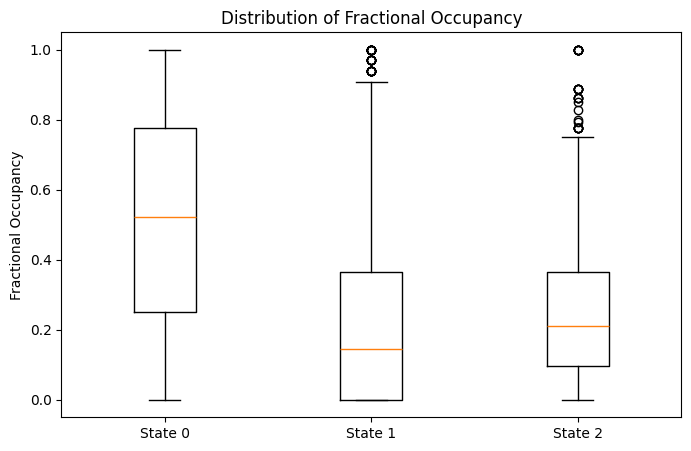

In [224]:
fig, ax = plt.subplots(figsize=(8,5))

occupancies = [
    run_features["occupancy_state0"],
    run_features["occupancy_state1"],
    run_features["occupancy_state2"]
]

ax.boxplot(
    occupancies,
    labels=[
        "State 0",
        "State 1",
        "State 2"
    ]
)
ax.set_ylabel("Fractional Occupancy")
ax.set_title("Distribution of Fractional Occupancy")
plt.show()

Dwell Time

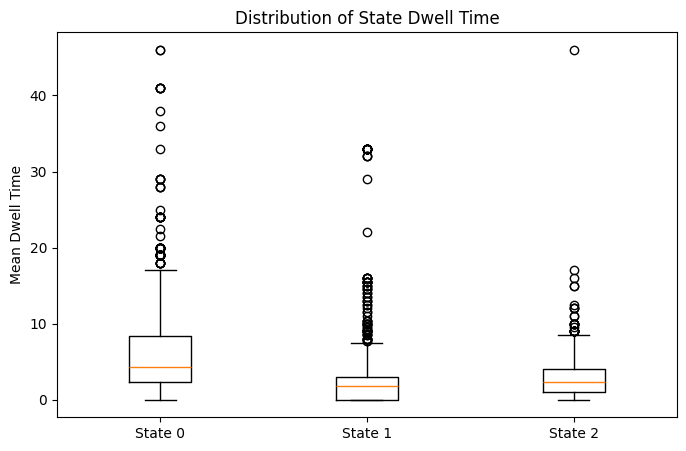

In [225]:
fig, ax = plt.subplots(figsize=(8,5))
dwells = [
    run_features["dwell_state0"],
    run_features["dwell_state1"],
    run_features["dwell_state2"]
]
ax.boxplot(
    dwells,
    labels=[
        "State 0",
        "State 1",
        "State 2"
    ]
)
ax.set_ylabel("Mean Dwell Time")
ax.set_title("Distribution of State Dwell Time")
plt.show()

Switching Rate

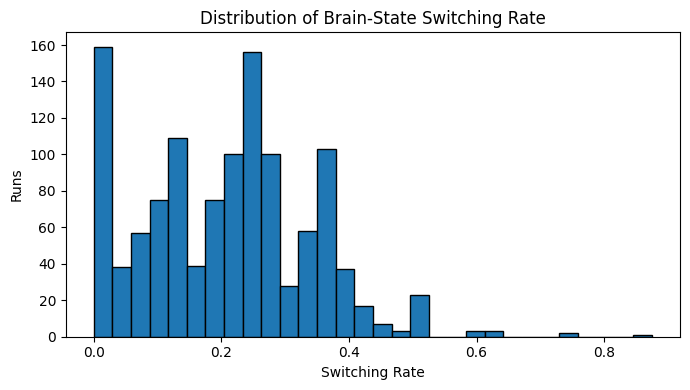

In [226]:
plt.figure(figsize=(7,4))
plt.hist(
    run_features["switching_rate"],
    bins=30,
    edgecolor="black"
)
plt.xlabel("Switching Rate")
plt.ylabel("Runs")
plt.title("Distribution of Brain-State Switching Rate")
plt.tight_layout()
plt.show()

# Phase VIII-F — Subject-Level Dynamic Biomarker Aggregation

## Objective

Dynamic biomarkers have thus far been computed independently for each resting-state acquisition (run).
However, statistical analyses should be performed at the participant level rather than the run level.
This phase aggregates multiple runs belonging to the same participant into a single subject-level representation while preserving demographic and diagnostic metadata.
Scalar biomarkers are averaged across runs.
Transition count matrices are summed across runs before row-wise normalization to preserve valid transition probabilities.
The resulting subject-level dataset constitutes the final analysis-ready dataset for all downstream statistical analyses and machine learning experiments.

## Outputs

- Subject-level dynamic biomarker dataset
- Subject-level transition count matrices
- Subject-level transition probability matrices
- Quality-control report

In [237]:
print("="*70)
print("Metadata Consistency Check")
print("="*70)

metadata_check = (
    run_features
    .groupby("subject_id")
    .agg(
        n_sites=("site","nunique"),
        n_dx=("diagnosis_code","nunique"),
        n_binary=("diagnosis_binary","nunique")
    )
)

display(metadata_check.describe())
assert (metadata_check["n_sites"] == 1).all(), \
    "A subject appears in multiple sites."
assert (metadata_check["n_dx"] == 1).all(), \
    "Diagnosis changed across runs."
assert (metadata_check["n_binary"] == 1).all(), \
    "Binary diagnosis changed."
print("Metadata validation passed.")

Metadata Consistency Check


,n_sites,n_dx,n_binary
count,764.0,764.0,764.0
mean,1.0,1.0,1.0
std,0.0,0.0,0.0
min,1.0,1.0,1.0
25%,1.0,1.0,1.0
50%,1.0,1.0,1.0
75%,1.0,1.0,1.0
max,1.0,1.0,1.0


Metadata validation passed.


In [238]:
scalar_columns = [

    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",

    "dwell_state0",
    "dwell_state1",
    "dwell_state2",

    "switching_rate"

]
subject_scalar = (
    run_features
    .groupby("subject_id")
    .agg({
        "site":"first",
        "diagnosis_code":"first",
        "diagnosis_binary":"first",
        **{c:"mean" for c in scalar_columns}
    })
    .reset_index()
)
display(subject_scalar.head())

,subject_id,site,diagnosis_code,diagnosis_binary,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate
0,10001,NYU,3,1,0.362069,0.275862,0.362069,6.000000,2.625,3.125000,0.285714
1,10002,NYU,3,1,0.672414,0.051724,0.275862,4.833333,1.500,2.833333,0.303571
2,10003,NYU,0,0,0.034483,0.551724,0.413793,1.000000,8.000,6.000000,0.142857
3,10004,NYU,0,0,0.448276,0.396552,0.155172,3.250000,2.875,3.250000,0.303571
4,10005,NYU,2,1,0.068966,0.068966,0.862069,2.000000,2.000,8.333333,0.142857


In [239]:
entropy_subject = (
    transition_summary
    .groupby("subject_id")["transition_entropy"]
    .mean()
    .reset_index()
)
subject_scalar = subject_scalar.merge(
    entropy_subject,
    on="subject_id"
)
display(subject_scalar.head())

,subject_id,site,diagnosis_code,diagnosis_binary,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy
0,10001,NYU,3,1,0.362069,0.275862,0.362069,6.000000,2.625,3.125000,0.285714,1.009055
1,10002,NYU,3,1,0.672414,0.051724,0.275862,4.833333,1.500,2.833333,0.303571,0.615102
2,10003,NYU,0,0,0.034483,0.551724,0.413793,1.000000,8.000,6.000000,0.142857,0.390016
3,10004,NYU,0,0,0.448276,0.396552,0.155172,3.250000,2.875,3.250000,0.303571,1.096601
4,10005,NYU,2,1,0.068966,0.068966,0.862069,2.000000,2.000,8.333333,0.142857,0.832383


In [240]:
count_cols = [
    "C00","C01","C02",
    "C10","C11","C12",
    "C20","C21","C22"
]
subject_counts = (
    transition_summary
    .groupby("subject_id")[count_cols]
    .sum()
    .reset_index()
)
display(subject_counts.head())

,subject_id,C00,C01,C02,C10,C11,C12,C20,C21,C22
0,10001,16,3,2,1,10,5,3,2,14
1,10002,30,0,7,1,1,1,8,0,8
2,10003,0,0,1,0,14,1,1,1,10
3,10004,18,4,2,7,15,1,1,2,6
4,10005,1,0,1,0,1,1,1,1,22


In [241]:
subject_transition = subject_counts.copy()
for idx, row in subject_transition.iterrows():
    C = np.array([
        [row.C00,row.C01,row.C02],
        [row.C10,row.C11,row.C12],
        [row.C20,row.C21,row.C22]
    ], dtype=float)
    P = np.zeros_like(C)
    rs = C.sum(axis=1, keepdims=True)
    np.divide(
        C,
        rs,
        out=P,
        where=rs>0
    )
    subject_transition.loc[idx,["P00","P01","P02"]] = P[0]
    subject_transition.loc[idx,["P10","P11","P12"]] = P[1]
    subject_transition.loc[idx,["P20","P21","P22"]] = P[2]
display(subject_transition.head())

,subject_id,C00,C01,C02,C10,C11,C12,C20,C21,C22,P00,P01,P02,P10,P11,P12,P20,P21,P22
0,10001,16,3,2,1,10,5,3,2,14,0.761905,0.142857,0.095238,0.062500,0.625000,0.312500,0.157895,0.105263,0.736842
1,10002,30,0,7,1,1,1,8,0,8,0.810811,0.000000,0.189189,0.333333,0.333333,0.333333,0.500000,0.000000,0.500000
2,10003,0,0,1,0,14,1,1,1,10,0.000000,0.000000,1.000000,0.000000,0.933333,0.066667,0.083333,0.083333,0.833333
3,10004,18,4,2,7,15,1,1,2,6,0.750000,0.166667,0.083333,0.304348,0.652174,0.043478,0.111111,0.222222,0.666667
4,10005,1,0,1,0,1,1,1,1,22,0.500000,0.000000,0.500000,0.000000,0.500000,0.500000,0.041667,0.041667,0.916667


In [242]:
subject_dataset = (
    subject_scalar
    .merge(
        subject_transition,
        on="subject_id",
        how="inner"
    )
)
print("="*70)
print("Subject Dataset")
print("="*70)
print(subject_dataset.shape)

display(subject_dataset.head())

Subject Dataset
(764, 30)


,subject_id,site,diagnosis_code,diagnosis_binary,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy,C00,C01,C02,C10,C11,C12,C20,C21,C22,P00,P01,P02,P10,P11,P12,P20,P21,P22
0,10001,NYU,3,1,0.362069,0.275862,0.362069,6.000000,2.625,3.125000,0.285714,1.009055,16,3,2,1,10,5,3,2,14,0.761905,0.142857,0.095238,0.062500,0.625000,0.312500,0.157895,0.105263,0.736842
1,10002,NYU,3,1,0.672414,0.051724,0.275862,4.833333,1.500,2.833333,0.303571,0.615102,30,0,7,1,1,1,8,0,8,0.810811,0.000000,0.189189,0.333333,0.333333,0.333333,0.500000,0.000000,0.500000
2,10003,NYU,0,0,0.034483,0.551724,0.413793,1.000000,8.000,6.000000,0.142857,0.390016,0,0,1,0,14,1,1,1,10,0.000000,0.000000,1.000000,0.000000,0.933333,0.066667,0.083333,0.083333,0.833333
3,10004,NYU,0,0,0.448276,0.396552,0.155172,3.250000,2.875,3.250000,0.303571,1.096601,18,4,2,7,15,1,1,2,6,0.750000,0.166667,0.083333,0.304348,0.652174,0.043478,0.111111,0.222222,0.666667
4,10005,NYU,2,1,0.068966,0.068966,0.862069,2.000000,2.000,8.333333,0.142857,0.832383,1,0,1,0,1,1,1,1,22,0.500000,0.000000,0.500000,0.000000,0.500000,0.500000,0.041667,0.041667,0.916667


In [243]:
print("="*70)
print("Dataset Integrity")
print("="*70)

print("Unique Subjects")
print(subject_dataset["subject_id"].nunique())
print()
print("Missing Values")
display(subject_dataset.isna().sum())
assert subject_dataset["subject_id"].is_unique
assert subject_dataset.isna().sum().sum()==0
print()
print("Integrity checks passed.")

Dataset Integrity
Unique Subjects
764

Missing Values


subject_id            0
site                  0
diagnosis_code        0
diagnosis_binary      0
occupancy_state0      0
occupancy_state1      0
occupancy_state2      0
dwell_state0          0
dwell_state1          0
dwell_state2          0
switching_rate        0
transition_entropy    0
C00                   0
C01                   0
C02                   0
C10                   0
C11                   0
C12                   0
C20                   0
C21                   0
C22                   0
P00                   0
P01                   0
P02                   0
P10                   0
P11                   0
P12                   0
P20                   0
P21                   0
P22                   0
dtype: int64


Integrity checks passed.


In [244]:
OUT = Path("/home/nvidia/23BRS1236/adhd_data/workflow2/v8")
subject_dataset.to_csv(
    OUT/"subject_dynamic_dataset.csv",
    index=False
)
subject_dataset.to_parquet(
    OUT/"subject_dynamic_dataset.parquet",
    index=False
)
print("Subject dataset saved.")

Subject dataset saved.


# Phase VIII-G — Subject-Level Dataset Validation

## Objective

The previous phase produced the final subject-level dynamic biomarker dataset.

Before statistical inference, it is essential to verify that the dataset satisfies the assumptions required for valid downstream analyses.

This phase performs a comprehensive quality assessment of the aggregated dataset by examining:

- descriptive statistics,
- cohort composition,
- biomarker distributions,
- inter-feature relationships,
- redundancy between biomarkers.

No hypothesis testing is performed in this phase.

Instead, the objective is to establish that the final dataset is internally consistent, biologically plausible, and suitable for inferential statistical analysis.

In [245]:
print("="*70)
print("Subject-Level Dataset")
print("="*70)
print("Shape:", subject_dataset.shape)
print()
print("Subjects :", subject_dataset["subject_id"].nunique())
print("Sites    :", subject_dataset["site"].nunique())
print()
display(subject_dataset.head())

Subject-Level Dataset
Shape: (764, 30)

Subjects : 764
Sites    : 9



,subject_id,site,diagnosis_code,diagnosis_binary,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy,C00,C01,C02,C10,C11,C12,C20,C21,C22,P00,P01,P02,P10,P11,P12,P20,P21,P22
0,10001,NYU,3,1,0.362069,0.275862,0.362069,6.000000,2.625,3.125000,0.285714,1.009055,16,3,2,1,10,5,3,2,14,0.761905,0.142857,0.095238,0.062500,0.625000,0.312500,0.157895,0.105263,0.736842
1,10002,NYU,3,1,0.672414,0.051724,0.275862,4.833333,1.500,2.833333,0.303571,0.615102,30,0,7,1,1,1,8,0,8,0.810811,0.000000,0.189189,0.333333,0.333333,0.333333,0.500000,0.000000,0.500000
2,10003,NYU,0,0,0.034483,0.551724,0.413793,1.000000,8.000,6.000000,0.142857,0.390016,0,0,1,0,14,1,1,1,10,0.000000,0.000000,1.000000,0.000000,0.933333,0.066667,0.083333,0.083333,0.833333
3,10004,NYU,0,0,0.448276,0.396552,0.155172,3.250000,2.875,3.250000,0.303571,1.096601,18,4,2,7,15,1,1,2,6,0.750000,0.166667,0.083333,0.304348,0.652174,0.043478,0.111111,0.222222,0.666667
4,10005,NYU,2,1,0.068966,0.068966,0.862069,2.000000,2.000,8.333333,0.142857,0.832383,1,0,1,0,1,1,1,1,22,0.500000,0.000000,0.500000,0.000000,0.500000,0.500000,0.041667,0.041667,0.916667


In [246]:
print("="*70)
print("Diagnosis Distribution")
print("="*70)

display(
    subject_dataset["diagnosis_code"]
    .value_counts()
    .sort_index()
)
print()
display(
    subject_dataset["diagnosis_binary"]
    .value_counts()
)
print()
print("="*70)
print("Site Distribution")
print("="*70)
display(
    subject_dataset["site"]
    .value_counts()
)

Diagnosis Distribution


diagnosis_code
0    484
1    159
2     11
3    110
Name: count, dtype: int64

diagnosis_binary
0    484
1    280
Name: count, dtype: int64


Site Distribution


site
NYU           215
Pittsburgh     88
Peking_1       85
KKI            83
OHSU           79
Peking_2       67
WashU          57
NeuroIMAGE     48
Peking_3       42
Name: count, dtype: int64

In [247]:
dynamic_features = [

    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",
    "dwell_state0",
    "dwell_state1",
    "dwell_state2",
    "switching_rate",
    "transition_entropy"
]
summary = (
    subject_dataset[dynamic_features]
    .describe()
    .T
)
display(summary.round(4))

,count,mean,std,min,25%,50%,75%,max
occupancy_state0,764.0,0.4905,0.3054,0.0,0.2586,0.4878,0.7374,1.0000
occupancy_state1,764.0,0.2732,0.2757,0.0,0.0500,0.1951,0.4130,1.0000
occupancy_state2,764.0,0.2363,0.1666,0.0,0.1111,0.2174,0.3448,1.0000
dwell_state0,764.0,6.2358,6.4650,0.0,2.4000,4.5000,8.0000,46.0000
dwell_state1,764.0,3.4359,5.5576,0.0,0.8646,2.0375,3.3884,33.0000
dwell_state2,764.0,2.8292,2.4527,0.0,1.4125,2.5000,3.8616,46.0000
switching_rate,764.0,0.2048,0.1151,0.0,0.1250,0.2143,0.2896,0.6000
transition_entropy,764.0,0.6925,0.3699,0.0,0.4682,0.7184,0.9838,1.4784


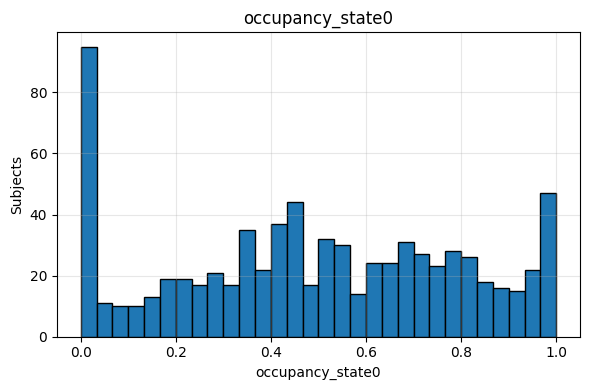

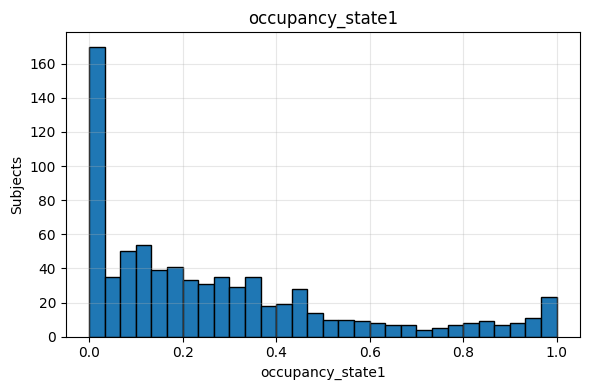

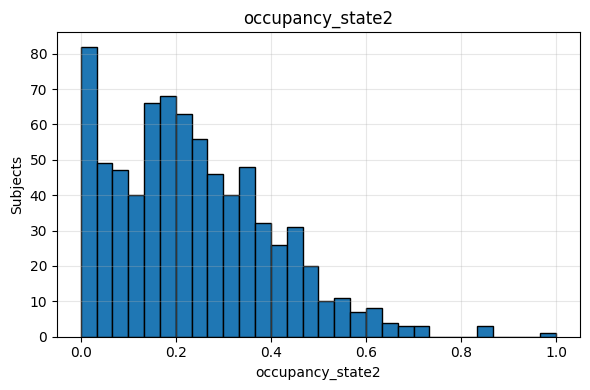

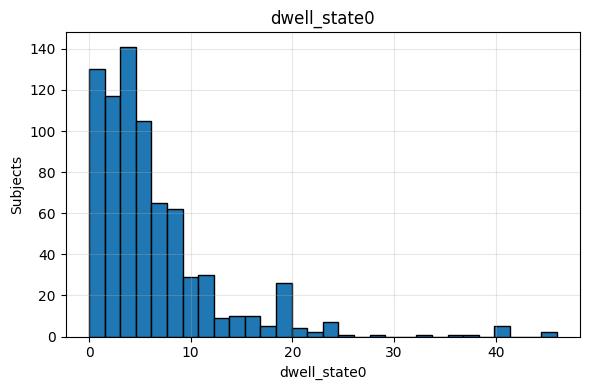

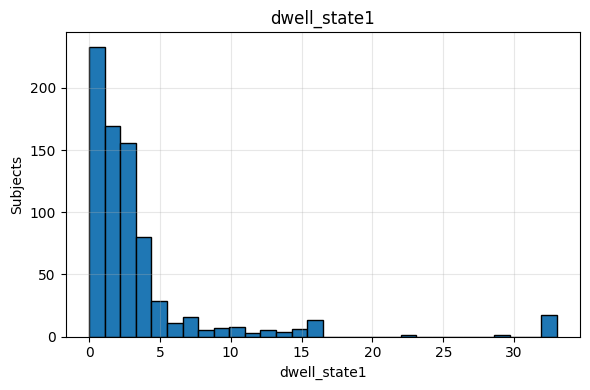

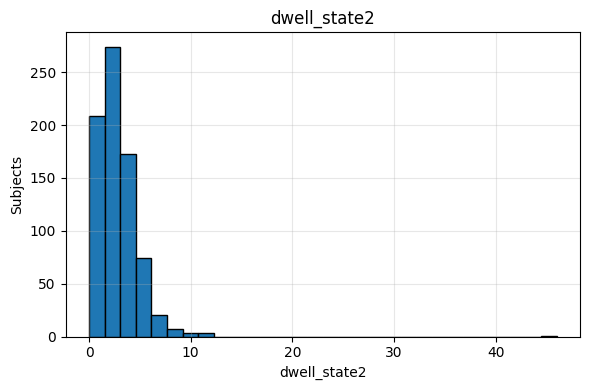

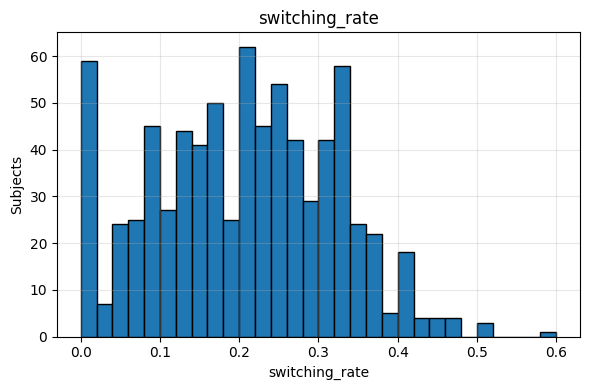

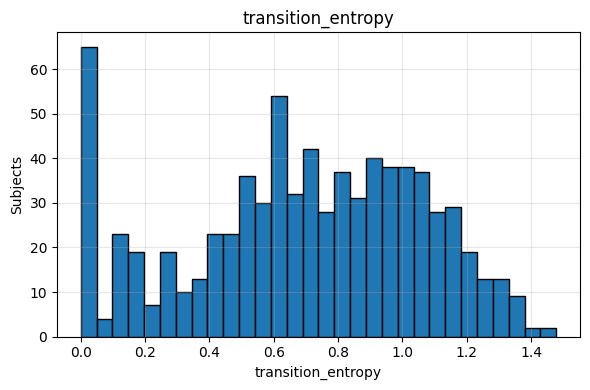

In [248]:
import matplotlib.pyplot as plt
for feature in dynamic_features:
    plt.figure(figsize=(6,4))
    plt.hist(
        subject_dataset[feature],
        bins=30,
        edgecolor="black"
    )
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Subjects")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

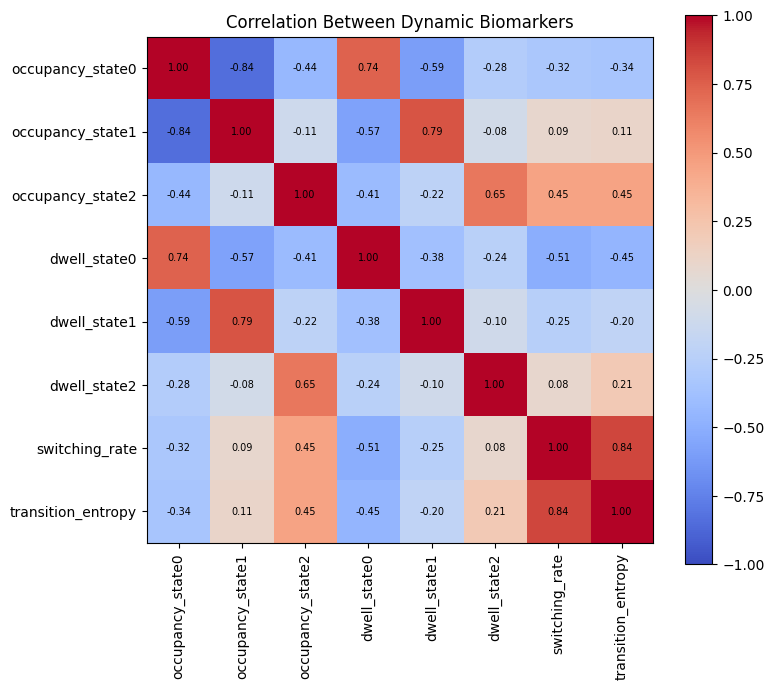

,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy
occupancy_state0,1.000,-0.840,-0.442,0.742,-0.595,-0.281,-0.323,-0.339
occupancy_state1,-0.840,1.000,-0.114,-0.572,0.791,-0.083,0.086,0.105
occupancy_state2,-0.442,-0.114,1.000,-0.414,-0.218,0.652,0.451,0.446
dwell_state0,0.742,-0.572,-0.414,1.000,-0.378,-0.242,-0.505,-0.453
dwell_state1,-0.595,0.791,-0.218,-0.378,1.000,-0.099,-0.253,-0.198
dwell_state2,-0.281,-0.083,0.652,-0.242,-0.099,1.000,0.085,0.211
switching_rate,-0.323,0.086,0.451,-0.505,-0.253,0.085,1.000,0.839
transition_entropy,-0.339,0.105,0.446,-0.453,-0.198,0.211,0.839,1.000


In [249]:
import numpy as np
corr = subject_dataset[dynamic_features].corr()
plt.figure(figsize=(8,7))
plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.colorbar()
plt.xticks(
    np.arange(len(dynamic_features)),
    dynamic_features,
    rotation=90
)
plt.yticks(
    np.arange(len(dynamic_features)),
    dynamic_features
)
for i in range(len(dynamic_features)):
    for j in range(len(dynamic_features)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )
plt.title("Correlation Between Dynamic Biomarkers")
plt.tight_layout()
plt.show()
display(corr.round(3))

In [250]:
pairs = []
for i in range(len(dynamic_features)):
    for j in range(i+1, len(dynamic_features)):
        r = corr.iloc[i,j]
        if abs(r) >= 0.80:
            pairs.append([
                dynamic_features[i],
                dynamic_features[j],
                r
            ])
pairs = pd.DataFrame(
    pairs,
    columns=[
        "Feature 1",
        "Feature 2",
        "Correlation"
    ]
)

display(pairs.sort_values(
    "Correlation",
    key=np.abs,
    ascending=False
))

,Feature 1,Feature 2,Correlation
0,occupancy_state0,occupancy_state1,-0.840454
1,switching_rate,transition_entropy,0.839456


In [252]:
OUT = Path("/home/nvidia/23BRS1236/adhd_data/workflow2/v8")
summary.to_csv(
    OUT/"subject_feature_summary.csv"
)
corr.to_csv(
    OUT/"subject_feature_correlation.csv"
)

# Phase VIII-H — Statistical Assumption Assessment

## Objective

The subject-level dynamic biomarker dataset has now been validated and is ready for inferential statistical analysis.
However, selecting an appropriate statistical test requires verification of the underlying assumptions.
This phase evaluates the distributional properties of every dynamic biomarker separately within the ADHD and Control groups.
The following assumptions are examined:
- Normality using the Shapiro–Wilk test.
- Equality of variances using Levene's test.

These diagnostics determine whether subsequent group comparisons should be performed using parametric or non-parametric statistical methods.
No hypothesis testing between ADHD and Control is performed in this phase.
Instead, the objective is to identify the most appropriate statistical methodology for each biomarker.

## Biomarkers Evaluated

- Fractional Occupancy (States 0–2)
- Mean Dwell Time (States 0–2)
- Switching Rate
- Markov Transition Entropy

In [253]:
from scipy.stats import shapiro
from scipy.stats import levene
features = [
    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",

    "dwell_state0",
    "dwell_state1",
    "dwell_state2",

    "switching_rate",

    "transition_entropy"
]
control = subject_dataset[
    subject_dataset["diagnosis_binary"] == 0
]
adhd = subject_dataset[
    subject_dataset["diagnosis_binary"] == 1
]
print("="*60)
print("Controls :", len(control))
print("ADHD     :", len(adhd))
print("="*60)

Controls : 484
ADHD     : 280


In [254]:
results = []
for feature in features:
    W_control, p_control = shapiro(control[feature])
    W_adhd, p_adhd = shapiro(adhd[feature])
    results.append({
        "Feature": feature,
        "W_Control": W_control,
        "P_Control": p_control,
        "W_ADHD": W_adhd,
        "P_ADHD": p_adhd
    })
shapiro_results = pd.DataFrame(results)
display(shapiro_results.round(4))

,Feature,W_Control,P_Control,W_ADHD,P_ADHD
0,occupancy_state0,0.9263,0.0,0.9731,0.000
1,occupancy_state1,0.8328,0.0,0.9508,0.000
2,occupancy_state2,0.9528,0.0,0.9548,0.000
3,dwell_state0,0.7682,0.0,0.7104,0.000
4,dwell_state1,0.5907,0.0,0.9661,0.000
5,dwell_state2,0.9330,0.0,0.4787,0.000
6,switching_rate,0.9753,0.0,0.9850,0.005
7,transition_entropy,0.9667,0.0,0.9438,0.000


In [255]:
alpha = 0.05
summary = []
for _, row in shapiro_results.iterrows():
    control_normal = row["P_Control"] > alpha
    adhd_normal = row["P_ADHD"] > alpha
    summary.append({
        "Feature": row["Feature"],
        "Control Normal": control_normal,
        "ADHD Normal": adhd_normal,
        "Parametric Candidate":
            control_normal and adhd_normal
    })
normality_summary = pd.DataFrame(summary)
display(normality_summary)

,Feature,Control Normal,ADHD Normal,Parametric Candidate
0,occupancy_state0,False,False,False
1,occupancy_state1,False,False,False
2,occupancy_state2,False,False,False
3,dwell_state0,False,False,False
4,dwell_state1,False,False,False
5,dwell_state2,False,False,False
6,switching_rate,False,False,False
7,transition_entropy,False,False,False


In [256]:
levene_results = []
for feature in features:
    stat, p = levene(
        control[feature],
        adhd[feature]
    )
    levene_results.append({
        "Feature": feature,
        "Statistic": stat,
        "P_Value": p,
        "EqualVariance": p > 0.05
    })
levene_results = pd.DataFrame(levene_results)
display(levene_results.round(4))

,Feature,Statistic,P_Value,EqualVariance
0,occupancy_state0,25.9564,0.0000,False
1,occupancy_state1,44.7334,0.0000,False
2,occupancy_state2,0.0016,0.9684,True
3,dwell_state0,4.2783,0.0389,False
4,dwell_state1,39.0563,0.0000,False
5,dwell_state2,0.0090,0.9243,True
6,switching_rate,5.1043,0.0241,False
7,transition_entropy,3.1596,0.0759,True


In [257]:
decision = (
    normality_summary
    .merge(
        levene_results,
        on="Feature"
    )
)
decision["Recommended Test"] = np.where(
    decision["Parametric Candidate"],
    "Welch t-test",
    "Mann-Whitney U"
)
display(decision)

,Feature,Control Normal,ADHD Normal,Parametric Candidate,Statistic,P_Value,EqualVariance,Recommended Test
0,occupancy_state0,False,False,False,25.956375,4.406926e-07,False,Mann-Whitney U
1,occupancy_state1,False,False,False,44.733392,4.368923e-11,False,Mann-Whitney U
2,occupancy_state2,False,False,False,0.001568,9.684195e-01,True,Mann-Whitney U
3,dwell_state0,False,False,False,4.278266,3.893955e-02,False,Mann-Whitney U
4,dwell_state1,False,False,False,39.056304,6.848110e-10,False,Mann-Whitney U
5,dwell_state2,False,False,False,0.009044,9.242612e-01,True,Mann-Whitney U
6,switching_rate,False,False,False,5.104253,2.414902e-02,False,Mann-Whitney U
7,transition_entropy,False,False,False,3.159551,7.588272e-02,True,Mann-Whitney U


# Phase VIII-H2 — Distribution Diagnostics

## Objective

Formal statistical tests indicated statistically significant departures from normality for all dynamic biomarkers.

However, the Shapiro–Wilk test is highly sensitive for large sample sizes and frequently rejects the null hypothesis for minor deviations from a Gaussian distribution.
Consequently, visual assessment of the empirical distributions was performed before selecting the final inferential statistical methodology.
Distribution diagnostics included:
- Histograms
- Quantile–Quantile (Q–Q) plots
- Group-specific boxplots

The objective of this phase is to determine whether observed departures from normality are sufficiently severe to justify non-parametric inference or whether robust parametric methods remain appropriate.

The results of this phase guide the final statistical methodology used for ADHD-versus-Control comparisons.

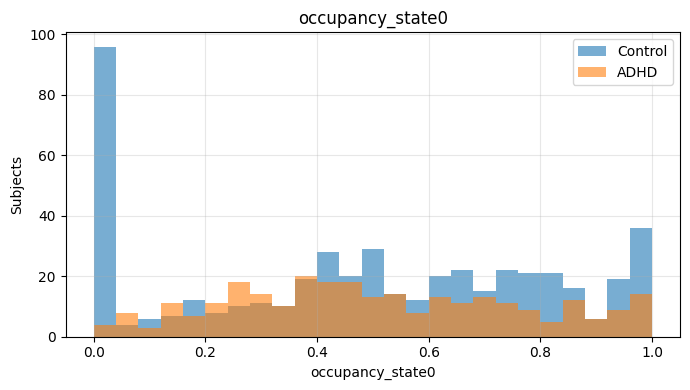

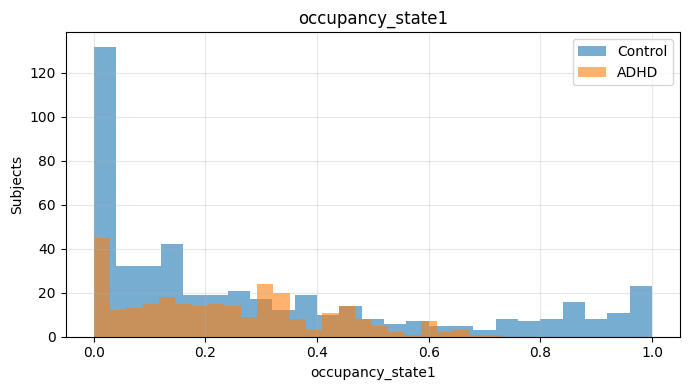

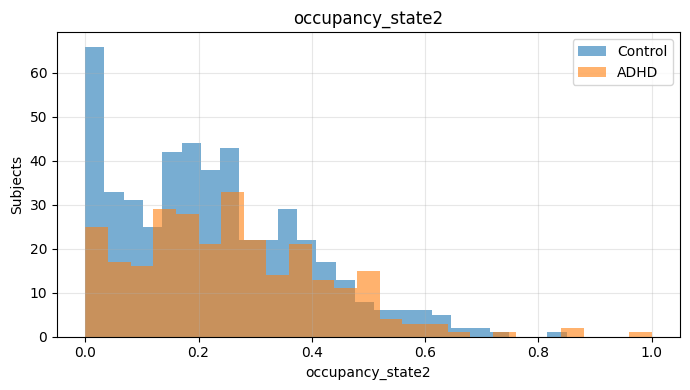

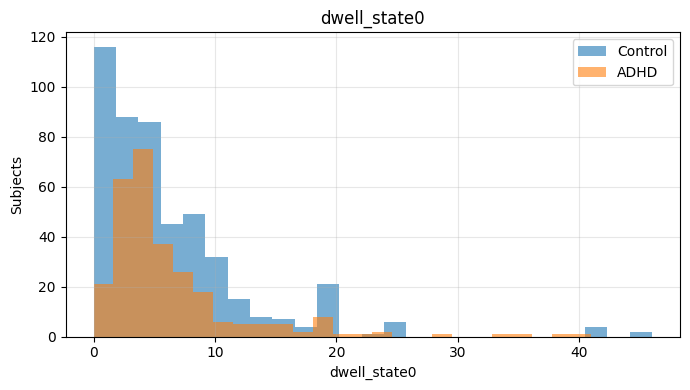

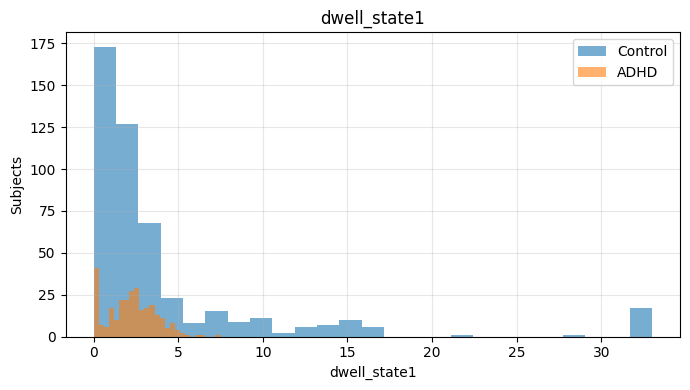

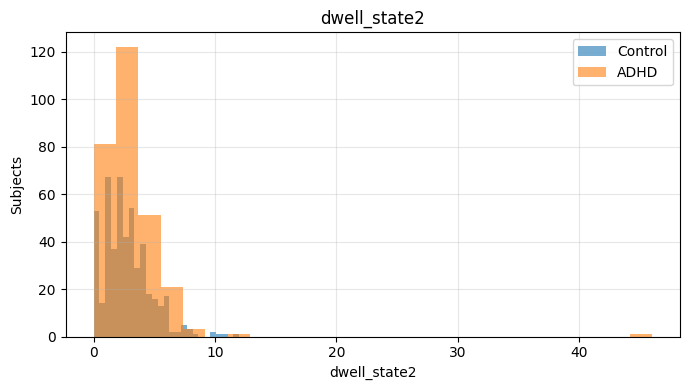

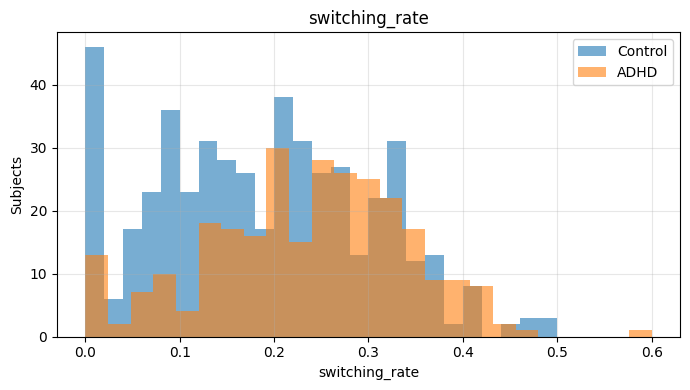

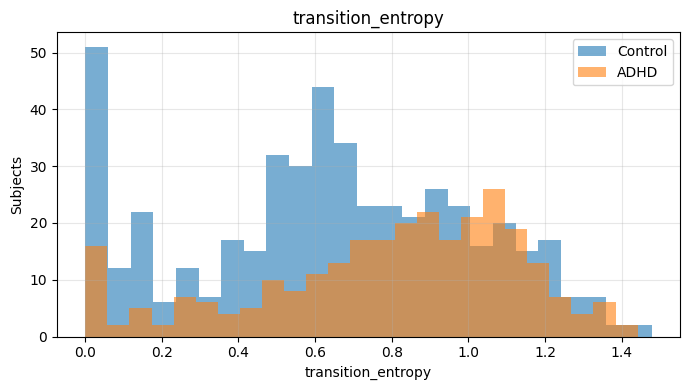

In [258]:
# Distribution by Diagnosis
import matplotlib.pyplot as plt

for feature in features:
    fig, ax = plt.subplots(figsize=(7,4))
    ax.hist(
        control[feature],
        bins=25,
        alpha=0.6,
        label="Control"
    )
    ax.hist(
        adhd[feature],
        bins=25,
        alpha=0.6,
        label="ADHD"
    )
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Subjects")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

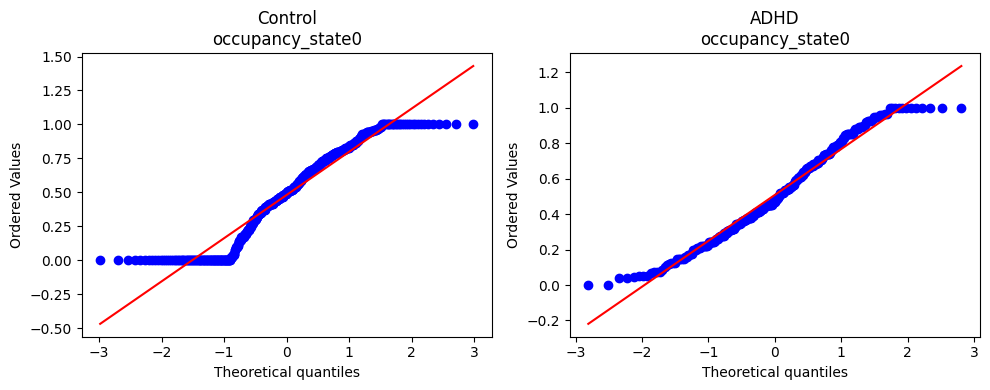

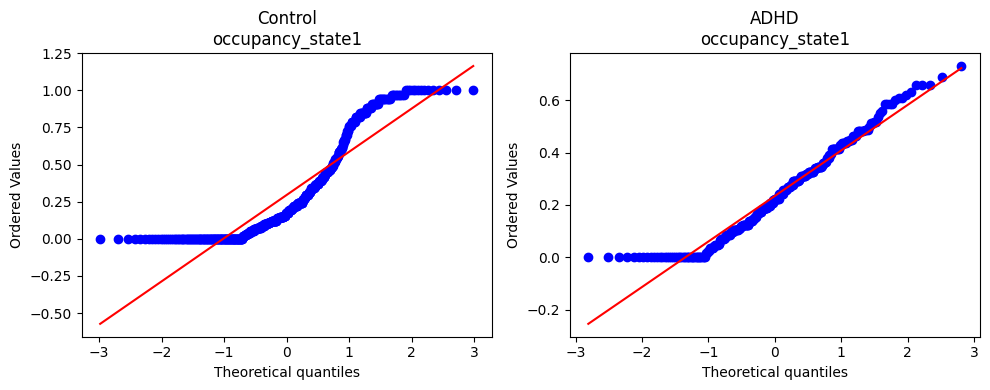

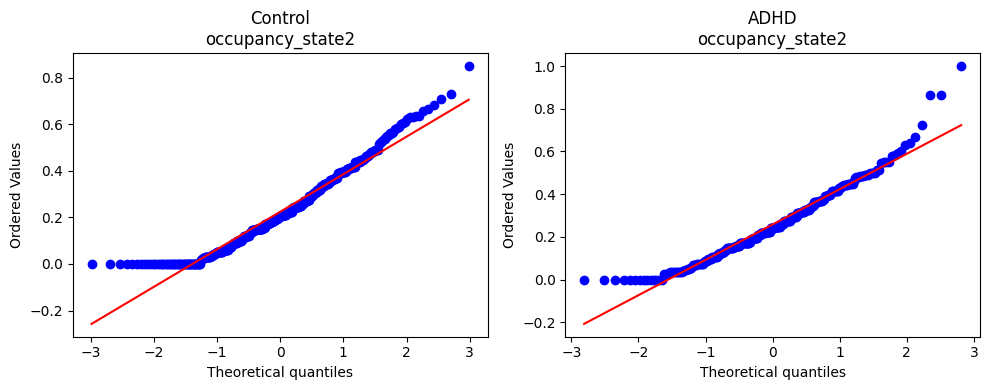

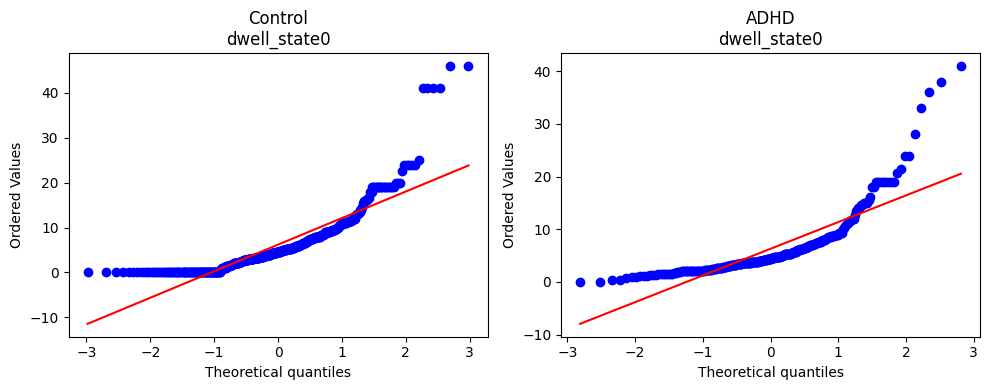

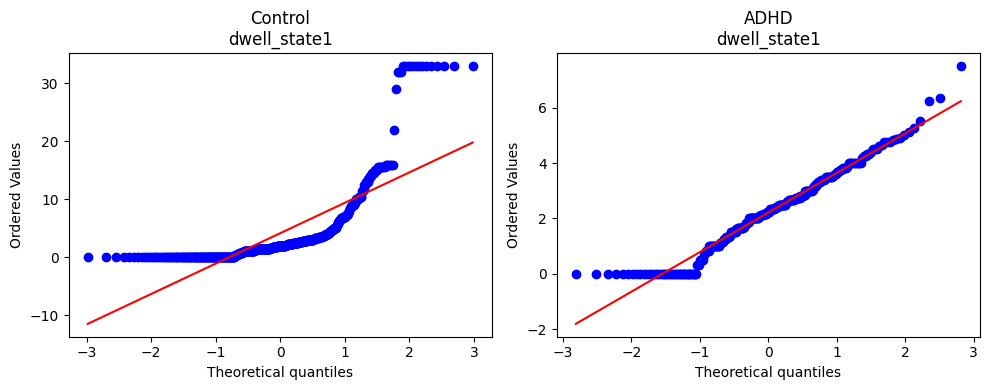

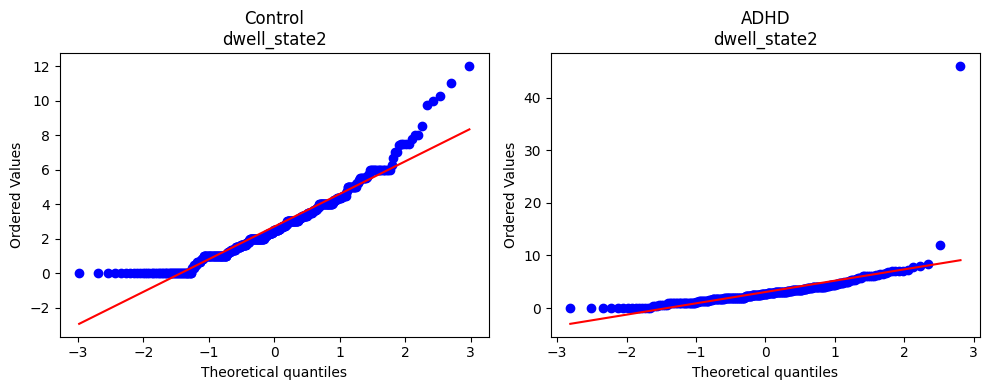

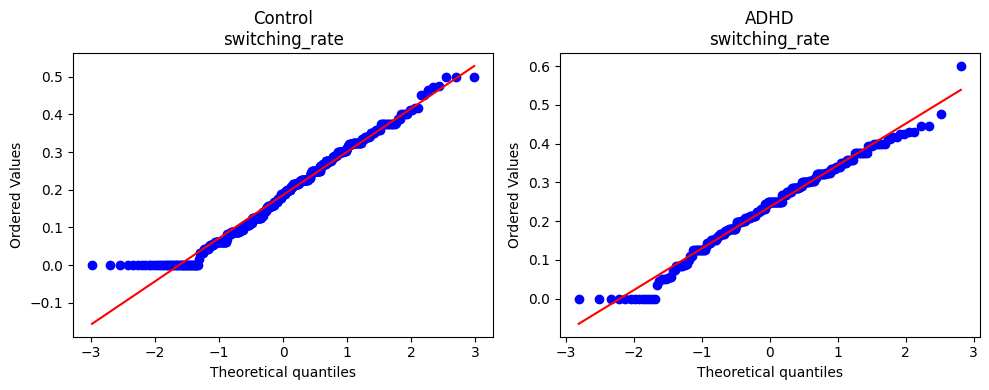

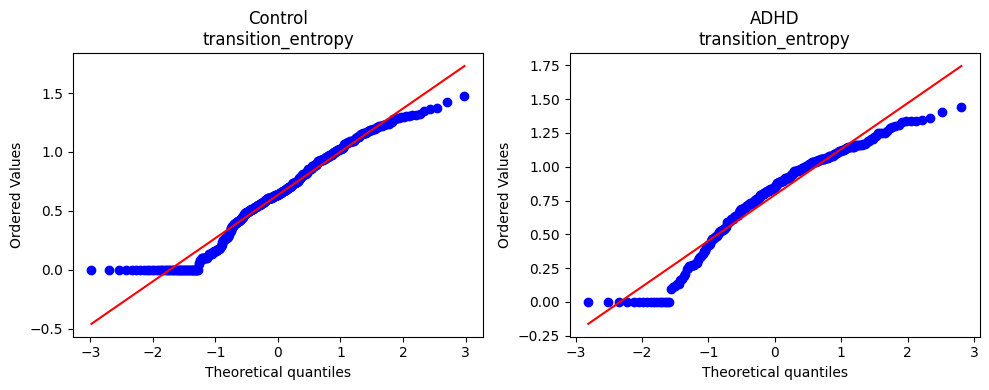

In [259]:
# Q-Q Plots
from scipy.stats import probplot
for feature in features:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10,4)
    )
    probplot(
        control[feature],
        dist="norm",
        plot=axes[0]
    )
    axes[0].set_title(
        f"Control\n{feature}"
    )
    probplot(
        adhd[feature],
        dist="norm",
        plot=axes[1]
    )
    axes[1].set_title(
        f"ADHD\n{feature}"
    )
    plt.tight_layout()
    plt.show()

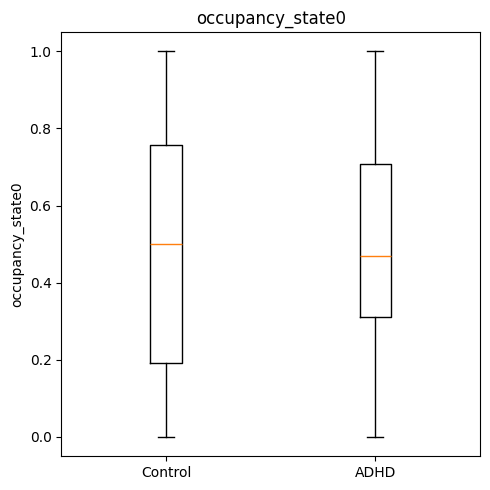

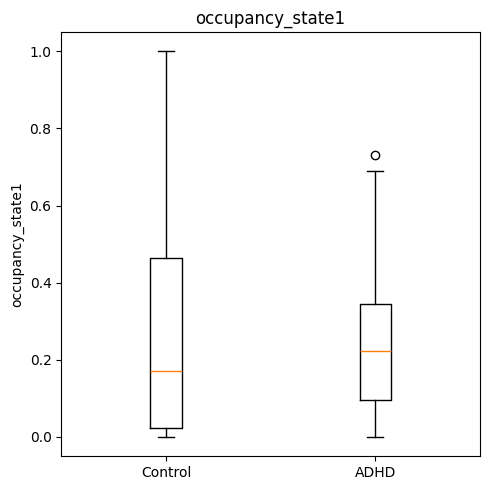

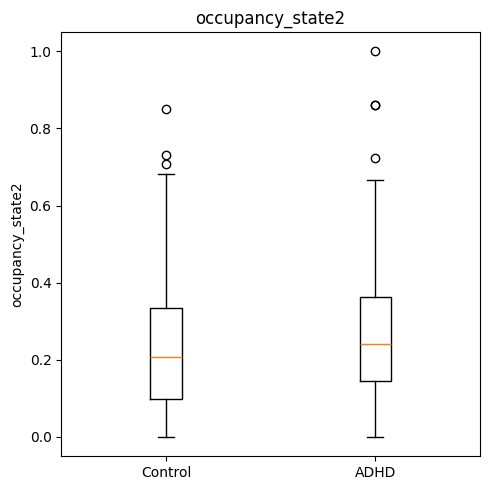

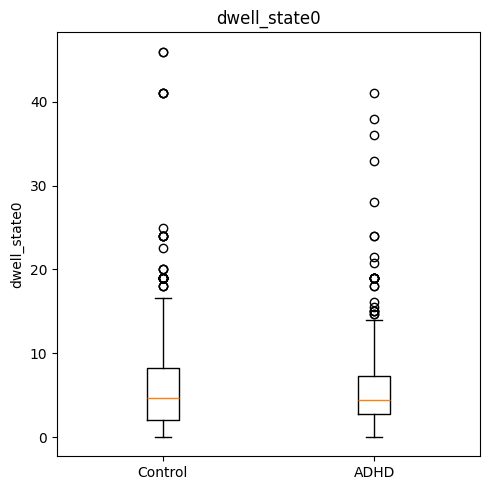

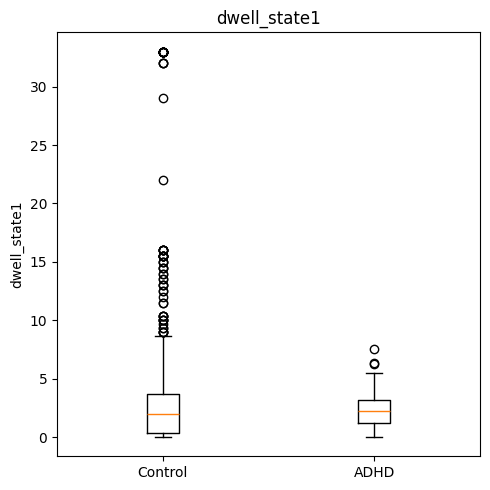

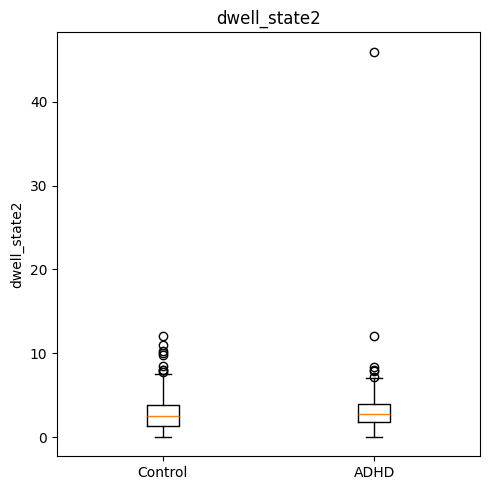

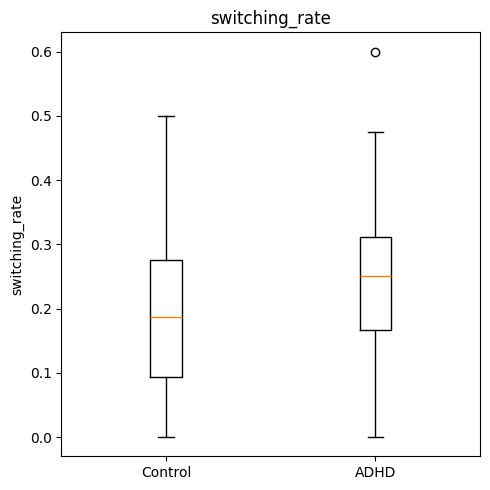

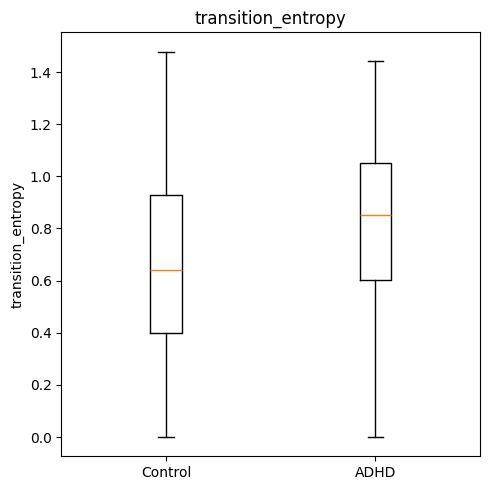

In [260]:
for feature in features:
    plt.figure(figsize=(5,5))
    plt.boxplot(
        [
            control[feature],
            adhd[feature]
        ],
        tick_labels=[
            "Control",
            "ADHD"
        ]
    )
    plt.title(feature)
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [261]:
from scipy.stats import skew
from scipy.stats import kurtosis
distribution_summary = []
for feature in features:
    distribution_summary.append({
        "Feature": feature,
        "Control Skew": skew(control[feature]),
        "ADHD Skew": skew(adhd[feature]),
        "Control Kurtosis": kurtosis(control[feature]),
        "ADHD Kurtosis": kurtosis(adhd[feature])
    })
distribution_summary = pd.DataFrame(
    distribution_summary
)
display(
    distribution_summary.round(3)
)

,Feature,Control Skew,ADHD Skew,Control Kurtosis,ADHD Kurtosis
0,occupancy_state0,-0.107,0.180,-1.201,-0.872
1,occupancy_state1,0.967,0.468,-0.381,-0.540
2,occupancy_state2,0.678,0.848,0.108,1.359
3,dwell_state0,2.533,2.778,9.667,9.852
4,dwell_state1,2.964,0.272,9.084,-0.044
5,dwell_state2,1.067,9.385,2.061,124.463
6,switching_rate,0.199,-0.199,-0.642,-0.061
7,transition_entropy,-0.123,-0.703,-0.820,-0.189


In [262]:
decision = pd.DataFrame({
    "Feature": features,
    "Sample Size": f"{len(control)} vs {len(adhd)}",
    "Normality": "Rejected (Shapiro)",
    "Visual Assessment": "Review Q-Q Plot",
    "Primary Test": "Welch's t-test",
    "Sensitivity Analysis": "Mann–Whitney U"
})
display(decision)

,Feature,Sample Size,Normality,Visual Assessment,Primary Test,Sensitivity Analysis
0,occupancy_state0,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U
1,occupancy_state1,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U
2,occupancy_state2,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U
3,dwell_state0,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U
4,dwell_state1,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U
5,dwell_state2,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U
6,switching_rate,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U
7,transition_entropy,484 vs 280,Rejected (Shapiro),Review Q-Q Plot,Welch's t-test,Mann–Whitney U


In [263]:
subject_dataset["dwell_state2"].describe()

count    764.000000
mean       2.829163
std        2.452664
min        0.000000
25%        1.412500
50%        2.500000
75%        3.861607
max       46.000000
Name: dwell_state2, dtype: float64

In [264]:
subject_dataset.nlargest(
    10,
    "dwell_state2"
)[
    [
        "subject_id",
        "site",
        "diagnosis_code",
        "dwell_state2"
    ]
]

,subject_id,site,diagnosis_code,dwell_state2
612,3808273,NeuroIMAGE,1,46.000000
68,10072,NYU,1,12.000000
477,2671604,NeuroIMAGE,0,12.000000
260,16082,Pittsburgh,0,11.000000
89,10093,NYU,0,10.250000
386,1962503,KKI,0,10.000000
90,10094,NYU,0,9.750000
138,15020,WashU,0,8.500000
4,10005,NYU,2,8.333333
267,16089,Pittsburgh,0,8.000000


# Inspecting subject 3808273

In [265]:
run_sequences[
    run_sequences["subject_id"] == 3808273
]

,subject_id,site,session,run,diagnosis_code,state_sequence,n_windows,states_present,n_states,diagnosis_binary
983,3808273,NeuroIMAGE,1,1,1,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",46,[2],1,1


In [266]:
run_features[
    run_features["subject_id"] == 3808273
]

,subject_id,site,session,run,diagnosis_code,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,diagnosis_binary
983,3808273,NeuroIMAGE,1,1,1,0.0,0.0,1.0,0.0,0.0,46.0,0.0,1


In [267]:
window_df[
    window_df["subject_id"] == 3808273
].head(60)

,nodes,edges,density,components,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,builder,distance_metric,subject_id,site,session,run,window_index,label,Age,Gender,Handedness,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma,brain_state,label_binary
14436,190,3591,0.2,1,37.8,34.760224,0.532939,0.722487,0.461519,0.678752,0.288314,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,0,1,14.25,1.0,1.0,0.532004,0.670873,0.421936,3.549334,1.014117,0.995939,1.018252,2,1
14437,190,3591,0.2,1,37.8,35.025191,0.518795,0.734143,0.453390,0.650952,0.323317,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,1,1,14.25,1.0,1.0,0.511542,0.686291,0.417023,3.893884,1.009233,0.993479,1.015857,2,1
14438,190,3591,0.2,1,37.8,35.004106,0.532474,0.714079,0.464301,0.668161,0.297949,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,2,1,14.25,1.0,1.0,0.509266,0.667755,0.426934,3.516656,1.011962,1.001876,1.010067,2,1
14439,190,3591,0.2,1,37.8,34.879896,0.550949,0.716263,0.464073,0.692657,0.299106,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,3,1,14.25,1.0,1.0,0.513843,0.667219,0.425432,3.558283,1.010898,0.999441,1.011464,2,1
14440,190,3591,0.2,1,37.8,34.041210,0.503318,0.707616,0.462659,0.645324,0.366442,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,4,1,14.25,1.0,1.0,0.513195,0.645150,0.413462,3.657887,1.016126,0.996129,1.020075,2,1
14441,190,3591,0.2,1,37.8,34.587875,0.549081,0.723066,0.454751,0.696723,0.349650,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,5,1,14.25,1.0,1.0,0.545869,0.669615,0.413379,3.967868,1.016548,0.995452,1.021192,2,1
14442,190,3591,0.2,1,37.8,35.638665,0.587209,0.744374,0.437647,0.710236,0.264785,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,6,1,14.25,1.0,1.0,0.585194,0.707494,0.409964,4.162562,1.012625,1.000754,1.011861,2,1
14443,190,3591,0.2,1,37.8,35.957510,0.591360,0.753111,0.427863,0.709795,0.234055,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,7,1,14.25,1.0,1.0,0.589878,0.721543,0.404691,4.405143,1.012418,0.999020,1.013410,2,1
14444,190,3591,0.2,1,37.8,36.286626,0.614339,0.748601,0.426948,0.737361,0.173589,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,8,1,14.25,1.0,1.0,0.612236,0.723402,0.408134,4.321307,1.010601,0.997594,1.013039,2,1
14445,190,3591,0.2,1,37.8,36.803192,0.636657,0.778520,0.423103,0.751676,0.103493,MST_PT_v1.0,1-|r|,3808273,NeuroIMAGE,1,1,9,1,14.25,1.0,1.0,0.630756,0.761580,0.410677,4.204802,1.007826,0.998917,1.008918,2,1


In [270]:
seq = window_df.loc[
    window_df["subject_id"] == 3808273,
    "brain_state"
].tolist()

print(",".join(map(str, seq)))

2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [271]:
single_state = subject_dataset[
    (subject_dataset["occupancy_state0"] == 1.0) |
    (subject_dataset["occupancy_state1"] == 1.0) |
    (subject_dataset["occupancy_state2"] == 1.0)
]

display(
    single_state[
        [
            "subject_id",
            "site",
            "diagnosis_code",
            "occupancy_state0",
            "occupancy_state1",
            "occupancy_state2",
            "switching_rate",
            "transition_entropy"
        ]
    ]
)

,subject_id,site,diagnosis_code,occupancy_state0,occupancy_state1,occupancy_state2,switching_rate,transition_entropy
136,15017,WashU,0,1.0,0.0,0.0,0.0,0.0
159,15042,WashU,0,1.0,0.0,0.0,0.0,0.0
184,16005,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0
192,16013,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0
193,16014,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0
200,16021,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0
201,16022,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0
209,16030,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0
211,16032,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0
214,16035,Pittsburgh,0,0.0,1.0,0.0,0.0,0.0


In [272]:
single_state["dominant_state"] = np.select(
    [
        single_state["occupancy_state0"] == 1,
        single_state["occupancy_state1"] == 1,
        single_state["occupancy_state2"] == 1
    ],
    [
        0,1,2
    ]
)
pd.crosstab(
    single_state["site"],
    single_state["dominant_state"]
)

dominant_state,0,1,2
site,,,
KKI,31,0,0
NeuroIMAGE,2,0,1
OHSU,3,0,0
Peking_1,2,0,0
Peking_2,2,0,0
Peking_3,1,0,0
Pittsburgh,0,14,0
WashU,2,0,0


# Investigating the special state issue

In [273]:
site_summary = (
    subject_dataset
    .groupby("site")[
        [
            "occupancy_state0",
            "occupancy_state1",
            "occupancy_state2",
            "switching_rate",
            "transition_entropy"
        ]
    ]
    .mean()
)

display(site_summary.round(3))

,occupancy_state0,occupancy_state1,occupancy_state2,switching_rate,transition_entropy
site,,,,,
KKI,0.855,0.005,0.140,0.090,0.297
NYU,0.474,0.242,0.285,0.254,0.853
NeuroIMAGE,0.545,0.220,0.235,0.226,0.892
OHSU,0.592,0.148,0.260,0.187,0.376
Peking_1,0.514,0.243,0.242,0.257,0.950
Peking_2,0.455,0.280,0.265,0.262,0.919
Peking_3,0.372,0.347,0.281,0.288,0.985
Pittsburgh,0.000,0.864,0.136,0.100,0.434
WashU,0.688,0.071,0.242,0.151,0.465


In [274]:
site_counts = (
    subject_dataset
    .groupby("site")
    .size()
    .rename("Subjects")
)

display(site_counts)

site
KKI            83
NYU           215
NeuroIMAGE     48
OHSU           79
Peking_1       85
Peking_2       67
Peking_3       42
Pittsburgh     88
WashU          57
Name: Subjects, dtype: int64

In [275]:
dominant_state = np.argmax(
    subject_dataset[
        [
            "occupancy_state0",
            "occupancy_state1",
            "occupancy_state2"
        ]
    ].values,
    axis=1
)

subject_dataset["dominant_state"] = dominant_state

pd.crosstab(
    subject_dataset["site"],
    subject_dataset["dominant_state"],
    normalize="index"
).round(3)

dominant_state,0,1,2
site,,,
KKI,0.952,0.000,0.048
NYU,0.656,0.158,0.186
NeuroIMAGE,0.750,0.167,0.083
OHSU,0.734,0.127,0.139
Peking_1,0.729,0.165,0.106
Peking_2,0.567,0.269,0.164
Peking_3,0.429,0.357,0.214
Pittsburgh,0.000,0.977,0.023
WashU,0.860,0.035,0.105


# Phase VIII-H3 — Site Dependence of Dynamic Brain States

## Objective

The ADHD-200 dataset is inherently multi-site, with subjects acquired using different scanners, imaging protocols, and acquisition parameters. Such heterogeneity is known to introduce site-specific variability that may influence downstream dynamic functional connectivity analyses.

The previous analyses indicated that certain acquisition sites preferentially occupied specific brain states, suggesting that the discovered clusters may retain residual site-specific information.

This phase quantitatively evaluates the relationship between acquisition site and the derived dynamic biomarkers.

Specifically, we investigate:

- Mean dynamic biomarkers across imaging sites.
- Distribution of dominant brain states across sites.
- Statistical association between acquisition site and dominant brain state.
- Statistical differences in dynamic biomarkers across sites.
- Effect size of site-related variability.

These analyses determine whether the identified brain states primarily reflect biological dynamics or retain measurable acquisition-site dependence.

In [276]:
site_summary=subject_dataset.groupby("site")[["occupancy_state0","occupancy_state1","occupancy_state2","dwell_state0","dwell_state1","dwell_state2","switching_rate","transition_entropy"]].agg(["mean","std","median"])

print("="*70)
print("Site-wise Dynamic Biomarkers")
print("="*70)

display(site_summary.round(3))

Site-wise Dynamic Biomarkers


occupancy_state0               occupancy_state1               occupancy_state2               dwell_state0                dwell_state1                dwell_state2                \
                       mean    std median             mean    std median             mean    std median         mean    std  median         mean    std  median         mean    std median   
site                                                                                                                                                                                         
KKI                   0.855  0.174  0.947            0.005  0.015  0.000            0.140  0.170  0.053       13.041  6.543  11.500        0.096  0.297   0.000        1.948  2.252  1.000   
NYU                   0.474  0.212  0.466            0.242  0.158  0.224            0.285  0.155  0.276        5.572  4.041   4.567        2.433  1.304   2.333        3.347  1.840  3.000   
NeuroIMAGE            0.545  0.251  0.543            0.220  0.169  0.196            0.235  0.173  0.207        8.286  9.404   4.750        2.215  1.450   2.250        3.858  6.515  2.667   
OHSU                  0.592  0.278  0.630            0.148  0.167  0.111            0.260  0.172  0.222        4.722  2.383   4.833        1.099  1.247   0.833        1.866  1.358  1.667   
Peking_1              0.514  0.229  0.512            0.243  0.165  0.220            0.242  0.148  0.244        6.039  6.056   4.833        2.473  1.294   2.333        2.895  1.480  2.667   
Peking_2              0.455  0.265  0.439            0.280  0.193  0.244            0.265  0.165  0.244        7.014  8.892   3.667        2.544  1.422   2.286        3.101  1.725  3.000   
Peking_3              0.372  0.225  0.354            0.347  0.183  0.341            0.281  0.160  0.293        5.282  7.828   3.250        2.887  1.254   2.800        3.021  1.439  2.917   
Pittsburgh            0.000  0.000  0.000            0.864  0.124  0.879            0.136  0.124  0.121        0.000  0.000   0.000       15.394  9.457  13.000        2.246  1.943  2.000   
WashU                 0.688  0.223  0.750            0.071  0.116  0.000            0.242  0.170  0.200        8.910  4.710   8.167        0.775  1.186   0.000        2.967  2.041  2.556   

           switching_rate               transition_entropy                
                     mean    std median               mean    std median  
site                                                                      
KKI                 0.090  0.100  0.087              0.297  0.297  0.161  
NYU                 0.254  0.082  0.250              0.853  0.221  0.860  
NeuroIMAGE          0.226  0.102  0.244              0.892  0.341  0.988  
OHSU                0.187  0.110  0.167              0.376  0.219  0.350  
Peking_1            0.257  0.093  0.250              0.950  0.285  0.992  
Peking_2            0.262  0.114  0.275              0.919  0.328  0.957  
Peking_3            0.288  0.101  0.300              0.985  0.288  1.054  
Pittsburgh          0.100  0.072  0.094              0.434  0.292  0.560  
WashU               0.151  0.087  0.140              0.465  0.227  0.493

In [277]:
subject_dataset["dominant_state"]=subject_dataset[["occupancy_state0","occupancy_state1","occupancy_state2"]].idxmax(axis=1).str[-1].astype(int)
dominant_table=pd.crosstab(subject_dataset["site"],subject_dataset["dominant_state"])
dominant_percentage=pd.crosstab(subject_dataset["site"],subject_dataset["dominant_state"],normalize="index")*100
print("="*70)
print("Dominant State Counts")
print("="*70)
display(dominant_table)
print("="*70)
print("Dominant State Percentage")
print("="*70)

display(dominant_percentage.round(2))

Dominant State Counts


dominant_state,0,1,2
site,,,
KKI,79,0,4
NYU,141,34,40
NeuroIMAGE,36,8,4
OHSU,58,10,11
Peking_1,62,14,9
Peking_2,38,18,11
Peking_3,18,15,9
Pittsburgh,0,86,2
WashU,49,2,6


Dominant State Percentage


dominant_state,0,1,2
site,,,
KKI,95.18,0.00,4.82
NYU,65.58,15.81,18.60
NeuroIMAGE,75.00,16.67,8.33
OHSU,73.42,12.66,13.92
Peking_1,72.94,16.47,10.59
Peking_2,56.72,26.87,16.42
Peking_3,42.86,35.71,21.43
Pittsburgh,0.00,97.73,2.27
WashU,85.96,3.51,10.53


In [278]:
from scipy.stats import chi2_contingency

chi2,p,dof,expected=chi2_contingency(dominant_table)

print("="*70)
print("Chi-Square Test")
print("="*70)
print(f"Chi-square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p:.6f}")

Chi-Square Test
Chi-square Statistic : 343.6566
Degrees of Freedom   : 16
P-value              : 0.000000


In [279]:
import numpy as np
n=dominant_table.values.sum()
phi2=chi2/n
r,c=dominant_table.shape
cramers_v=np.sqrt(phi2/min(r-1,c-1))
print("="*70)
print("Effect Size")
print("="*70)
print(f"Cramer's V : {cramers_v:.4f}")

Effect Size
Cramer's V : 0.4742


In [280]:
from scipy.stats import kruskal

features=["occupancy_state0","occupancy_state1","occupancy_state2","dwell_state0","dwell_state1","dwell_state2","switching_rate","transition_entropy"]
site_results=[]
for feature in features:
    groups=[group[feature].values for _,group in subject_dataset.groupby("site")]
    H,p=kruskal(*groups)
    site_results.append({"Feature":feature,"H Statistic":H,"P Value":p})

site_results=pd.DataFrame(site_results)

display(site_results.round(6))

,Feature,H Statistic,P Value
0,occupancy_state0,366.453182,0.0
1,occupancy_state1,428.614462,0.0
2,occupancy_state2,101.785237,0.0
3,dwell_state0,335.328100,0.0
4,dwell_state1,443.960163,0.0
5,dwell_state2,87.167025,0.0
6,switching_rate,275.680709,0.0
7,transition_entropy,375.601050,0.0


In [281]:
k=subject_dataset["site"].nunique()
N=len(subject_dataset)
site_results["Eta Squared"]=(site_results["H Statistic"]-k+1)/(N-k)
site_results["Eta Squared"]=site_results["Eta Squared"].clip(lower=0)
display(site_results.round(4))

,Feature,H Statistic,P Value,Eta Squared
0,occupancy_state0,366.4532,0.0,0.4748
1,occupancy_state1,428.6145,0.0,0.5571
2,occupancy_state2,101.7852,0.0,0.1242
3,dwell_state0,335.3281,0.0,0.4335
4,dwell_state1,443.9602,0.0,0.5774
5,dwell_state2,87.1670,0.0,0.1049
6,switching_rate,275.6807,0.0,0.3545
7,transition_entropy,375.6011,0.0,0.4869


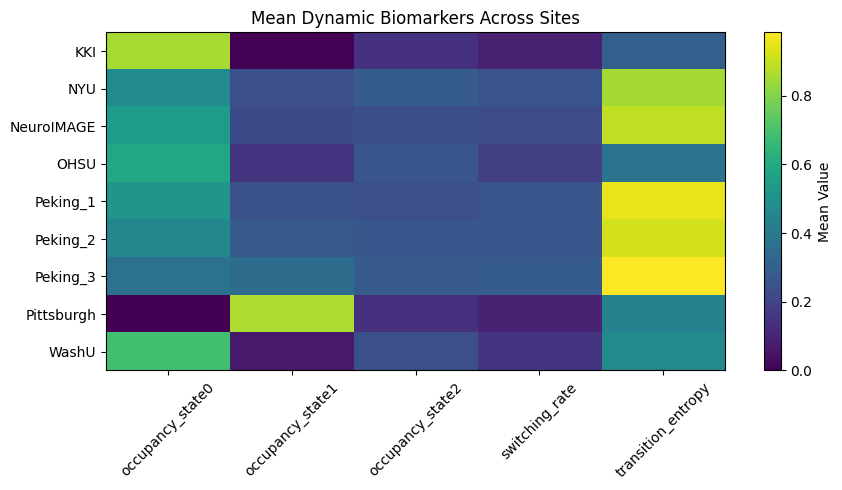

In [282]:
import matplotlib.pyplot as plt

heatmap_data=subject_dataset.groupby("site")[["occupancy_state0","occupancy_state1","occupancy_state2","switching_rate","transition_entropy"]].mean()

plt.figure(figsize=(9,5))
plt.imshow(heatmap_data,aspect="auto")
plt.xticks(range(len(heatmap_data.columns)),heatmap_data.columns,rotation=45)
plt.yticks(range(len(heatmap_data.index)),heatmap_data.index)
plt.colorbar(label="Mean Value")
plt.title("Mean Dynamic Biomarkers Across Sites")
plt.tight_layout()
plt.show()

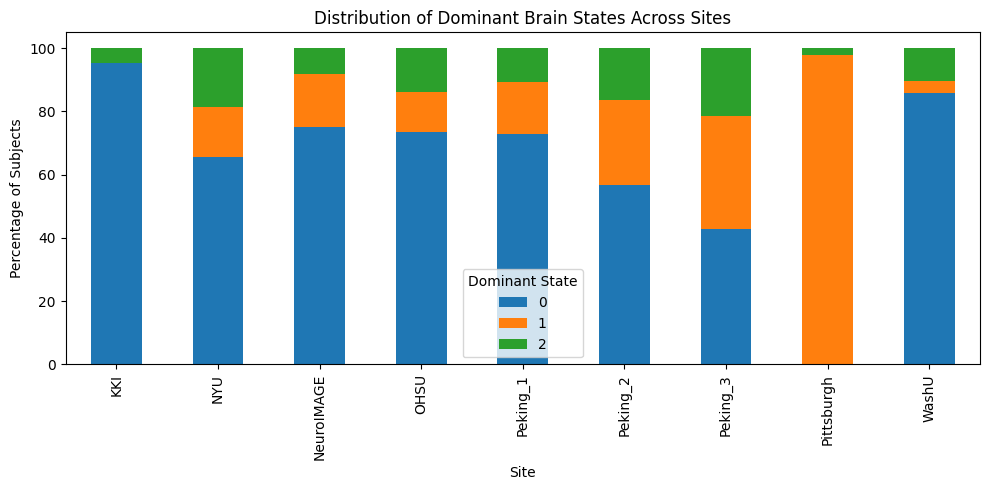

In [283]:
dominant_percentage.plot(kind="bar",stacked=True,figsize=(10,5))
plt.ylabel("Percentage of Subjects")
plt.xlabel("Site")
plt.title("Distribution of Dominant Brain States Across Sites")
plt.legend(title="Dominant State")
plt.tight_layout()
plt.show()

# Phase VIII-H4 — Source of Site Variability

## Objective

The previous analyses demonstrated that acquisition site is strongly associated with the discovered dynamic brain states.

However, site itself is not a biological variable. Instead, it represents a combination of differences in scanner hardware, acquisition protocols, participant demographics, and recording characteristics.

The objective of this phase is to determine whether the observed site dependence can be explained by measurable confounding variables already available in the dataset.

Specifically, we investigate:

- Age differences across sites.
- Sex distribution across sites.
- Scan length differences across sites.
- Diagnosis distribution across sites.
- Dynamic biomarkers after accounting for site.
- Predictability of acquisition site from dynamic biomarkers.

These analyses identify the primary contributors to the observed site dependence and determine whether the extracted biomarkers encode substantial site-specific information.

In [293]:
demographics = (
    window_df[
        [
            "subject_id",
            "Age",
            "Gender",
            "Handedness"
        ]
    ]
    .drop_duplicates(subset="subject_id")
)

print(demographics.shape)
display(demographics.head())

(764, 4)


,subject_id,Age,Gender,Handedness
0,1018959,12.36,0.0,1.0
24,1019436,12.98,1.0,1.0
48,1043241,9.12,1.0,1.0
72,1266183,9.67,0.0,1.0
91,1535233,9.64,1.0,0.0


In [294]:
subject_dataset = subject_dataset.merge(
    demographics,
    on="subject_id",
    how="left"
)

In [295]:
print(subject_dataset.columns)
print(
    subject_dataset[
        ["Age","Gender","Handedness"]
    ].isna().sum()
)

Index(['subject_id', 'site', 'diagnosis_code', 'diagnosis_binary', 'occupancy_state0', 'occupancy_state1', 'occupancy_state2', 'dwell_state0', 'dwell_state1', 'dwell_state2', 'switching_rate',
       'transition_entropy', 'C00', 'C01', 'C02', 'C10', 'C11', 'C12', 'C20', 'C21', 'C22', 'P00', 'P01', 'P02', 'P10', 'P11', 'P12', 'P20', 'P21', 'P22', 'dominant_state', 'Age', 'Gender',
       'Handedness'],
      dtype='object')
Age           0
Gender        1
Handedness    0
dtype: int64


In [296]:
subject_dataset.loc[
    subject_dataset["Gender"].isna(),
    ["subject_id","site","Age","diagnosis_code"]
]

,subject_id,site,Age,diagnosis_code
41,10044,NYU,9.81,1


In [297]:
from scipy.stats import kruskal

groups = [
    group["Age"].values
    for _, group in subject_dataset.groupby("site")
]
H, p = kruskal(*groups)
print("="*70)
print("Age Across Sites")
print("="*70)
print(f"H statistic : {H:.4f}")
print(f"P-value     : {p:.6f}")

Age Across Sites
H statistic : 304.8014
P-value     : 0.000000


<Figure size 1000x500 with 0 Axes>

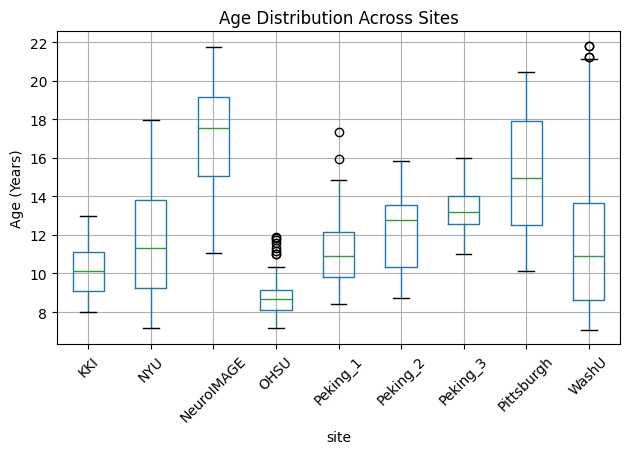

In [298]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

subject_dataset.boxplot(
    column="Age",
    by="site",
    rot=45
)

plt.suptitle("")
plt.title("Age Distribution Across Sites")
plt.ylabel("Age (Years)")
plt.tight_layout()
plt.show()

In [299]:
sex_table = pd.crosstab(
    subject_dataset["site"],
    subject_dataset["Gender"]
)

display(sex_table)

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(sex_table)
print("="*70)
print("Gender Distribution Across Sites")
print("="*70)
print(f"Chi-square : {chi2:.3f}")
print(f"P-value    : {p:.6f}")
print(f"Degrees of Freedom : {dof}")

Gender,0.0,1.0
site,,
KKI,37,46
NYU,74,140
NeuroIMAGE,17,31
OHSU,36,43
Peking_1,49,36
Peking_2,1,66
Peking_3,0,42
Pittsburgh,42,46
WashU,26,31


Gender Distribution Across Sites
Chi-square : 87.772
P-value    : 0.000000
Degrees of Freedom : 8


In [300]:
diagnosis_table = pd.crosstab(
    subject_dataset["site"],
    subject_dataset["diagnosis_binary"]
)

display(diagnosis_table)

chi2, p, dof, expected = chi2_contingency(diagnosis_table)

print("="*70)
print("Diagnosis Distribution Across Sites")
print("="*70)
print(f"Chi-square : {chi2:.3f}")
print(f"P-value    : {p:.6f}")
print(f"Degrees of Freedom : {dof}")

diagnosis_binary,0,1
site,,
KKI,61,22
NYU,97,118
NeuroIMAGE,23,25
OHSU,42,37
Peking_1,61,24
Peking_2,32,35
Peking_3,23,19
Pittsburgh,88,0
WashU,57,0


Diagnosis Distribution Across Sites
Chi-square : 137.747
P-value    : 0.000000
Degrees of Freedom : 8


In [301]:
scan_length = (
    run_sequences
    .groupby("site")["n_windows"]
    .describe()
)

display(scan_length)

,count,mean,std,min,25%,50%,75%,max
site,,,,,,,,
KKI,83.0,20.746988,2.398391,19.0,19.0,19.0,24.0,24.0
NYU,394.0,29.000000,0.000000,29.0,29.0,29.0,29.0,29.0
NeuroIMAGE,48.0,46.000000,0.000000,46.0,46.0,46.0,46.0,46.0
OHSU,237.0,8.987342,0.194871,6.0,9.0,9.0,9.0,9.0
Peking_1,85.0,41.000000,0.000000,41.0,41.0,41.0,41.0,41.0
Peking_2,67.0,41.000000,0.000000,41.0,41.0,41.0,41.0,41.0
Peking_3,42.0,41.000000,0.000000,41.0,41.0,41.0,41.0,41.0
Pittsburgh,88.0,33.000000,0.000000,33.0,33.0,33.0,33.0,33.0
WashU,149.0,18.228188,4.057227,9.0,20.0,20.0,20.0,20.0


In [302]:
groups = [
    group["n_windows"].values
    for _, group in run_sequences.groupby("site")
]
H, p = kruskal(*groups)
print("="*70)
print("Scan Length Across Sites")
print("="*70)
print(f"H statistic : {H:.4f}")
print(f"P-value     : {p:.6f}")

Scan Length Across Sites
H statistic : 1176.3230
P-value     : 0.000000


# Can Dynamic Biomarkers Predict Site?

In [303]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

features = [
    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",
    "dwell_state0",
    "dwell_state1",
    "dwell_state2",
    "switching_rate",
    "transition_entropy"
]

X = subject_dataset[features]
y = subject_dataset["site"]
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("="*70)
print("Predict Site from Dynamic Biomarkers")
print("="*70)
print(scores)
print()
print(f"Mean Accuracy : {scores.mean():.3f}")
print(f"Std Accuracy  : {scores.std():.3f}")

Predict Site from Dynamic Biomarkers
[0.5751634  0.59477124 0.61437908 0.59477124 0.57236842]

Mean Accuracy : 0.590
Std Accuracy  : 0.015


In [304]:
rf.fit(X, y)

importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": rf.feature_importances_
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(importance)

,Feature,Importance
3,dwell_state0,0.172758
7,transition_entropy,0.154133
0,occupancy_state0,0.139759
1,occupancy_state1,0.131385
4,dwell_state1,0.114163
6,switching_rate,0.111181
2,occupancy_state2,0.092940
5,dwell_state2,0.083681


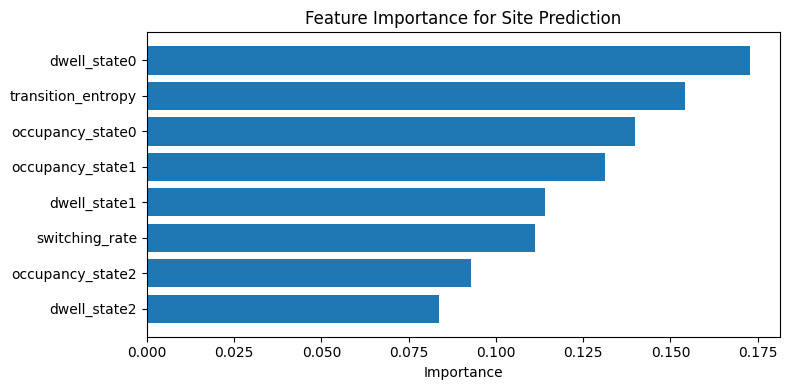

In [305]:
plt.figure(figsize=(8,4))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance for Site Prediction")

plt.tight_layout()
plt.show()

Which sites are being confused?

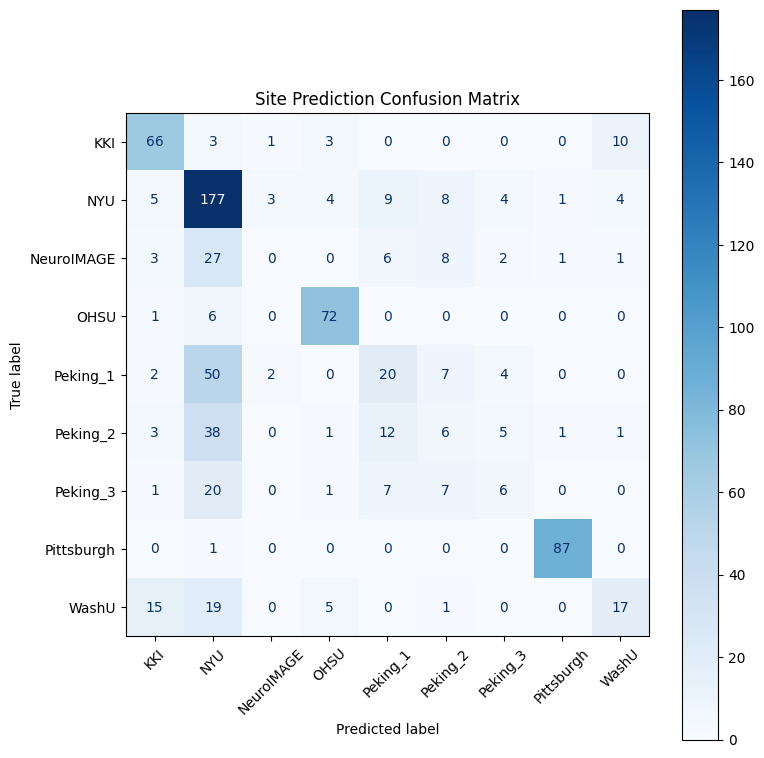

In [306]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = cross_val_predict(
    rf,
    X,
    y,
    cv=5
)
cm = confusion_matrix(
    y,
    pred,
    labels=sorted(y.unique())
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.title("Site Prediction Confusion Matrix")
plt.tight_layout()
plt.show()

## H4.7 Investigating Site Confusability

The site prediction model revealed that some acquisition sites were easily distinguishable from others, whereas several sites were frequently confused.

To understand the source of these errors, we investigate:

1. Per-site classification accuracy.
2. The most common misclassification pairs.
3. Whether confused sites exhibit similar dynamic biomarker profiles.
4. Whether scan length differences explain the observed confusion.

These analyses help determine whether site effects arise from dynamic functional properties, acquisition protocol, or demographic differences.

Per-site Accuracy

In [307]:
from sklearn.metrics import confusion_matrix
labels = sorted(subject_dataset["site"].unique())
cm = confusion_matrix(
    y,
    pred,
    labels=labels
)
per_site_accuracy = pd.DataFrame({
    "Site": labels,
    "Accuracy": np.diag(cm) / cm.sum(axis=1),
    "Subjects": cm.sum(axis=1)
})
per_site_accuracy = per_site_accuracy.sort_values(
    "Accuracy",
    ascending=False
)
display(per_site_accuracy)

,Site,Accuracy,Subjects
7,Pittsburgh,0.988636,88
3,OHSU,0.911392,79
1,NYU,0.823256,215
0,KKI,0.795181,83
8,WashU,0.298246,57
4,Peking_1,0.235294,85
6,Peking_3,0.142857,42
5,Peking_2,0.089552,67
2,NeuroIMAGE,0.000000,48


Largest Misclassification Pairs

In [308]:
cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)
mistakes = []
for true_site in labels:
    for pred_site in labels:

        if true_site == pred_site:
            continue

        mistakes.append([
            true_site,
            pred_site,
            cm_df.loc[true_site, pred_site]
        ])
mistakes = pd.DataFrame(
    mistakes,
    columns=[
        "True Site",
        "Predicted Site",
        "Subjects"
    ]
)
mistakes = mistakes.sort_values(
    "Subjects",
    ascending=False
)

display(mistakes.head(20))

,True Site,Predicted Site,Subjects
33,Peking_1,NYU,50
41,Peking_2,NYU,38
17,NeuroIMAGE,NYU,27
49,Peking_3,NYU,20
65,WashU,NYU,19
64,WashU,KKI,15
44,Peking_2,Peking_1,12
7,KKI,WashU,10
11,NYU,Peking_1,9
12,NYU,Peking_2,8


Dynamic Biomarker Similarity

In [309]:
site_means = (
    subject_dataset
    .groupby("site")[
        [
            "occupancy_state0",
            "occupancy_state1",
            "occupancy_state2",
            "dwell_state0",
            "dwell_state1",
            "dwell_state2",
            "switching_rate",
            "transition_entropy"
        ]
    ]
    .mean()
)
display(site_means.round(3))

,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy
site,,,,,,,,
KKI,0.855,0.005,0.140,13.041,0.096,1.948,0.090,0.297
NYU,0.474,0.242,0.285,5.572,2.433,3.347,0.254,0.853
NeuroIMAGE,0.545,0.220,0.235,8.286,2.215,3.858,0.226,0.892
OHSU,0.592,0.148,0.260,4.722,1.099,1.866,0.187,0.376
Peking_1,0.514,0.243,0.242,6.039,2.473,2.895,0.257,0.950
Peking_2,0.455,0.280,0.265,7.014,2.544,3.101,0.262,0.919
Peking_3,0.372,0.347,0.281,5.282,2.887,3.021,0.288,0.985
Pittsburgh,0.000,0.864,0.136,0.000,15.394,2.246,0.100,0.434
WashU,0.688,0.071,0.242,8.910,0.775,2.967,0.151,0.465


Distance Between Sites

In [310]:
from scipy.spatial.distance import pdist,squareform

distance_matrix = pd.DataFrame(
    squareform(
        pdist(
            site_means,
            metric="euclidean"
        )
    ),
    index=site_means.index,
    columns=site_means.index
)

display(distance_matrix.round(3))

site,KKI,NYU,NeuroIMAGE,OHSU,Peking_1,Peking_2,Peking_3,Pittsburgh,WashU
site,,,,,,,,,
KKI,0.000,7.985,5.593,8.387,7.498,6.656,8.368,20.141,4.317
NYU,7.985,0.000,2.771,2.226,0.660,1.469,0.661,14.180,3.778
NeuroIMAGE,5.593,2.771,0.000,4.265,2.459,1.521,3.199,15.680,1.868
OHSU,8.387,2.226,4.265,0.000,2.243,3.034,2.306,15.089,4.346
Peking_1,7.498,0.660,2.459,2.243,0.000,1.002,0.891,14.310,3.382
Peking_2,6.656,1.469,1.521,3.034,1.002,0.000,1.772,14.693,2.656
Peking_3,8.368,0.661,3.199,2.306,0.891,1.772,0.000,13.627,4.253
Pittsburgh,20.141,14.180,15.680,15.089,14.310,14.693,13.627,0.000,17.168
WashU,4.317,3.778,1.868,4.346,3.382,2.656,4.253,17.168,0.000


Heatmap of Site Similarity

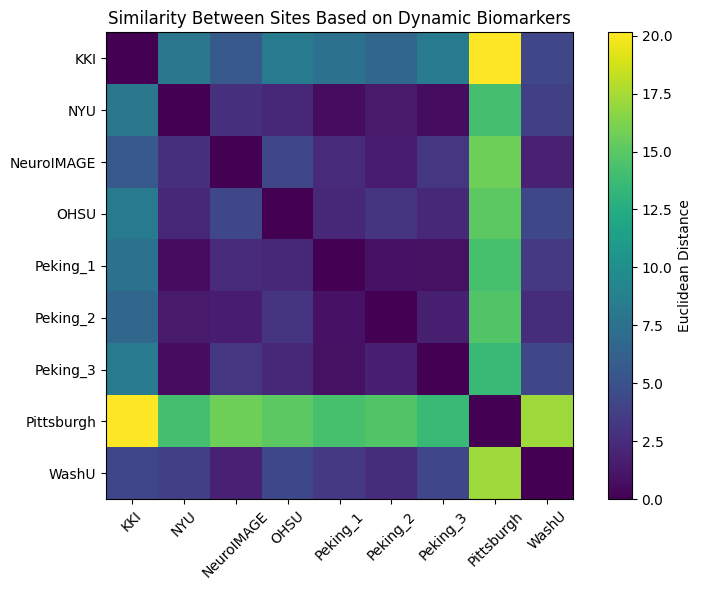

In [311]:
plt.figure(figsize=(8,6))
plt.imshow(
    distance_matrix,
    cmap="viridis"
)
plt.colorbar(label="Euclidean Distance")
plt.xticks(
    range(len(distance_matrix)),
    distance_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(distance_matrix)),
    distance_matrix.index
)
plt.title("Similarity Between Sites Based on Dynamic Biomarkers")
plt.tight_layout()
plt.show()

Scan Length vs Dynamic Biomarkers

In [312]:
site_summary = (
    subject_dataset
    .groupby("site")
    .agg({
        "occupancy_state0":"mean",
        "occupancy_state1":"mean",
        "occupancy_state2":"mean",
        "switching_rate":"mean",
        "transition_entropy":"mean"
    })
)
site_summary["mean_windows"] = (
    run_sequences
    .groupby("site")["n_windows"]
    .mean()
)
display(site_summary.round(3))

,occupancy_state0,occupancy_state1,occupancy_state2,switching_rate,transition_entropy,mean_windows
site,,,,,,
KKI,0.855,0.005,0.140,0.090,0.297,20.747
NYU,0.474,0.242,0.285,0.254,0.853,29.000
NeuroIMAGE,0.545,0.220,0.235,0.226,0.892,46.000
OHSU,0.592,0.148,0.260,0.187,0.376,8.987
Peking_1,0.514,0.243,0.242,0.257,0.950,41.000
Peking_2,0.455,0.280,0.265,0.262,0.919,41.000
Peking_3,0.372,0.347,0.281,0.288,0.985,41.000
Pittsburgh,0.000,0.864,0.136,0.100,0.434,33.000
WashU,0.688,0.071,0.242,0.151,0.465,18.228


Correlation With Scan Length

In [313]:
correlations = []
for feature in [
    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",
    "switching_rate",
    "transition_entropy"
]:
    r = site_summary["mean_windows"].corr(
        site_summary[feature]
    )
    correlations.append([
        feature,
        r
    ])
correlations = pd.DataFrame(
    correlations,
    columns=[
        "Feature",
        "Correlation with Scan Length"
    ]
)

display(correlations.round(3))

,Feature,Correlation with Scan Length
0,occupancy_state0,-0.417
1,occupancy_state1,0.362
2,occupancy_state2,0.154
3,switching_rate,0.564
4,transition_entropy,0.829


## H. Subject-Level Relationship Between Scan Length and Dynamic Biomarkers

The previous analysis demonstrated that sites differ substantially in average scan duration. Since dynamic biomarkers such as transition entropy and switching rate are computed from temporal state sequences, they may be influenced by the number of available windows.

To determine whether scan duration contributes to the observed site differences, we investigate the relationship between scan length and dynamic biomarkers at the subject level.

The following analyses are performed:

- Distribution of scan lengths
- Pearson and Spearman correlations
- Scatter plots with regression lines
- Partial interpretation of scan-length dependence

This analysis helps distinguish biological variability from methodological bias.

Add scan length to subject dataset

In [314]:
scan_lengths = (
    run_sequences
    .groupby("subject_id")["n_windows"]
    .mean()
    .reset_index()
    .rename(columns={"n_windows":"mean_windows"})
)

subject_dataset = subject_dataset.merge(
    scan_lengths,
    on="subject_id",
    how="left"
)

display(subject_dataset[[
    "subject_id",
    "mean_windows",
    "switching_rate",
    "transition_entropy"
]].head())

,subject_id,mean_windows,switching_rate,transition_entropy
0,10001,29.0,0.285714,1.009055
1,10002,29.0,0.303571,0.615102
2,10003,29.0,0.142857,0.390016
3,10004,29.0,0.303571,1.096601
4,10005,29.0,0.142857,0.832383


In [315]:
print("="*70)
print("Subject-Level Scan Length")
print("="*70)

display(subject_dataset["mean_windows"].describe())

Subject-Level Scan Length


count    764.000000
mean      29.880890
std       10.634039
min        8.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       46.000000
Name: mean_windows, dtype: float64

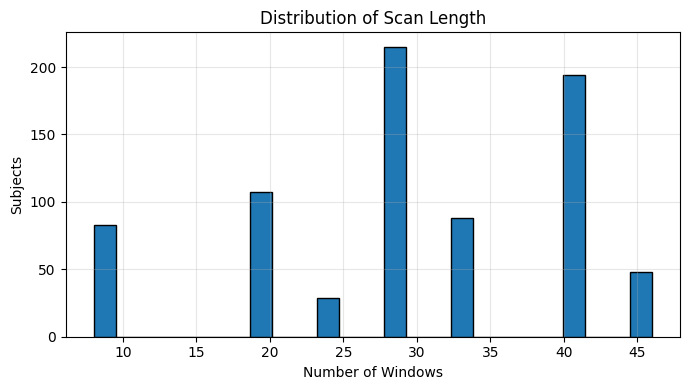

In [316]:
plt.figure(figsize=(7,4))

plt.hist(
    subject_dataset["mean_windows"],
    bins=25,
    edgecolor="black"
)

plt.xlabel("Number of Windows")
plt.ylabel("Subjects")
plt.title("Distribution of Scan Length")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Pearson correlations

In [317]:
from scipy.stats import pearsonr
features=[
    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",
    "switching_rate",
    "transition_entropy"
]
rows=[]
for feature in features:
    r,p=pearsonr(
        subject_dataset["mean_windows"],
        subject_dataset[feature]
    )
    rows.append([
        feature,
        r,
        p
    ])
corr_df=pd.DataFrame(
    rows,
    columns=[
        "Feature",
        "Pearson r",
        "P Value"
    ]
)

display(corr_df)

,Feature,Pearson r,P Value
0,occupancy_state0,-0.288653,3.974206e-16
1,occupancy_state1,0.300389,2.137562e-17
2,occupancy_state2,0.032064,3.761316e-01
3,switching_rate,0.273133,1.544985e-14
4,transition_entropy,0.525423,1.920108e-55


Spearman correlations

In [318]:
from scipy.stats import spearmanr
rows=[]
for feature in features:
    r,p=spearmanr(
        subject_dataset["mean_windows"],
        subject_dataset[feature]
    )
    rows.append([
        feature,
        r,
        p
    ])
spearman_df=pd.DataFrame(
    rows,
    columns=[
        "Feature",
        "Spearman rho",
        "P Value"
    ]
)

display(spearman_df)

,Feature,Spearman rho,P Value
0,occupancy_state0,-0.332907,3.146054e-21
1,occupancy_state1,0.432095,4.237922e-36
2,occupancy_state2,0.037632,2.988801e-01
3,switching_rate,0.277294,5.923049e-15
4,transition_entropy,0.519821,4.177551e-54


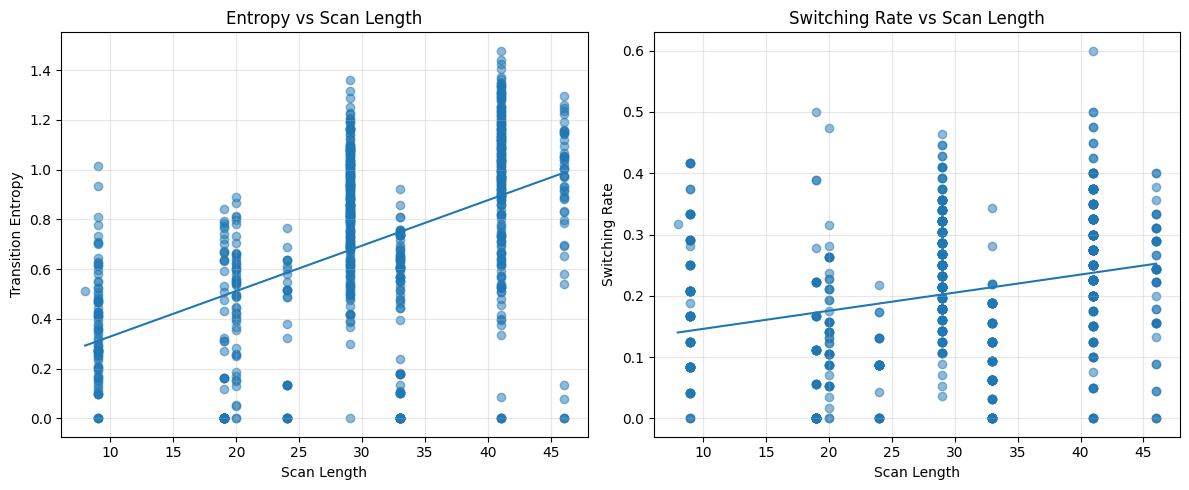

In [319]:
fig,axes=plt.subplots(1,2,figsize=(12,5))

axes[0].scatter(
    subject_dataset["mean_windows"],
    subject_dataset["transition_entropy"],
    alpha=0.5
)

m,b=np.polyfit(
    subject_dataset["mean_windows"],
    subject_dataset["transition_entropy"],
    1
)

x=np.linspace(
    subject_dataset["mean_windows"].min(),
    subject_dataset["mean_windows"].max(),
    100
)
axes[0].plot(x,m*x+b)
axes[0].set_xlabel("Scan Length")
axes[0].set_ylabel("Transition Entropy")
axes[0].set_title("Entropy vs Scan Length")
axes[0].grid(alpha=0.3)
axes[1].scatter(
    subject_dataset["mean_windows"],
    subject_dataset["switching_rate"],
    alpha=0.5
)
m,b=np.polyfit(
    subject_dataset["mean_windows"],
    subject_dataset["switching_rate"],
    1
)

axes[1].plot(x,m*x+b)

axes[1].set_xlabel("Scan Length")
axes[1].set_ylabel("Switching Rate")
axes[1].set_title("Switching Rate vs Scan Length")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [323]:
import statsmodels.api as sm

X_reg = pd.get_dummies(
    subject_dataset[["mean_windows", "site"]],
    columns=["site"],
    drop_first=True,
    dtype=float
)

X_reg = sm.add_constant(X_reg)

y_entropy = subject_dataset["transition_entropy"]

entropy_model = sm.OLS(
    y_entropy,
    X_reg
).fit()

print(entropy_model.summary())

                            OLS Regression Results                            
Dep. Variable:     transition_entropy   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     77.25
Date:                Tue, 14 Jul 2026   Prob (F-statistic):          7.35e-101
Time:                        05:14:12   Log-Likelihood:                -74.208
No. Observations:                 764   AIC:                             168.4
Df Residuals:                     754   BIC:                             214.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0299      0.186     

In [324]:
y_switch = subject_dataset["switching_rate"]
switch_model = sm.OLS(
    y_switch,
    X_reg
).fit()

print(switch_model.summary())

                            OLS Regression Results                            
Dep. Variable:         switching_rate   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     45.15
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           6.24e-65
Time:                        05:14:30   Log-Likelihood:                 732.84
No. Observations:                 764   AIC:                            -1446.
Df Residuals:                     754   BIC:                            -1399.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.1583      0.065     

In [330]:
combat_df_h.to_parquet(
    OUTPUT_DIR/"subject_graph_features_combat.parquet",
    index=False
)
print("Saved successfully.")

Saved successfully.


In [ ]:
subject_dataset.filter(like="_combat").columns.tolist()

# Phase E — Harmonization Validation

The graph features have now been harmonized using ComBat. This section validates
that harmonization successfully reduces site-specific variation while preserving
ADHD-related biological information.

The following analyses are performed:

- Dataset integrity
- Metadata integrity
- Feature distribution comparison
- PCA visualization
- UMAP visualization
- t-SNE visualization
- Site classification (Random Forest)
- ADHD classification (Random Forest)

In [359]:
print("=" * 80)
print("E1 DATASET INTEGRITY VALIDATION")
print("=" * 80)

metadata_cols = [
    "subject_id",
    "site",
    "Age",
    "Gender",
    "Handedness",
    "label",
    "label_binary"
]

combat_feature_cols = [
    col for col in combat_df_h.columns
    if col.endswith("_combat")
]

print(f"Subjects              : {combat_df_h['subject_id'].nunique()}")
print(f"Rows                  : {len(combat_df_h)}")
print(f"Sites                 : {combat_df_h['site'].nunique()}")
print(f"Diagnosis Classes     : {combat_df_h['label'].nunique()}")

print("\nDiagnosis Distribution")
print(combat_df_h["label"].value_counts())

print(f"\nMetadata Columns      : {len(metadata_cols)}")
print(f"ComBat Graph Features : {len(combat_feature_cols)}")

print("\nMissing Values")
print(combat_df_h.isna().sum().sum())

print("\nDuplicate Subjects")
print(combat_df_h["subject_id"].duplicated().sum())

print("\nInfinite Values")
print(np.isinf(combat_df_h[combat_feature_cols]).sum().sum())

print("\nFeature Matrix Shape")
print(combat_df_h[combat_feature_cols].shape)

E1 DATASET INTEGRITY VALIDATION
Subjects              : 764
Rows                  : 764
Sites                 : 9
Diagnosis Classes     : 4

Diagnosis Distribution
label
0    484
1    159
3    110
2     11
Name: count, dtype: int64

Metadata Columns      : 7
ComBat Graph Features : 13

Missing Values
0

Duplicate Subjects
0

Infinite Values
0

Feature Matrix Shape
(764, 13)


In [360]:
print("E2 DISTRIBUTION VALIDATION")

representative_features = [
    "avg_strength",
    "clustering",
    "efficiency_global",
    "path_length",
    "gamma",
    "lambda",
    "sigma"
]

combat_features = [
    f"{feature}_combat"
    for feature in representative_features
]

print("Representative Features\n")

for raw, combat in zip(representative_features, combat_features):
    print(f"{raw:25s} --> {combat}")

E2 DISTRIBUTION VALIDATION
Representative Features

avg_strength              --> avg_strength_combat
clustering                --> clustering_combat
efficiency_global         --> efficiency_global_combat
path_length               --> path_length_combat
gamma                     --> gamma_combat
lambda                    --> lambda_combat
sigma                     --> sigma_combat


E2.2 Summary Statistics

In [361]:
summary_stats = []

for raw, combat in zip(representative_features, combat_features):

    summary_stats.append({

        "Feature": raw,

        "Raw Mean": combat_df_h[raw].mean(),
        "Raw Std": combat_df_h[raw].std(),

        "ComBat Mean": combat_df_h[combat].mean(),
        "ComBat Std": combat_df_h[combat].std()
    })

summary_stats = pd.DataFrame(summary_stats)

display(summary_stats.round(4))

,Feature,Raw Mean,Raw Std,ComBat Mean,ComBat Std
0,avg_strength,25.1406,1.4237,25.1508,0.9494
1,clustering,0.3333,0.0343,0.3334,0.0275
2,efficiency_global,0.5820,0.0091,0.5821,0.0084
3,path_length,0.5683,0.0580,0.5682,0.0299
4,gamma,1.0320,0.0028,1.0320,0.0022
5,lambda,1.0187,0.0044,1.0187,0.0042
6,sigma,1.0132,0.0047,1.0132,0.0039


E2.3 Histograms

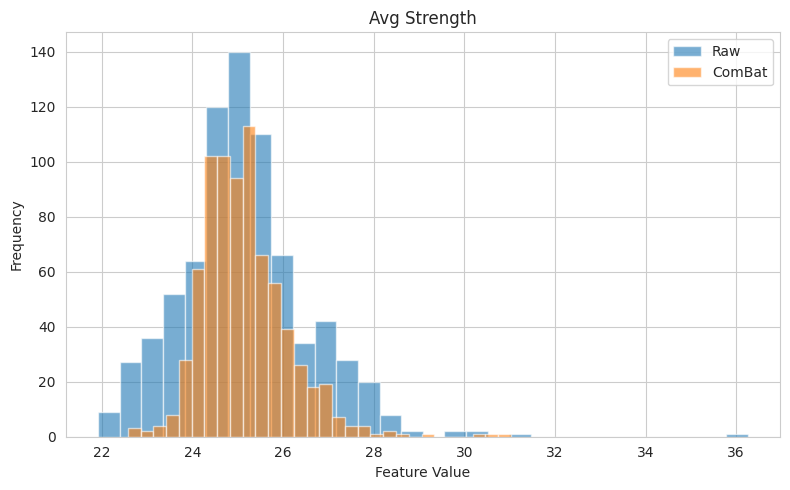

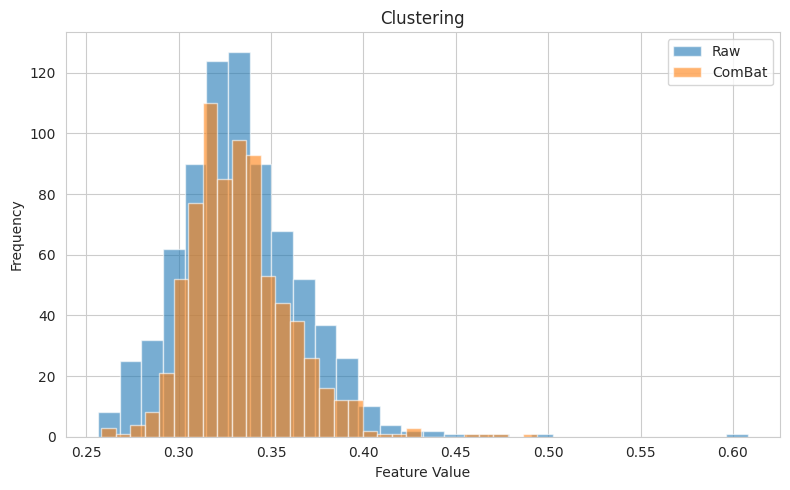

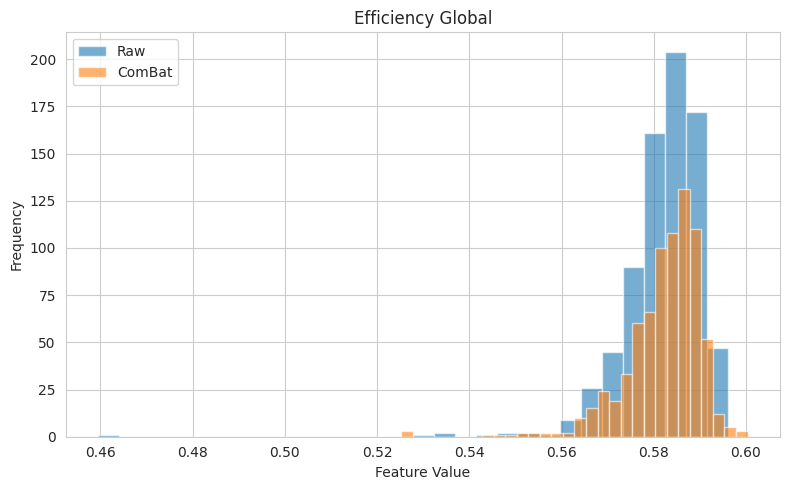

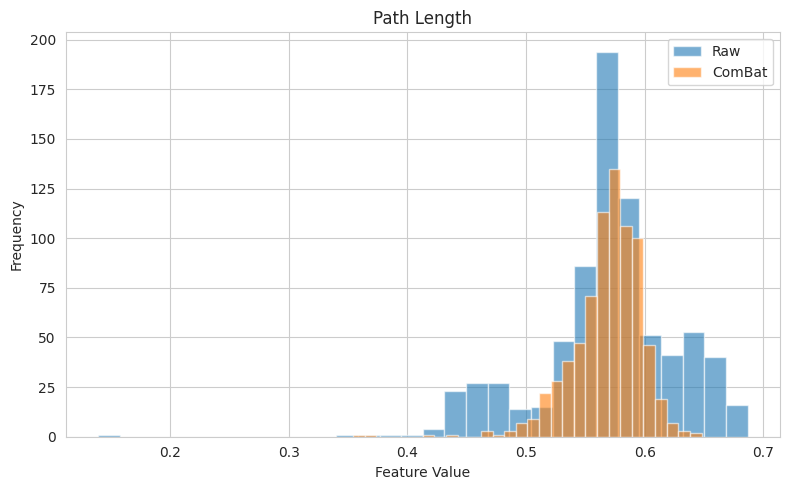

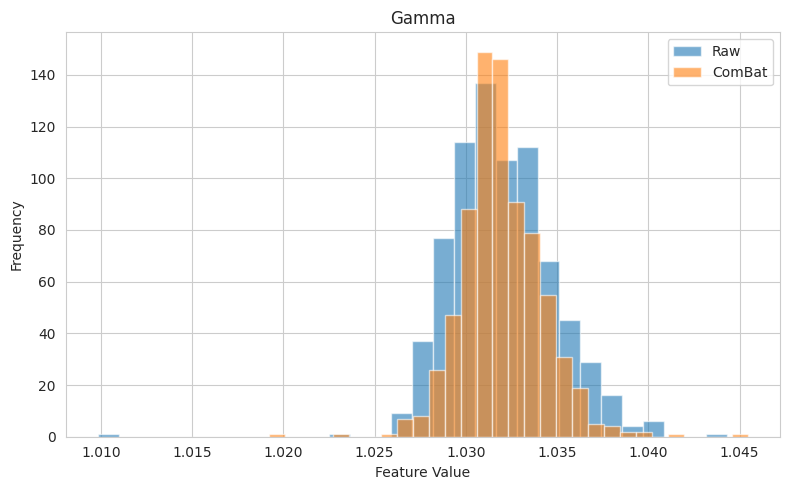

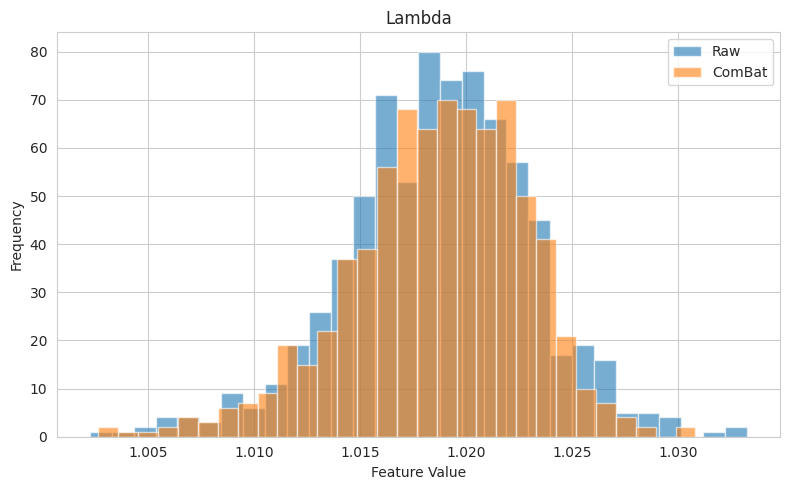

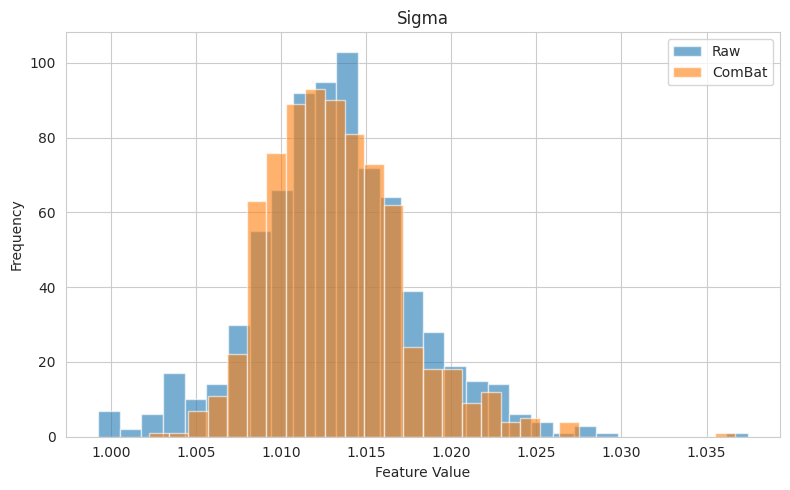

In [363]:
import matplotlib.pyplot as plt

for raw, combat in zip(representative_features, combat_features):

    plt.figure(figsize=(8,5))

    plt.hist(
        combat_df_h[raw],
        bins=30,
        alpha=0.6,
        label="Raw"
    )

    plt.hist(
        combat_df_h[combat],
        bins=30,
        alpha=0.6,
        label="ComBat"
    )

    plt.title(raw.replace("_"," ").title())

    plt.xlabel("Feature Value")
    plt.ylabel("Frequency")

    plt.legend()

    plt.tight_layout()
    plt.show()

KDE Comparison

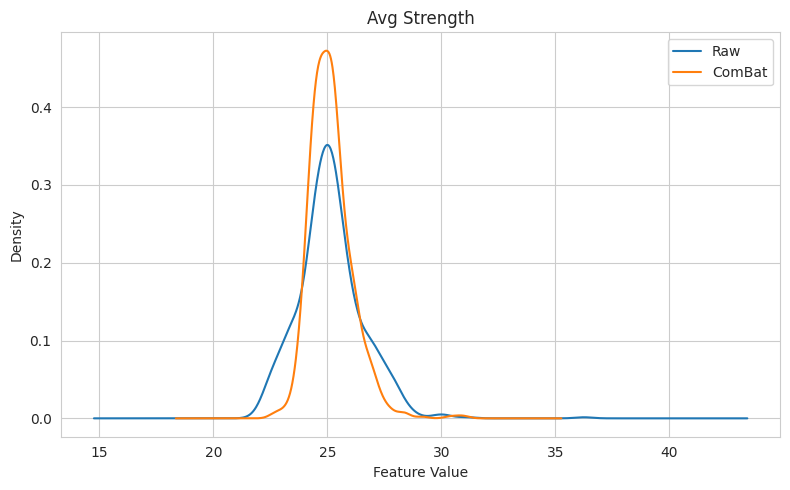

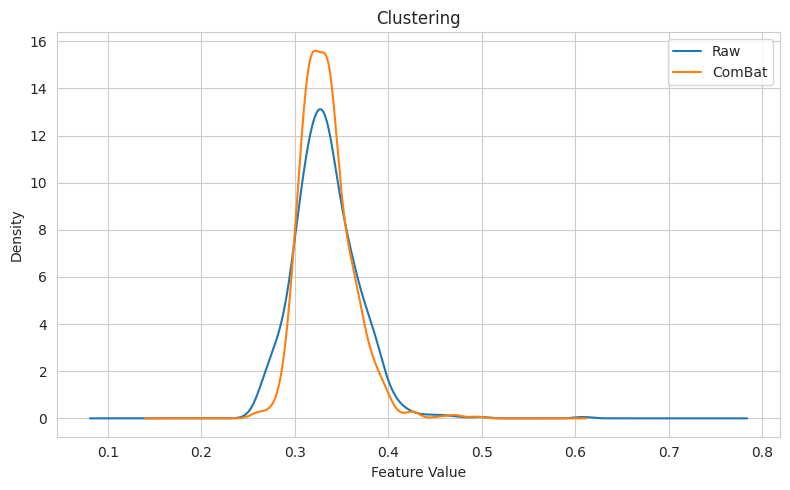

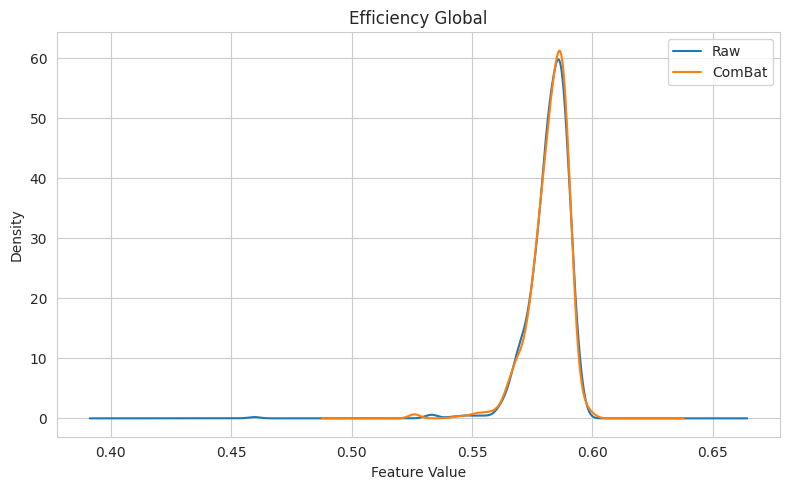

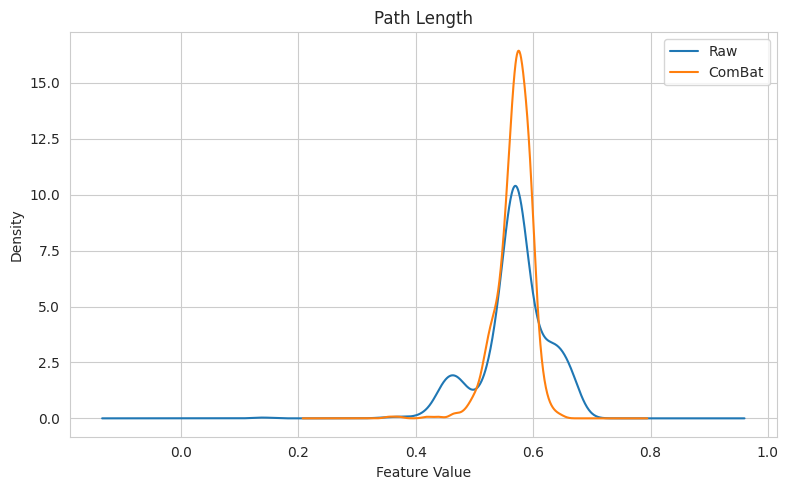

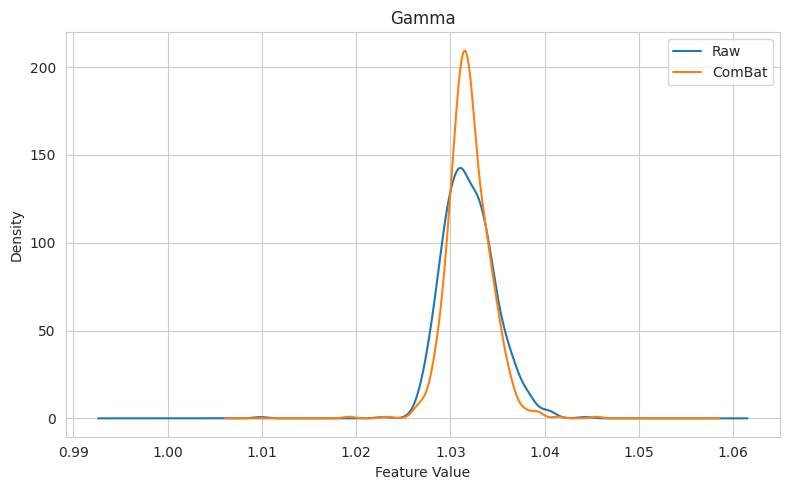

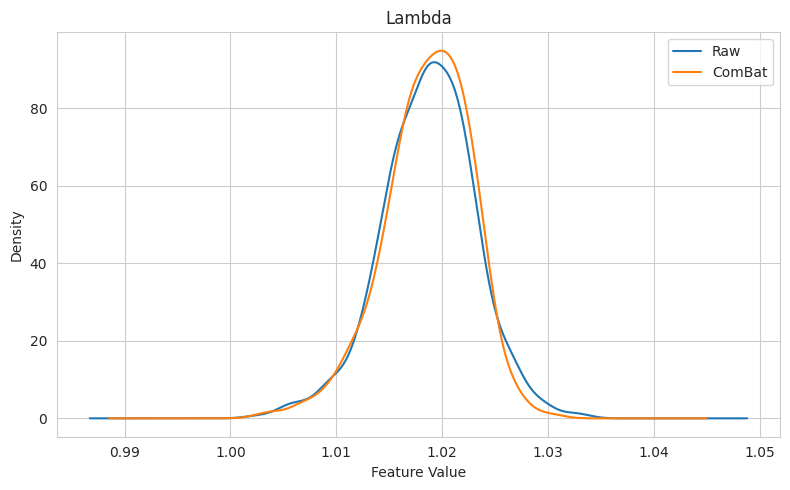

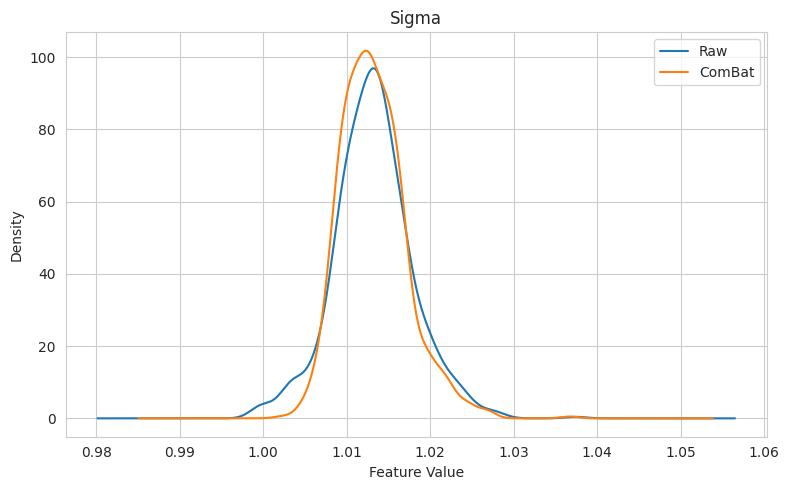

In [364]:
for raw, combat in zip(representative_features, combat_features):

    plt.figure(figsize=(8,5))

    combat_df_h[raw].plot(
        kind="density",
        label="Raw"
    )

    combat_df_h[combat].plot(
        kind="density",
        label="ComBat"
    )

    plt.title(raw.replace("_"," ").title())

    plt.xlabel("Feature Value")

    plt.legend()

    plt.tight_layout()

    plt.show()

E2.5 Boxplots

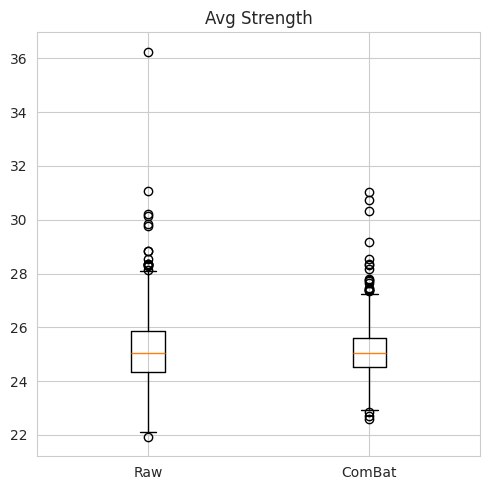

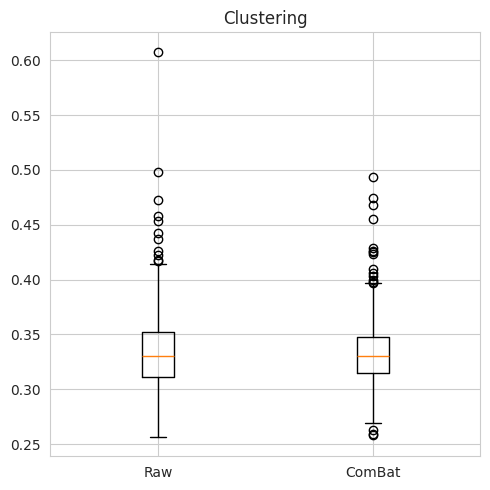

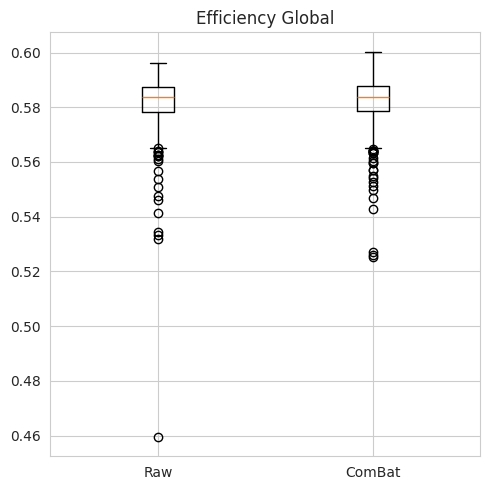

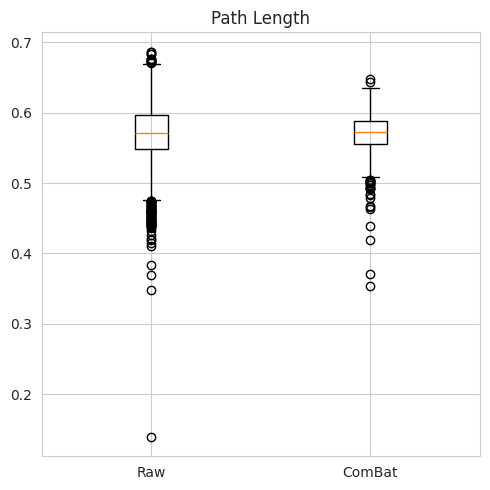

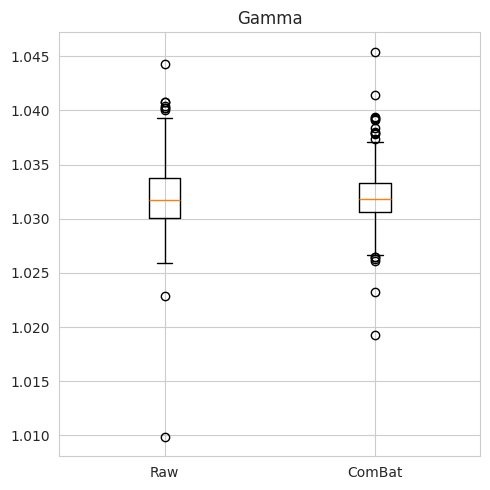

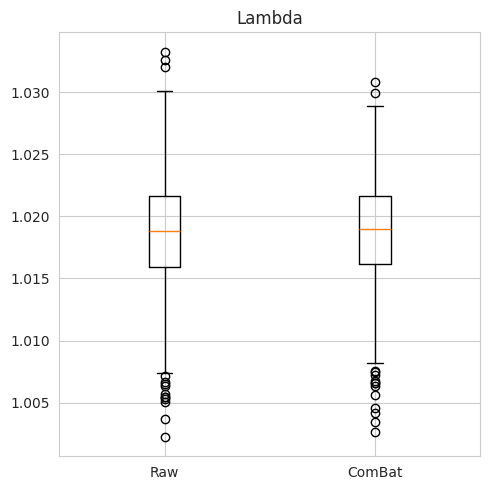

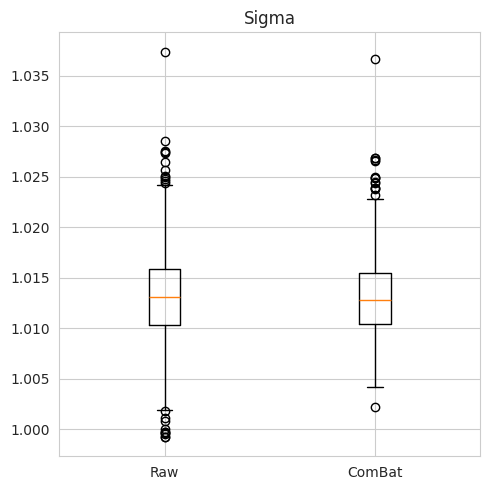

In [365]:
for raw, combat in zip(representative_features, combat_features):

    plt.figure(figsize=(5,5))

    plt.boxplot([
        combat_df_h[raw],
        combat_df_h[combat]
    ])

    plt.xticks(
        [1,2],
        ["Raw","ComBat"]
    )

    plt.title(raw.replace("_"," ").title())

    plt.tight_layout()

    plt.show()

E3 SITE EFFECT VALIDATION

For each representative graph metric, the following quantities are computed

• Site-wise Mean
• Site-wise Variance
• Between-site Variance
• Coefficient of Variation
• Kruskal–Wallis H Statistic
• p-value
• Eta Squared (η²)

E3.1 Site-wise Summary Statistics

In [366]:
print("E3 SITE-WISE FEATURE STATISTICS")

site_summary = []

for raw, combat in zip(representative_features, combat_features):

    for site in sorted(combat_df_h["site"].unique()):

        raw_values = combat_df_h.loc[
            combat_df_h["site"] == site,
            raw
        ]

        combat_values = combat_df_h.loc[
            combat_df_h["site"] == site,
            combat
        ]

        site_summary.append({

            "Feature": raw,

            "Site": site,

            "Raw Mean": raw_values.mean(),
            "Raw Variance": raw_values.var(),

            "ComBat Mean": combat_values.mean(),
            "ComBat Variance": combat_values.var()
        })

site_summary = pd.DataFrame(site_summary)

display(site_summary.head())

E3 SITE-WISE FEATURE STATISTICS


,Feature,Site,Raw Mean,Raw Variance,ComBat Mean,ComBat Variance
0,avg_strength,KKI,23.236840,0.539276,25.147325,0.846443
1,avg_strength,NYU,25.253639,0.706601,25.191675,0.914707
2,avg_strength,NeuroIMAGE,25.207267,3.487202,25.167530,0.991180
3,avg_strength,OHSU,24.679241,1.250257,25.192475,0.954146
4,avg_strength,Peking_1,25.112382,0.543281,25.157994,0.878573


E3.2 Between-site Variance

In [367]:
between_site = []

for raw, combat in zip(representative_features, combat_features):

    raw_site_means = combat_df_h.groupby("site")[raw].mean()

    combat_site_means = combat_df_h.groupby("site")[combat].mean()

    between_site.append({

        "Feature": raw,

        "Raw Between-site Variance":
            raw_site_means.var(),

        "ComBat Between-site Variance":
            combat_site_means.var()
    })

between_site = pd.DataFrame(between_site)

display(between_site.round(4))

,Feature,Raw Between-site Variance,ComBat Between-site Variance
0,avg_strength,1.2852,0.003
1,clustering,0.0005,0.000
2,efficiency_global,0.0000,0.000
3,path_length,0.0028,0.000
4,gamma,0.0000,0.000
5,lambda,0.0000,0.000
6,sigma,0.0000,0.000


E3.3 Coefficient of Variation

In [368]:
cv_results = []

for raw, combat in zip(representative_features, combat_features):

    raw_cv = (
        combat_df_h.groupby("site")[raw].std() /
        combat_df_h.groupby("site")[raw].mean()
    ).mean()

    combat_cv = (
        combat_df_h.groupby("site")[combat].std() /
        combat_df_h.groupby("site")[combat].mean()
    ).mean()

    cv_results.append({

        "Feature": raw,

        "Raw CV": raw_cv,

        "ComBat CV": combat_cv

    })

cv_results = pd.DataFrame(cv_results)

display(cv_results.round(4))

,Feature,Raw CV,ComBat CV
0,avg_strength,0.0388,0.0379
1,clustering,0.0850,0.0831
2,efficiency_global,0.0146,0.0144
3,path_length,0.0538,0.0526
4,gamma,0.0022,0.0021
5,lambda,0.0041,0.0041
6,sigma,0.0038,0.0038


E3.4 Kruskal–Wallis Test

In [369]:
from scipy.stats import kruskal

kw_results = []

for raw, combat in zip(representative_features, combat_features):

    raw_groups = [
        group[raw].values
        for _, group in combat_df_h.groupby("site")
    ]

    combat_groups = [
        group[combat].values
        for _, group in combat_df_h.groupby("site")
    ]

    H_raw, p_raw = kruskal(*raw_groups)

    H_combat, p_combat = kruskal(*combat_groups)

    kw_results.append({

        "Feature": raw,

        "Raw H": H_raw,
        "Raw p": p_raw,

        "ComBat H": H_combat,
        "ComBat p": p_combat

    })

kw_results = pd.DataFrame(kw_results)

display(kw_results.round(4))

,Feature,Raw H,Raw p,ComBat H,ComBat p
0,avg_strength,405.4457,0.0,4.0367,0.8538
1,clustering,287.6203,0.0,3.0903,0.9286
2,efficiency_global,138.9414,0.0,3.3204,0.9127
3,path_length,488.1227,0.0,8.8290,0.3569
4,gamma,327.6275,0.0,16.5335,0.0354
5,lambda,91.0057,0.0,6.4658,0.5952
6,sigma,206.0037,0.0,1.9312,0.9830


E3.5 Effect Size (η²)

In [371]:
eta_results = []
N = len(combat_df_h)
k = combat_df_h["site"].nunique()
eta = (H - k + 1) / (N - k)

for _, row in kw_results.iterrows():

    eta_raw = (row["Raw H"] - eta + 1) / (N - eta)

    eta_combat = (row["ComBat H"] - eta + 1) / (N - eta)

    eta_results.append({

        "Feature": row["Feature"],

        "Eta Raw": max(0, eta_raw),

        "Eta ComBat": max(0, eta_combat)

    })

eta_results = pd.DataFrame(eta_results)

display(eta_results.round(4))

,Feature,Eta Raw,Eta ComBat
0,avg_strength,0.5310,0.0046
1,clustering,0.3765,0.0033
2,efficiency_global,0.1815,0.0036
3,path_length,0.6395,0.0109
4,gamma,0.4290,0.0210
5,lambda,0.1186,0.0078
6,sigma,0.2695,0.0018


E3.6 Summary Comparison Table

In [372]:
effect_summary = (
    kw_results.merge(
        eta_results,
        on="Feature"
    )
)

display(effect_summary.round(4))

effect_summary.to_csv(
    "effect_size_before_after.csv",
    index=False
)

,Feature,Raw H,Raw p,ComBat H,ComBat p,Eta Raw,Eta ComBat
0,avg_strength,405.4457,0.0,4.0367,0.8538,0.5310,0.0046
1,clustering,287.6203,0.0,3.0903,0.9286,0.3765,0.0033
2,efficiency_global,138.9414,0.0,3.3204,0.9127,0.1815,0.0036
3,path_length,488.1227,0.0,8.8290,0.3569,0.6395,0.0109
4,gamma,327.6275,0.0,16.5335,0.0354,0.4290,0.0210
5,lambda,91.0057,0.0,6.4658,0.5952,0.1186,0.0078
6,sigma,206.0037,0.0,1.9312,0.9830,0.2695,0.0018


E4 DIMENSIONALITY VALIDATION

Visualize the graph-feature space before and after ComBat harmonization using
multiple dimensionality reduction techniques.
    
Three complementary techniques are employed

• Principal Component Analysis (PCA)
• Uniform Manifold Approximation and Projection (UMAP)
• t-distributed Stochastic Neighbor Embedding (t-SNE)

Each visualization is generated twice

• Colour by Acquisition Site
• Colour by Diagnosis

Expected observations
Before harmonization

• Samples cluster primarily according to acquisition site.

After harmonization

• Site-specific clusters become less distinct.
• Disease-related structure is preserved.

E4.1 Feature Matrix Preparation

In [373]:
print("E4 DIMENSIONALITY VALIDATION")

raw_features = representative_features
combat_features = [f"{f}_combat" for f in representative_features]

X_raw = combat_df_h[raw_features]

X_combat = combat_df_h[combat_features]

site_labels = combat_df_h["site"]
diagnosis_labels = combat_df_h["label"]

print("Raw Feature Matrix :", X_raw.shape)
print("ComBat Feature Matrix :", X_combat.shape)

E4 DIMENSIONALITY VALIDATION
Raw Feature Matrix : (764, 7)
ComBat Feature Matrix : (764, 7)


E4.2 PCA Analysis

In [374]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

raw_pca = pca.fit_transform(X_raw)

combat_pca = pca.fit_transform(X_combat)

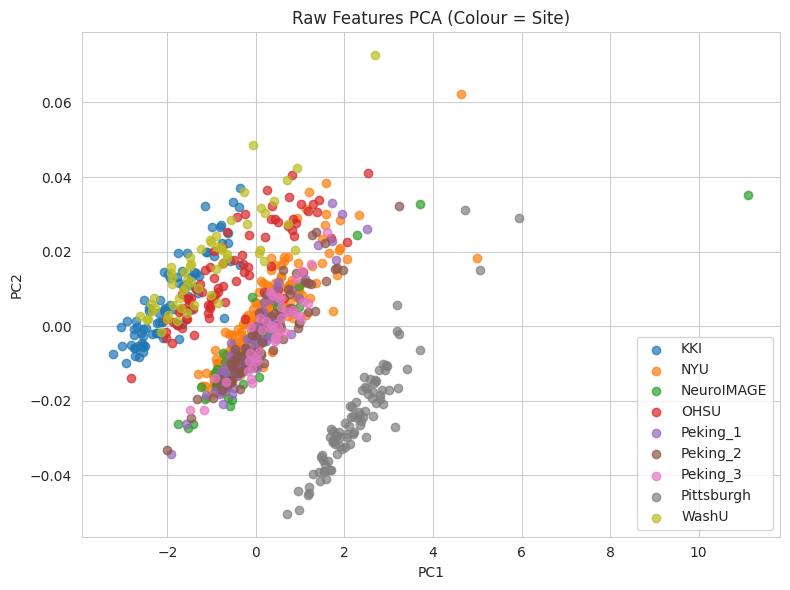

In [375]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for site in sorted(site_labels.unique()):

    idx = site_labels == site

    plt.scatter(
        raw_pca[idx,0],
        raw_pca[idx,1],
        label=site,
        alpha=0.7
    )

plt.title("Raw Features PCA (Colour = Site)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

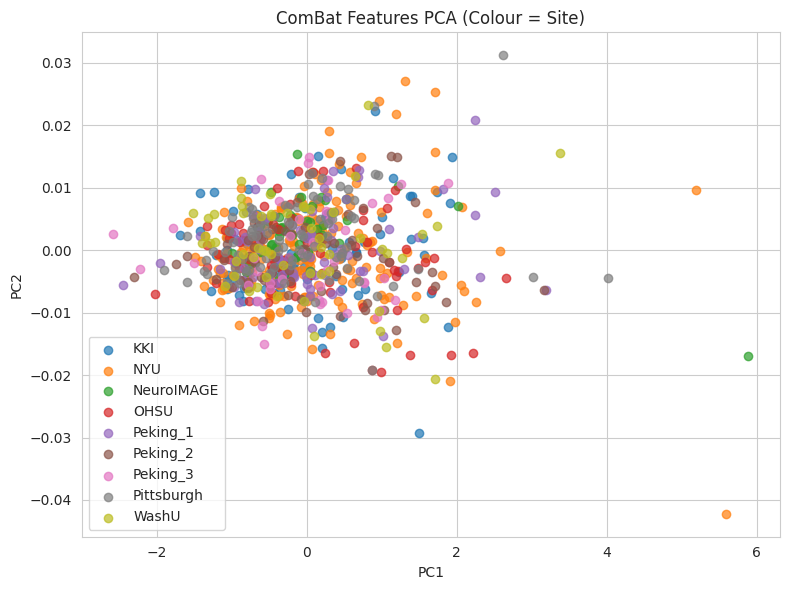

In [376]:
plt.figure(figsize=(8,6))

for site in sorted(site_labels.unique()):

    idx = site_labels == site

    plt.scatter(
        combat_pca[idx,0],
        combat_pca[idx,1],
        label=site,
        alpha=0.7
    )

plt.title("ComBat Features PCA (Colour = Site)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

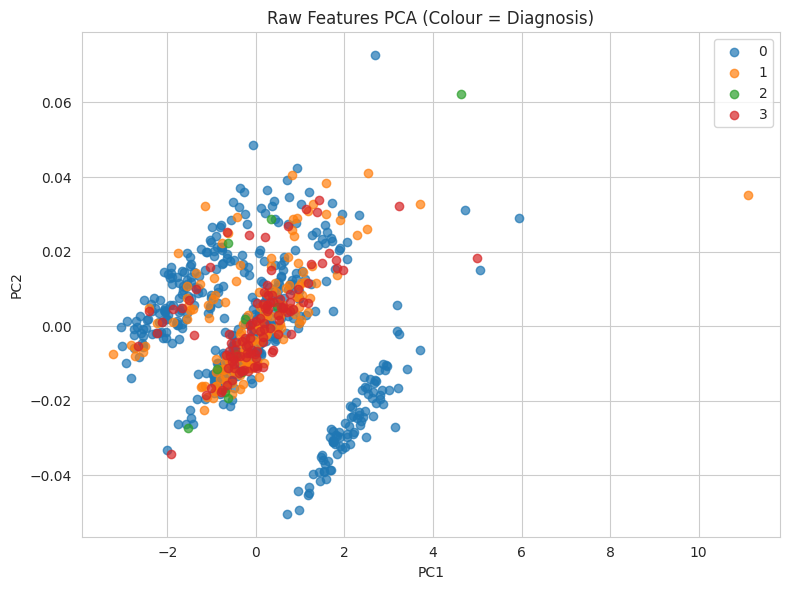

In [377]:
plt.figure(figsize=(8,6))

for label in sorted(diagnosis_labels.unique()):

    idx = diagnosis_labels == label

    plt.scatter(
        raw_pca[idx,0],
        raw_pca[idx,1],
        label=label,
        alpha=0.7
    )

plt.title("Raw Features PCA (Colour = Diagnosis)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

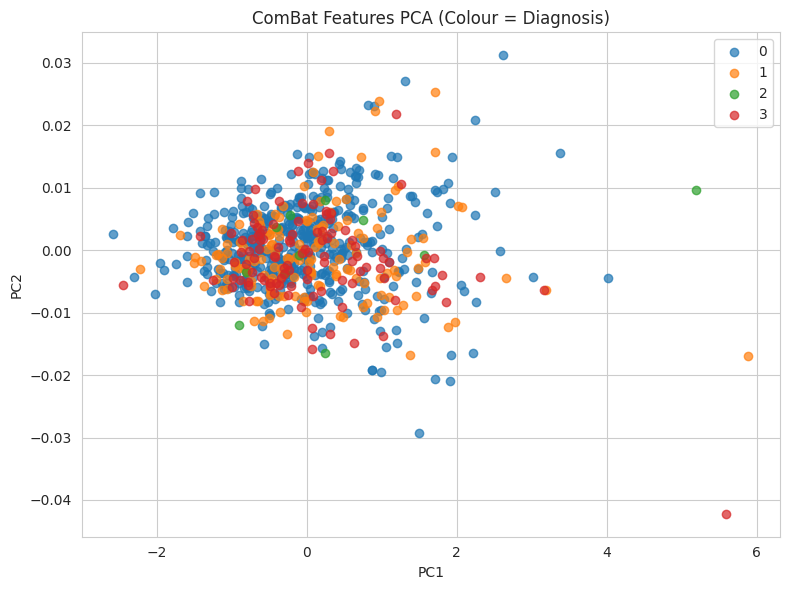

In [378]:
plt.figure(figsize=(8,6))

for label in sorted(diagnosis_labels.unique()):

    idx = diagnosis_labels == label

    plt.scatter(
        combat_pca[idx,0],
        combat_pca[idx,1],
        label=label,
        alpha=0.7
    )

plt.title("ComBat Features PCA (Colour = Diagnosis)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

E4.3 UMAP Analysis

In [379]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

raw_umap = reducer.fit_transform(X_raw)

combat_umap = reducer.fit_transform(X_combat)

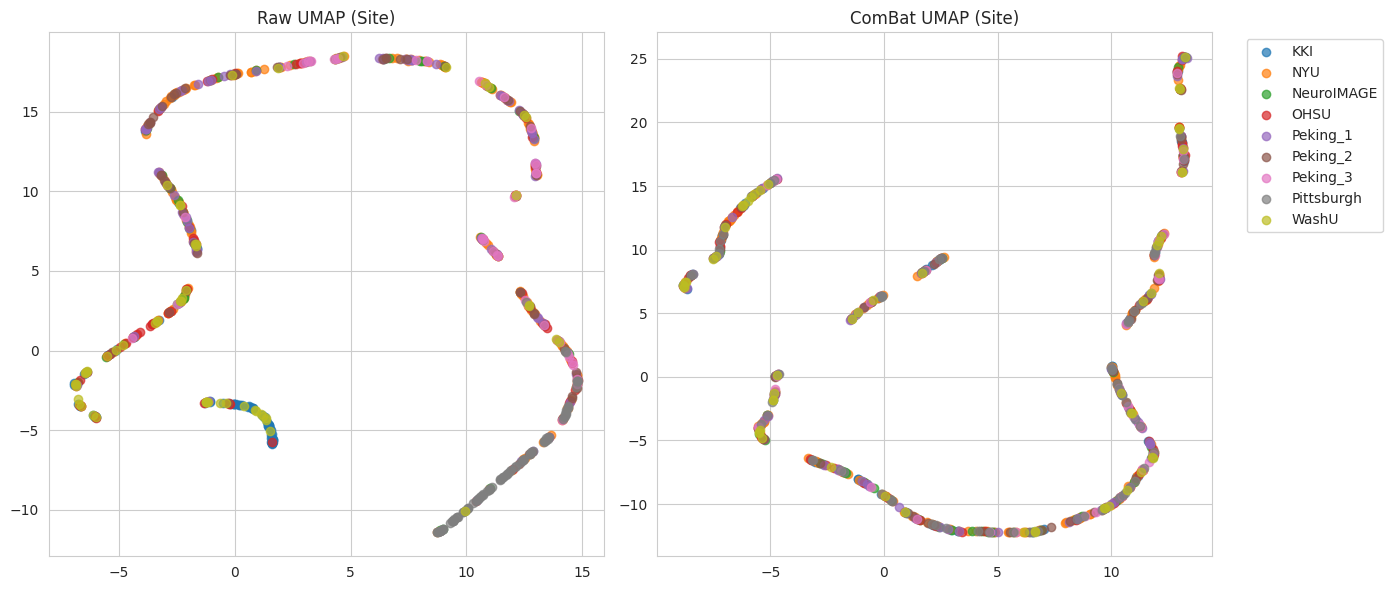

In [380]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

for site in sorted(site_labels.unique()):

    idx = site_labels == site

    axes[0].scatter(raw_umap[idx,0], raw_umap[idx,1], label=site, alpha=0.7)
    axes[1].scatter(combat_umap[idx,0], combat_umap[idx,1], label=site, alpha=0.7)

axes[0].set_title("Raw UMAP (Site)")
axes[1].set_title("ComBat UMAP (Site)")

axes[1].legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

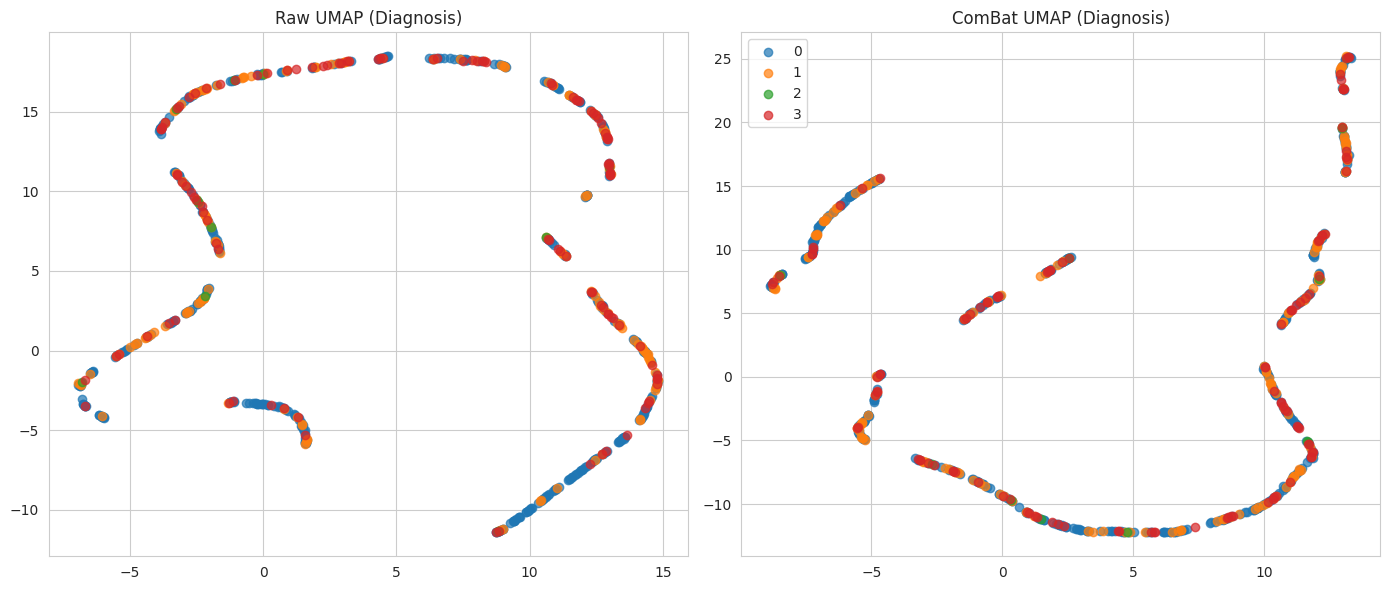

In [381]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

for label in sorted(diagnosis_labels.unique()):

    idx = diagnosis_labels == label

    axes[0].scatter(raw_umap[idx,0], raw_umap[idx,1], label=label, alpha=0.7)
    axes[1].scatter(combat_umap[idx,0], combat_umap[idx,1], label=label, alpha=0.7)

axes[0].set_title("Raw UMAP (Diagnosis)")
axes[1].set_title("ComBat UMAP (Diagnosis)")

axes[1].legend()
plt.tight_layout()
plt.show()

E4.4 t-SNE Analysis

In [383]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

raw_tsne = tsne.fit_transform(X_raw)

combat_tsne = tsne.fit_transform(X_combat)

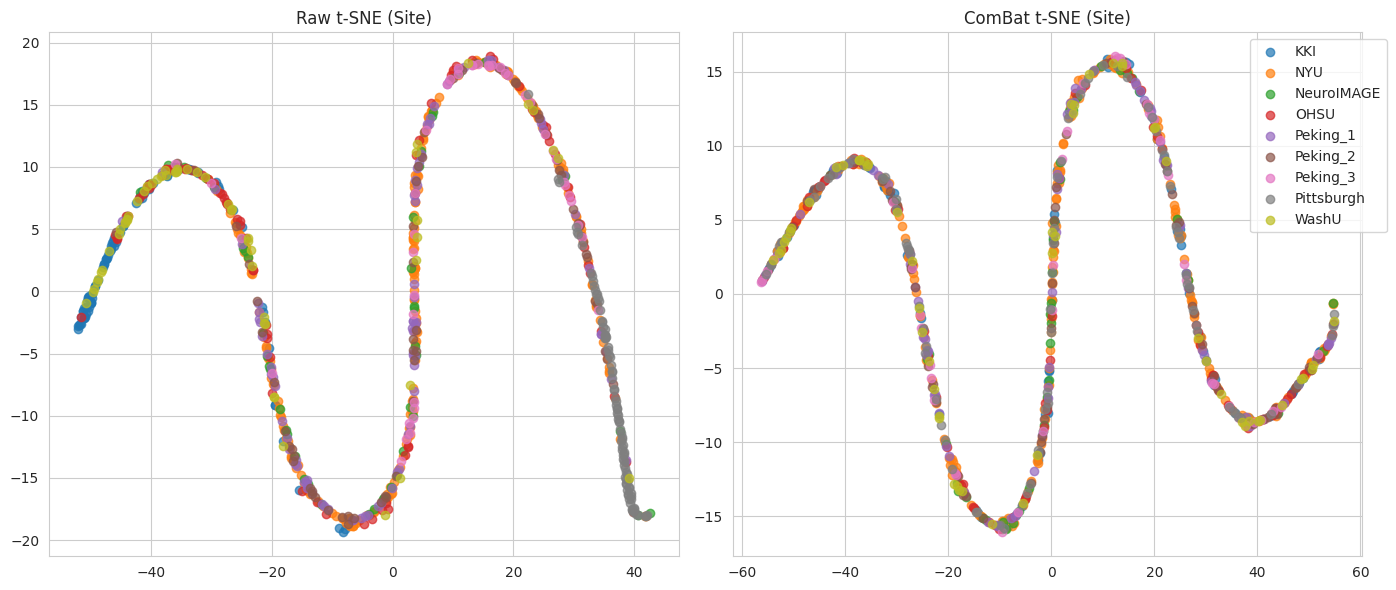

In [384]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

for site in sorted(site_labels.unique()):

    idx = site_labels == site

    axes[0].scatter(raw_tsne[idx,0], raw_tsne[idx,1], label=site, alpha=0.7)
    axes[1].scatter(combat_tsne[idx,0], combat_tsne[idx,1], label=site, alpha=0.7)

axes[0].set_title("Raw t-SNE (Site)")
axes[1].set_title("ComBat t-SNE (Site)")

axes[1].legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

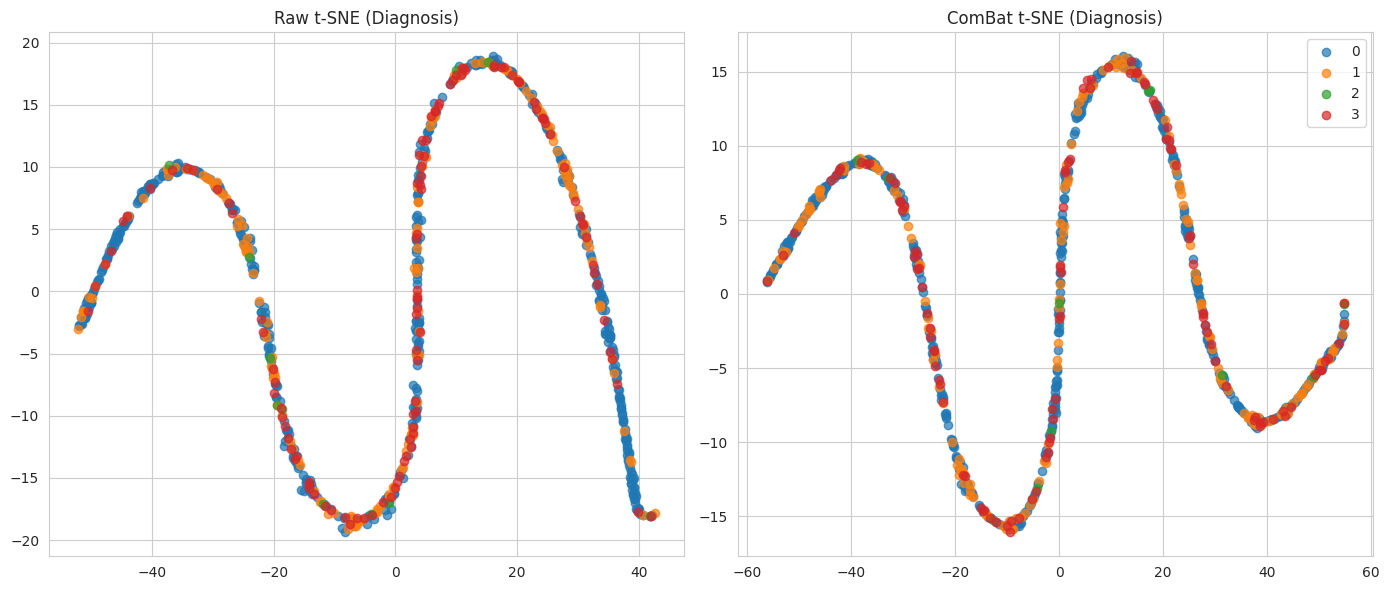

In [385]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

for label in sorted(diagnosis_labels.unique()):

    idx = diagnosis_labels == label

    axes[0].scatter(raw_tsne[idx,0], raw_tsne[idx,1], label=label, alpha=0.7)
    axes[1].scatter(combat_tsne[idx,0], combat_tsne[idx,1], label=label, alpha=0.7)

axes[0].set_title("Raw t-SNE (Diagnosis)")
axes[1].set_title("ComBat t-SNE (Diagnosis)")

axes[1].legend()
plt.tight_layout()
plt.show()

Evaluate the information content of the harmonized graph features.

Random Forest is used as an independent validation model rather than as the
final ADHD classifier.

Two prediction tasks are considered

• Acquisition Site Prediction

• ADHD Diagnosis Prediction

Successful harmonization should

• Reduce site prediction performance

• Preserve diagnosis prediction performance

E5.1 Feature Selection

In [386]:
print("E5 PREDICTABILITY VALIDATION")

raw_features = [
    "avg_strength",
    "clustering",
    "transitivity",
    "efficiency_global",
    "efficiency_local",
    "path_length",
    "null_clustering",
    "null_transitivity",
    "null_efficiency",
    "null_path_length",
    "gamma",
    "lambda",
    "sigma"
]

combat_features = [f"{f}_combat" for f in raw_features]

raw_available = all(col in combat_df_h.columns for col in raw_features)

print(f"Raw Features Available    : {raw_available}")
print(f"ComBat Features Available : {all(col in combat_df_h.columns for col in combat_features)}")

E5 PREDICTABILITY VALIDATION
Raw Features Available    : True
ComBat Features Available : True


In [387]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score

E5.3 Site Prediction

In [388]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro")
}

results = []

# -------------------------
# RAW FEATURES
# -------------------------
if raw_available:

    scores = cross_validate(
        rf,
        combat_df_h[raw_features],
        combat_df_h["site"],
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Dataset": "Raw",
        "Task": "Site",
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Macro F1": scores["test_f1_macro"].mean()
    })

# -------------------------
# COMBAT FEATURES
# -------------------------
scores = cross_validate(
    rf,
    combat_df_h[combat_features],
    combat_df_h["site"],
    cv=cv,
    scoring=scoring
)

results.append({
    "Dataset": "ComBat",
    "Task": "Site",
    "Accuracy": scores["test_accuracy"].mean(),
    "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
    "Macro F1": scores["test_f1_macro"].mean()
})

site_results = pd.DataFrame(results)

display(site_results.round(4))

,Dataset,Task,Accuracy,Balanced Accuracy,Macro F1
0,Raw,Site,0.5864,0.5019,0.5061
1,ComBat,Site,0.3129,0.2356,0.2437


E5.4 ADHD Prediction

In [389]:
results = []

if raw_available:

    scores = cross_validate(
        rf,
        combat_df_h[raw_features],
        combat_df_h["label_binary"],
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Dataset": "Raw",
        "Task": "Diagnosis",
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Macro F1": scores["test_f1_macro"].mean()
    })

scores = cross_validate(
    rf,
    combat_df_h[combat_features],
    combat_df_h["label_binary"],
    cv=cv,
    scoring=scoring
)

results.append({
    "Dataset": "ComBat",
    "Task": "Diagnosis",
    "Accuracy": scores["test_accuracy"].mean(),
    "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
    "Macro F1": scores["test_f1_macro"].mean()
})

diagnosis_results = pd.DataFrame(results)

display(diagnosis_results.round(4))

,Dataset,Task,Accuracy,Balanced Accuracy,Macro F1
0,Raw,Diagnosis,0.6453,0.5943,0.5953
1,ComBat,Diagnosis,0.5956,0.5160,0.4992


In [390]:
site_results.to_csv(
    "site_prediction_results.csv",
    index=False
)

diagnosis_results.to_csv(
    "diagnosis_prediction_results.csv",
    index=False
)

print("✓ Prediction results saved.")

✓ Prediction results saved.


E6 GRAPH TOPOLOGY PRESERVATION

This section compares representative graph-theoretical measures before and
after ComBat harmonization.

The following topology metrics are investigated

• Clustering Coefficient

• Global Efficiency

• Local Efficiency

• Characteristic Path Length

• Gamma

• Lambda

• Sigma

E6.1 Representative Topology Features

In [391]:
print("E6 GRAPH TOPOLOGY PRESERVATION")

topology_features = [
    "clustering",
    "efficiency_global",
    "efficiency_local",
    "path_length",
    "gamma",
    "lambda",
    "sigma"
]

combat_topology = [f"{f}_combat" for f in topology_features]

print("Representative Graph Metrics\n")

for raw, combat in zip(topology_features, combat_topology):
    print(f"{raw:25s} --> {combat}")

E6 GRAPH TOPOLOGY PRESERVATION
Representative Graph Metrics

clustering                --> clustering_combat
efficiency_global         --> efficiency_global_combat
efficiency_local          --> efficiency_local_combat
path_length               --> path_length_combat
gamma                     --> gamma_combat
lambda                    --> lambda_combat
sigma                     --> sigma_combat


E6.2 Summary Statistics

In [392]:
topology_summary = []

for raw, combat in zip(topology_features, combat_topology):

    topology_summary.append({

        "Metric": raw,

        "Raw Mean": combat_df_h[raw].mean(),
        "Raw Std": combat_df_h[raw].std(),

        "ComBat Mean": combat_df_h[combat].mean(),
        "ComBat Std": combat_df_h[combat].std(),

        "Mean Difference":
            combat_df_h[combat].mean() -
            combat_df_h[raw].mean()

    })

topology_summary = pd.DataFrame(topology_summary)

display(topology_summary.round(4))

,Metric,Raw Mean,Raw Std,ComBat Mean,ComBat Std,Mean Difference
0,clustering,0.3333,0.0343,0.3334,0.0275,0.0001
1,efficiency_global,0.5820,0.0091,0.5821,0.0084,0.0001
2,efficiency_local,0.7225,0.0116,0.7224,0.0092,-0.0000
3,path_length,0.5683,0.0580,0.5682,0.0299,-0.0002
4,gamma,1.0320,0.0028,1.0320,0.0022,-0.0000
5,lambda,1.0187,0.0044,1.0187,0.0042,-0.0000
6,sigma,1.0132,0.0047,1.0132,0.0039,0.0000


E6.3 Distribution Comparison

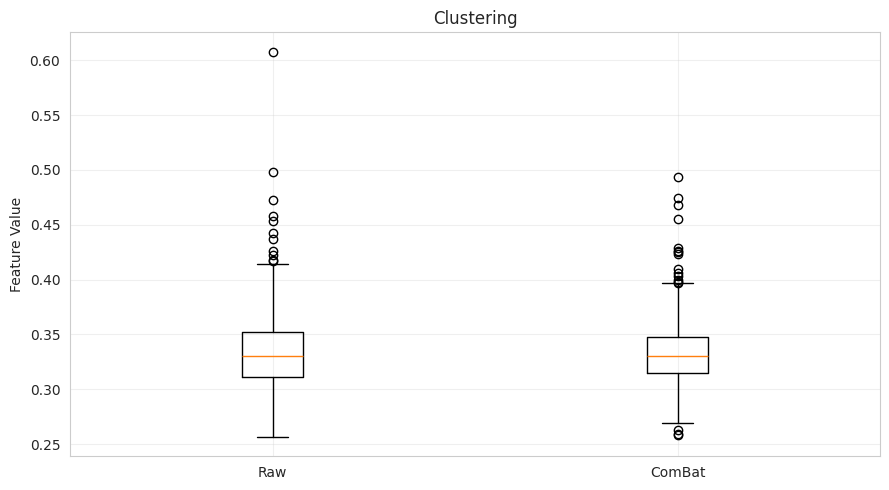

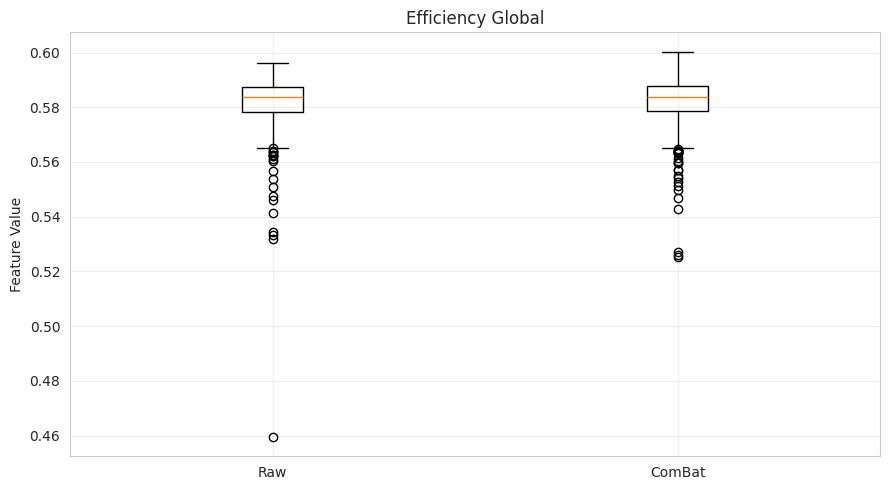

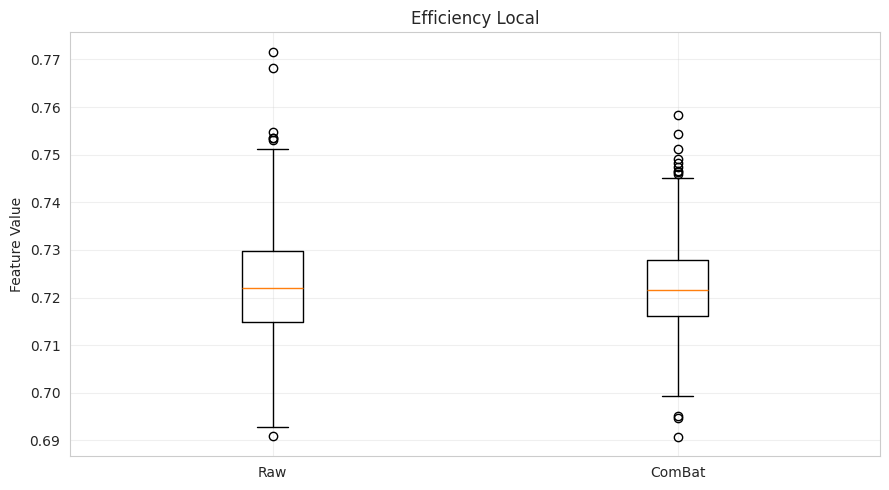

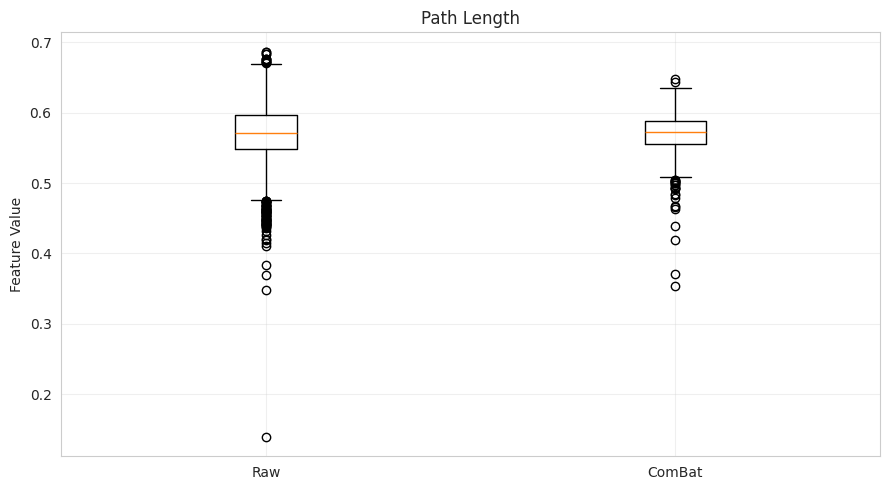

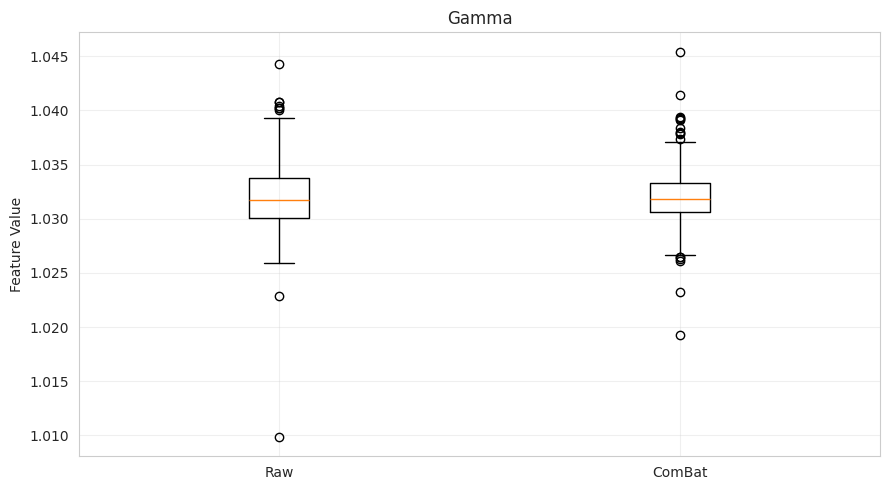

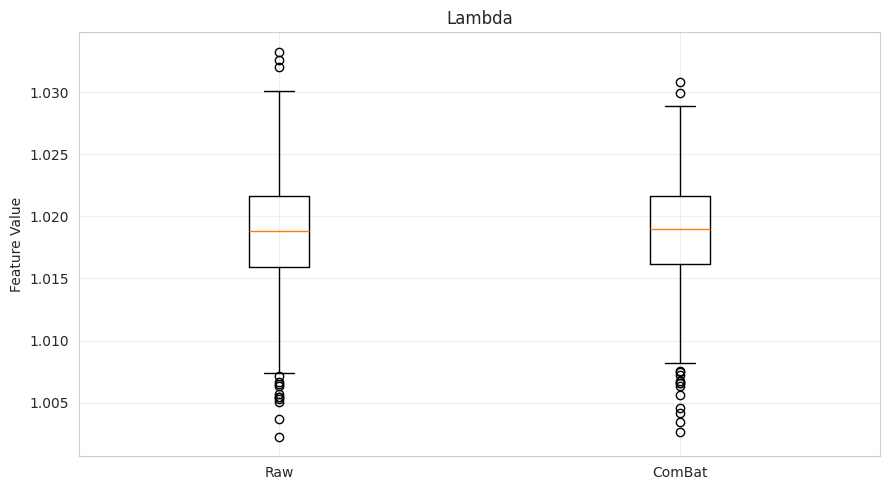

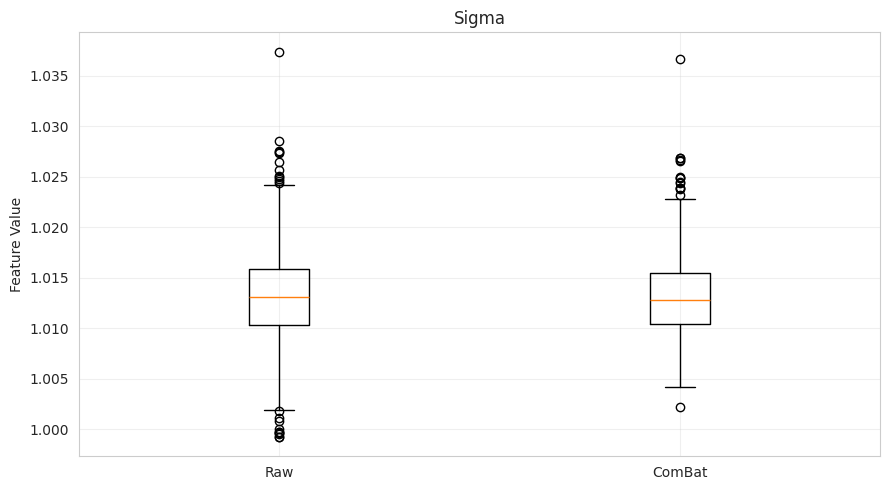

In [393]:
for raw, combat in zip(topology_features, combat_topology):

    plt.figure(figsize=(9,5))

    plt.boxplot(
        [
            combat_df_h[raw],
            combat_df_h[combat]
        ],
        tick_labels=["Raw","ComBat"]
    )

    plt.title(raw.replace("_"," ").title())

    plt.ylabel("Feature Value")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

E6.4 Correlation Preservation

In [394]:
correlations = []

for raw, combat in zip(topology_features, combat_topology):

    corr = combat_df_h[[raw,combat]].corr().iloc[0,1]

    correlations.append({

        "Metric": raw,

        "Correlation": corr

    })

correlations = pd.DataFrame(correlations)

display(correlations.round(4))

,Metric,Correlation
0,clustering,0.7712
1,efficiency_global,0.8838
2,efficiency_local,0.7659
3,path_length,0.4579
4,gamma,0.8348
5,lambda,0.9137
6,sigma,0.8150


E6.5 Feature Correlation Matrix

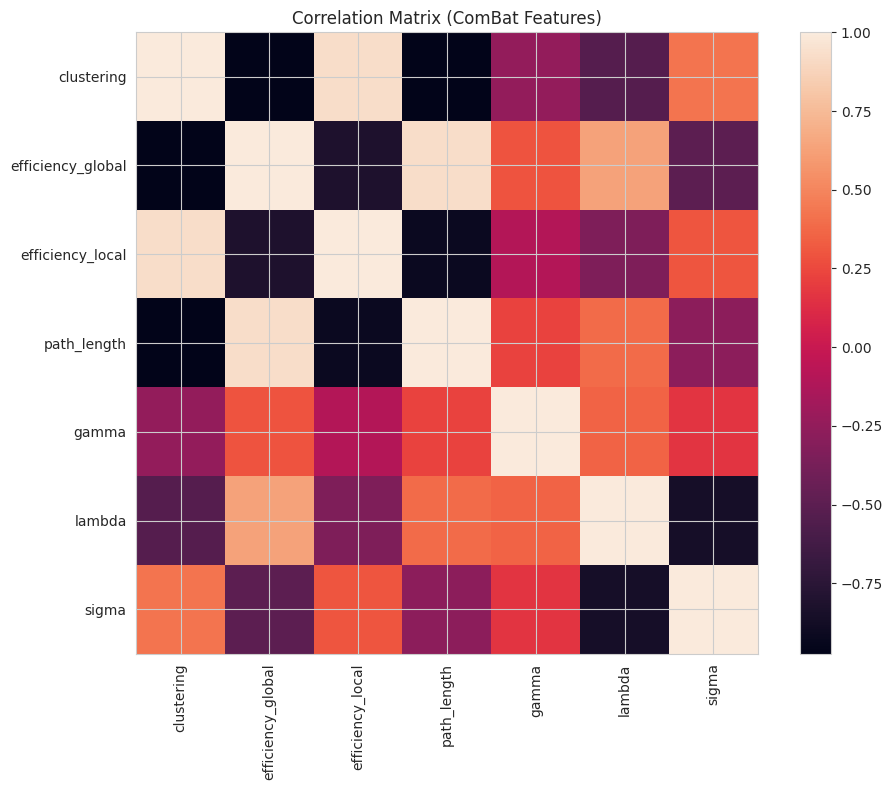

In [395]:
plt.figure(figsize=(10,8))

corr = combat_df_h[combat_topology].corr()

plt.imshow(corr)

plt.xticks(
    range(len(combat_topology)),
    topology_features,
    rotation=90
)

plt.yticks(
    range(len(combat_topology)),
    topology_features
)

plt.colorbar()

plt.title("Correlation Matrix (ComBat Features)")

plt.tight_layout()

plt.show()

E6.6 Save Validation Results

In [397]:
topology_summary.to_csv(
    "comparison_table.csv",
    index=False
)

correlations.to_csv(
    "graph_topology_preservation.csv",
    index=False
)

print("PHASE E COMPLETED")

print("Generated Files")
print("-------------------------------")
print("✓ subject_graph_features_combat.parquet")
print("✓ site_prediction_results.csv")
print("✓ diagnosis_prediction_results.csv")
print("✓ effect_size_before_after.csv")
print("✓ comparison_table.csv")
print("✓ graph_topology_preservation.csv")

PHASE E COMPLETED
Generated Files
-------------------------------
✓ subject_graph_features_combat.parquet
✓ site_prediction_results.csv
✓ diagnosis_prediction_results.csv
✓ effect_size_before_after.csv
✓ comparison_table.csv
✓ graph_topology_preservation.csv


Phase F

F1 Graph Dataset Assembly
F2 GCN
F2 GraphSAGE
F2 GAT
F3 Representation Learning
F4 Embedding Extraction
F4 PCA/UMAP/t-SNE
F5 Frozen MLP
F6 Site Leakage Prediction
F7 Encoder Comparison

In [398]:
# =============================================================================
# PHASE F - GRAPH DATASET ASSEMBLY
# =============================================================================

import torch
import numpy as np
import pandas as pd

from torch_geometric.data import Data
from tqdm import tqdm

In [399]:
print("PHASE F : GRAPH DATASET ASSEMBLY")

print(f"Subjects in ComBat table : {len(combat_df_h)}")

print("\nColumns")

display(combat_df_h.columns)

PHASE F : GRAPH DATASET ASSEMBLY
Subjects in ComBat table : 764

Columns


Index(['subject_id', 'site', 'Age', 'Gender', 'Handedness', 'label', 'avg_strength', 'clustering', 'transitivity', 'efficiency_global', 'efficiency_local', 'path_length', 'null_clustering',
       'null_transitivity', 'null_efficiency', 'null_path_length', 'gamma', 'lambda', 'sigma', 'label_binary', 'avg_strength_combat', 'clustering_combat', 'transitivity_combat',
       'efficiency_global_combat', 'efficiency_local_combat', 'path_length_combat', 'null_clustering_combat', 'null_transitivity_combat', 'null_efficiency_combat', 'null_path_length_combat',
       'gamma_combat', 'lambda_combat', 'sigma_combat'],
      dtype='object')

In [400]:
subject_lookup = combat_df_h.set_index("subject_id")

print(subject_lookup.head())

           site    Age  Gender  Handedness  label  avg_strength  clustering  transitivity  efficiency_global  efficiency_local  path_length  null_clustering  null_transitivity  null_efficiency  \
subject_id                                                                                                                                                                                         
10001       NYU  11.17     0.0        0.52      3     25.518262    0.344015      0.509756           0.579663          0.724173     0.558521         0.342534           0.357549         0.402551   
10002       NYU  13.24     0.0        0.52      3     24.530367    0.314482      0.488145           0.586297          0.714373     0.590982         0.317169           0.329402         0.393149   
10003       NYU   9.29     0.0        0.11      0     27.194683    0.389314      0.547604           0.567364          0.740329     0.502782         0.380277           0.408043         0.416690   
10004       NYU  13.

In [401]:
combat_feature_cols = [

    "avg_strength_combat",
    "clustering_combat",
    "transitivity_combat",
    "efficiency_global_combat",
    "efficiency_local_combat",
    "path_length_combat",
    "null_clustering_combat",
    "null_transitivity_combat",
    "null_efficiency_combat",
    "null_path_length_combat",
    "gamma_combat",
    "lambda_combat",
    "sigma_combat"

]

F1.5 Graph Construction

In [403]:
# Search for possible FC variables

for name in globals():
    if "fc" in name.lower() or "graph" in name.lower() or "adj" in name.lower():
        print(name)

GRAPH_DATASET
graph
p_adj
GRAPH_FILE
null_graph
fc
adjusted_rand_score
graph_features
demographics
subject_graphs


In [407]:
graph_df = pd.read_parquet(GRAPH_DATASET)

print(graph_df.shape)

display(graph_df.head())

print(graph_df.columns.tolist())

(31060, 29)


,nodes,edges,density,components,avg_degree,avg_strength,clustering,transitivity,efficiency_global,efficiency_local,path_length,builder,distance_metric,subject_id,site,session,run,window_index,label,Age,Gender,Handedness,null_clustering,null_transitivity,null_efficiency,null_path_length,gamma,lambda,sigma
0,190,3591,0.2,1,37.8,25.236876,0.342180,0.558689,0.571893,0.720297,0.600203,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,0,0,12.36,0.0,1.0,0.345911,0.391120,0.386014,2.946965,1.034462,0.996910,1.037668
1,190,3591,0.2,1,37.8,24.667315,0.331305,0.538590,0.577439,0.721905,0.616338,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,1,0,12.36,0.0,1.0,0.328007,0.369279,0.383009,2.939382,1.029155,0.998416,1.030787
2,190,3591,0.2,1,37.8,24.528949,0.322564,0.542367,0.578933,0.712654,0.621745,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,2,0,12.36,0.0,1.0,0.318960,0.369538,0.381864,2.941301,1.027200,1.001865,1.025288
3,190,3591,0.2,1,37.8,24.231793,0.321985,0.529712,0.580089,0.723197,0.635170,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,3,0,12.36,0.0,1.0,0.320889,0.356290,0.379751,2.949367,1.033751,1.007655,1.025898
4,190,3591,0.2,1,37.8,24.204246,0.320368,0.521831,0.581700,0.722825,0.629521,MST_PT_v1.0,1-|r|,1018959,KKI,1,1,4,0,12.36,0.0,1.0,0.331577,0.348304,0.381742,2.924067,1.030882,1.011138,1.019527


['nodes', 'edges', 'density', 'components', 'avg_degree', 'avg_strength', 'clustering', 'transitivity', 'efficiency_global', 'efficiency_local', 'path_length', 'builder', 'distance_metric', 'subject_id', 'site', 'session', 'run', 'window_index', 'label', 'Age', 'Gender', 'Handedness', 'null_clustering', 'null_transitivity', 'null_efficiency', 'null_path_length', 'gamma', 'lambda', 'sigma']


In [402]:
subject_graphs = []

missing_subjects = []

print("\nConstructing PyTorch Geometric graphs...\n")

for subject_id, fc in tqdm(dynamic_fc_dict.items()):

    if subject_id not in subject_lookup.index:

        missing_subjects.append(subject_id)

        continue

    edge_index, edge_weight = build_graph(fc)

    # --------------------------------------------------
    # Node features
    # --------------------------------------------------

    x = torch.tensor(
        fc,
        dtype=torch.float
    )

    # --------------------------------------------------
    # Labels
    # --------------------------------------------------

    diagnosis = int(subject_lookup.loc[subject_id,"label_binary"])

    site = subject_lookup.loc[subject_id,"site"]

    graph_features = torch.tensor(

        subject_lookup.loc[
            subject_id,
            combat_feature_cols
        ].values,

        dtype=torch.float

    )

    graph = Data(

        x=x,

        edge_index=edge_index,

        edge_attr=edge_weight,

        y=torch.tensor([diagnosis]),

        graph_features=graph_features,

        subject_id=str(subject_id),

        site=str(site)

    )

    subject_graphs.append(graph)

print()

print(f"Graphs Created : {len(subject_graphs)}")
print(f"Missing Subjects : {len(missing_subjects)}")


Constructing PyTorch Geometric graphs...



NameError: name 'dynamic_fc_dict' is not defined

# Phase E2: Harmonization of Dynamic Brain-State Biomarkers

## Objective

Phase VIII established that dynamic brain-state biomarkers capture clinically meaningful temporal characteristics of resting-state fMRI and represent the primary subject-level representation for downstream learning.

Unlike the graph-theoretic metrics harmonized in Phase E, these biomarkers have not yet undergone site-effect correction.

This phase aims to:

- Quantify site effects in dynamic biomarkers.
- Identify which biomarkers require harmonization.
- Apply ComBat harmonization where statistically appropriate.
- Validate preservation of biological information while reducing scanner/site variability.
- Produce a harmonized subject-level dataset for downstream GNN, DANN and QGNN experiments.

This notebook is independent of Phase E and does not modify previous results.

In [409]:
import pandas as pd

df = pd.read_parquet("adhd_data/workflow2/v8/subject_dynamic_dataset.parquet")

dynamic_cols = [
    c for c in df.columns
    if c not in [
        "subject_id",
        "site",
        "diagnosis_code",
        "diagnosis_binary",
    ]
]

summary = pd.DataFrame({
    "dtype": df[dynamic_cols].dtypes,
    "min": df[dynamic_cols].min(),
    "max": df[dynamic_cols].max(),
    "mean": df[dynamic_cols].mean(),
    "std": df[dynamic_cols].std(),
    "unique": df[dynamic_cols].nunique()
})

display(summary)

,dtype,min,max,mean,std,unique
occupancy_state0,float64,0.0,1.000000,0.490484,0.305434,212
occupancy_state1,float64,0.0,1.000000,0.273182,0.275719,151
occupancy_state2,float64,0.0,1.000000,0.236334,0.166598,182
dwell_state0,float64,0.0,46.000000,6.235832,6.464971,217
dwell_state1,float64,0.0,33.000000,3.435935,5.557597,159
dwell_state2,float64,0.0,46.000000,2.829163,2.452664,147
switching_rate,float64,0.0,0.600000,0.204769,0.115098,104
transition_entropy,float64,0.0,1.478353,0.692535,0.369928,641
C00,int64,0.0,57.000000,15.956806,12.133031,54
C01,int64,0.0,8.000000,1.352094,1.547114,9


In [410]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal

from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8,5)
sns.set_theme(style="whitegrid")

In [411]:
ROOT = Path("adhd_data")

V8_DIR = ROOT / "workflow2" / "v8"
OUTPUT_DIR = ROOT / "workflow2" / "PhaseE2"

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [412]:
dynamic_df = pd.read_parquet(
    V8_DIR / "subject_dynamic_dataset.parquet"
)

print(dynamic_df.shape)

dynamic_df.head()

(764, 30)


,subject_id,site,diagnosis_code,diagnosis_binary,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy,C00,C01,C02,C10,C11,C12,C20,C21,C22,P00,P01,P02,P10,P11,P12,P20,P21,P22
0,10001,NYU,3,1,0.362069,0.275862,0.362069,6.000000,2.625,3.125000,0.285714,1.009055,16,3,2,1,10,5,3,2,14,0.761905,0.142857,0.095238,0.062500,0.625000,0.312500,0.157895,0.105263,0.736842
1,10002,NYU,3,1,0.672414,0.051724,0.275862,4.833333,1.500,2.833333,0.303571,0.615102,30,0,7,1,1,1,8,0,8,0.810811,0.000000,0.189189,0.333333,0.333333,0.333333,0.500000,0.000000,0.500000
2,10003,NYU,0,0,0.034483,0.551724,0.413793,1.000000,8.000,6.000000,0.142857,0.390016,0,0,1,0,14,1,1,1,10,0.000000,0.000000,1.000000,0.000000,0.933333,0.066667,0.083333,0.083333,0.833333
3,10004,NYU,0,0,0.448276,0.396552,0.155172,3.250000,2.875,3.250000,0.303571,1.096601,18,4,2,7,15,1,1,2,6,0.750000,0.166667,0.083333,0.304348,0.652174,0.043478,0.111111,0.222222,0.666667
4,10005,NYU,2,1,0.068966,0.068966,0.862069,2.000000,2.000,8.333333,0.142857,0.832383,1,0,1,0,1,1,1,1,22,0.500000,0.000000,0.500000,0.000000,0.500000,0.500000,0.041667,0.041667,0.916667


## Candidate Biomarkers for Harmonization

Not every variable should be harmonized.

Continuous biomarkers representing temporal brain dynamics are appropriate candidates for ComBat.

Transition count matrices and transition probability matrices are retained separately because they obey structural constraints that may be violated by independent feature-wise harmonization.

Candidate biomarkers:

- occupancy_state0
- occupancy_state1
- occupancy_state2
- dwell_state0
- dwell_state1
- dwell_state2
- switching_rate
- transition_entropy

In [413]:
candidate_features = [

    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",

    "dwell_state0",
    "dwell_state1",
    "dwell_state2",

    "switching_rate",
    "transition_entropy"
]

meta_cols = [

    "subject_id",
    "site",
    "diagnosis_code",
    "diagnosis_binary"
]

## Dataset Integrity

Before harmonization, verify:

- no missing values
- no duplicated subjects
- expected feature ranges

In [414]:
print("="*70)
print("Shape")
print(dynamic_df.shape)

print("\nMissing values")
print(dynamic_df[candidate_features].isna().sum())

print("\nDuplicate subjects")
print(dynamic_df.subject_id.duplicated().sum())

Shape
(764, 30)

Missing values
occupancy_state0      0
occupancy_state1      0
occupancy_state2      0
dwell_state0          0
dwell_state1          0
dwell_state2          0
switching_rate        0
transition_entropy    0
dtype: int64

Duplicate subjects
0


In [415]:
summary = dynamic_df[candidate_features].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
occupancy_state0,764.0,0.490484,0.305434,0.0,0.258621,0.487805,0.737414,1.000000
occupancy_state1,764.0,0.273182,0.275719,0.0,0.050000,0.195122,0.413043,1.000000
occupancy_state2,764.0,0.236334,0.166598,0.0,0.111111,0.217391,0.344828,1.000000
dwell_state0,764.0,6.235832,6.464971,0.0,2.400000,4.500000,8.000000,46.000000
dwell_state1,764.0,3.435935,5.557597,0.0,0.864583,2.037500,3.388393,33.000000
dwell_state2,764.0,2.829163,2.452664,0.0,1.412500,2.500000,3.861607,46.000000
switching_rate,764.0,0.204769,0.115098,0.0,0.125000,0.214286,0.289583,0.600000
transition_entropy,764.0,0.692535,0.369928,0.0,0.468204,0.718388,0.983768,1.478353


In [416]:
from scipy.stats import kruskal
sites = sorted(dynamic_df["site"].unique())
k = len(sites)
N = len(dynamic_df)
results = []
for feature in candidate_features:
    groups = [
        dynamic_df.loc[dynamic_df.site == s, feature].values
        for s in sites
    ]
    H, p = kruskal(*groups)
    eta2 = max(0, (H - k + 1) / (N - k))
    results.append({
        "Feature": feature,
        "H": H,
        "p-value": p,
        "Eta²": eta2
    })
site_effect_df = pd.DataFrame(results)
site_effect_df = site_effect_df.sort_values(
    "Eta²",
    ascending=False
)

site_effect_df

,Feature,H,p-value,Eta²
4,dwell_state1,443.960163,7.276940e-91,0.577431
1,occupancy_state1,428.614462,1.408008e-87,0.557105
7,transition_entropy,375.601050,3.084347e-76,0.486889
0,occupancy_state0,366.453182,2.777454e-74,0.474772
3,dwell_state0,335.328100,1.222899e-67,0.433547
6,switching_rate,275.680709,6.111651e-55,0.354544
2,occupancy_state2,101.785237,1.841924e-18,0.124219
5,dwell_state2,87.167025,1.745651e-15,0.104857


In [417]:
site_effect_df["Significant"] = site_effect_df["p-value"] < 0.05
display(site_effect_df)

print("\nSignificant features:",
      site_effect_df["Significant"].sum(),
      "/",
      len(site_effect_df))

,Feature,H,p-value,Eta²,Significant
4,dwell_state1,443.960163,7.276940e-91,0.577431,True
1,occupancy_state1,428.614462,1.408008e-87,0.557105,True
7,transition_entropy,375.601050,3.084347e-76,0.486889,True
0,occupancy_state0,366.453182,2.777454e-74,0.474772,True
3,dwell_state0,335.328100,1.222899e-67,0.433547,True
6,switching_rate,275.680709,6.111651e-55,0.354544,True
2,occupancy_state2,101.785237,1.841924e-18,0.124219,True
5,dwell_state2,87.167025,1.745651e-15,0.104857,True



Significant features: 8 / 8


# ComBat Harmonization

## Rationale

Previous analyses (Phase VIII) demonstrated substantial acquisition-site effects in the dynamic brain-state biomarkers.

The objective of this step is to remove unwanted site-specific variation while preserving biologically meaningful variation associated with ADHD diagnosis.

ComBat performs empirical Bayes harmonization by estimating and removing additive and multiplicative batch effects.

Batch variable:
- Acquisition Site

Biological covariate to preserve:
- ADHD Diagnosis

In [418]:
# Features to harmonize

harmonize_features = [
    "occupancy_state0",
    "occupancy_state1",
    "occupancy_state2",

    "dwell_state0",
    "dwell_state1",
    "dwell_state2",

    "switching_rate",
    "transition_entropy"

]
X = dynamic_df[harmonize_features].copy()
print(X.shape)
X.head()

(764, 8)


,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy
0,0.362069,0.275862,0.362069,6.000000,2.625,3.125000,0.285714,1.009055
1,0.672414,0.051724,0.275862,4.833333,1.500,2.833333,0.303571,0.615102
2,0.034483,0.551724,0.413793,1.000000,8.000,6.000000,0.142857,0.390016
3,0.448276,0.396552,0.155172,3.250000,2.875,3.250000,0.303571,1.096601
4,0.068966,0.068966,0.862069,2.000000,2.000,8.333333,0.142857,0.832383


In [419]:
# Biological covariates to preserve

covars = pd.DataFrame({

    "SITE": dynamic_df["site"].astype(str),
    "DIAGNOSIS": dynamic_df["diagnosis_binary"].astype(int)

})

covars.head()

,SITE,DIAGNOSIS
0,NYU,1
1,NYU,1
2,NYU,0
3,NYU,0
4,NYU,1


In [420]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=harmonize_features
)
X_scaled.head()

,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy
0,-0.420709,0.009727,0.755211,-0.036502,-0.146010,0.120698,0.703732,0.856187
1,0.596034,-0.803728,0.237419,-0.217080,-0.348568,0.001702,0.858981,-0.209457
2,-1.493937,1.010903,1.065886,-0.810408,0.821768,1.293660,-0.538256,-0.818313
3,-0.138280,0.447742,-0.487490,-0.462150,-0.100997,0.171696,0.858981,1.092997
4,-1.380966,-0.741154,3.758405,-0.655627,-0.258543,2.245630,-0.538256,0.378290


In [421]:
try:
    from neuroCombat import neuroCombat
except ImportError:
    !pip install neuroCombat
    from neuroCombat import neuroCombat

In [422]:
combat_result = neuroCombat(
    dat=X_scaled.T,
    covars=covars,
    batch_col="SITE",
    categorical_cols=["DIAGNOSIS"]
)

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


In [423]:
harmonized_scaled = pd.DataFrame(
    combat_result["data"].T,
    columns=harmonize_features
)
harmonized_scaled.head()

,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy
0,-0.390143,0.130596,0.479357,0.084030,0.060384,-0.111726,0.335767,0.529075
1,0.646496,-0.648591,-0.051362,-0.162711,-0.418019,-0.264766,0.512116,-0.764160
2,-1.485868,1.085559,0.797324,-0.994158,2.398900,1.407776,-1.066844,-1.485157
3,-0.103682,0.546122,-0.794833,-0.518301,0.219513,-0.035172,0.520296,0.834354
4,-1.369192,-0.588653,3.557528,-0.761938,-0.205395,2.621130,-1.075025,-0.050887


In [424]:
harmonized = pd.DataFrame(
    scaler.inverse_transform(harmonized_scaled),
    columns=harmonize_features
)
harmonized.head()

,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy
0,0.371399,0.309166,0.316142,6.778726,3.771302,2.555316,0.243390,0.888126
1,0.687817,0.094470,0.227783,5.184599,1.114277,2.180206,0.263674,0.410036
2,0.036946,0.572295,0.369080,-0.187163,16.759326,6.279705,0.082057,0.143493
3,0.458837,0.423659,0.104003,2.887224,4.655099,2.742955,0.264615,1.000984
4,0.072559,0.110985,0.828625,1.313149,2.295177,9.253706,0.081116,0.673723


In [426]:
harmonized_df = dynamic_df.copy()
harmonized_df[harmonize_features] = harmonized
harmonized_df.head()

,subject_id,site,diagnosis_code,diagnosis_binary,occupancy_state0,occupancy_state1,occupancy_state2,dwell_state0,dwell_state1,dwell_state2,switching_rate,transition_entropy,C00,C01,C02,C10,C11,C12,C20,C21,C22,P00,P01,P02,P10,P11,P12,P20,P21,P22
0,10001,NYU,3,1,0.371399,0.309166,0.316142,6.778726,3.771302,2.555316,0.243390,0.888126,16,3,2,1,10,5,3,2,14,0.761905,0.142857,0.095238,0.062500,0.625000,0.312500,0.157895,0.105263,0.736842
1,10002,NYU,3,1,0.687817,0.094470,0.227783,5.184599,1.114277,2.180206,0.263674,0.410036,30,0,7,1,1,1,8,0,8,0.810811,0.000000,0.189189,0.333333,0.333333,0.333333,0.500000,0.000000,0.500000
2,10003,NYU,0,0,0.036946,0.572295,0.369080,-0.187163,16.759326,6.279705,0.082057,0.143493,0,0,1,0,14,1,1,1,10,0.000000,0.000000,1.000000,0.000000,0.933333,0.066667,0.083333,0.083333,0.833333
3,10004,NYU,0,0,0.458837,0.423659,0.104003,2.887224,4.655099,2.742955,0.264615,1.000984,18,4,2,7,15,1,1,2,6,0.750000,0.166667,0.083333,0.304348,0.652174,0.043478,0.111111,0.222222,0.666667
4,10005,NYU,2,1,0.072559,0.110985,0.828625,1.313149,2.295177,9.253706,0.081116,0.673723,1,0,1,0,1,1,1,1,22,0.500000,0.000000,0.500000,0.000000,0.500000,0.500000,0.041667,0.041667,0.916667


In [427]:
save_path = OUTPUT_DIR / "subject_dynamic_dataset_combat.parquet"
harmonized_df.to_parquet(save_path, index=False)
print(save_path)

adhd_data/workflow2/PhaseE2/subject_dynamic_dataset_combat.parquet


# Validation of Dynamic Biomarker Harmonization

This section evaluates whether ComBat successfully reduced site-specific variation while preserving biologically meaningful information.

Validation consists of:

1. Distribution comparison
2. Site-effect analysis
3. Effect-size comparison
4. PCA visualization
5. UMAP visualization
6. Random Forest site prediction
7. Random Forest diagnosis prediction
8. Correlation preservation

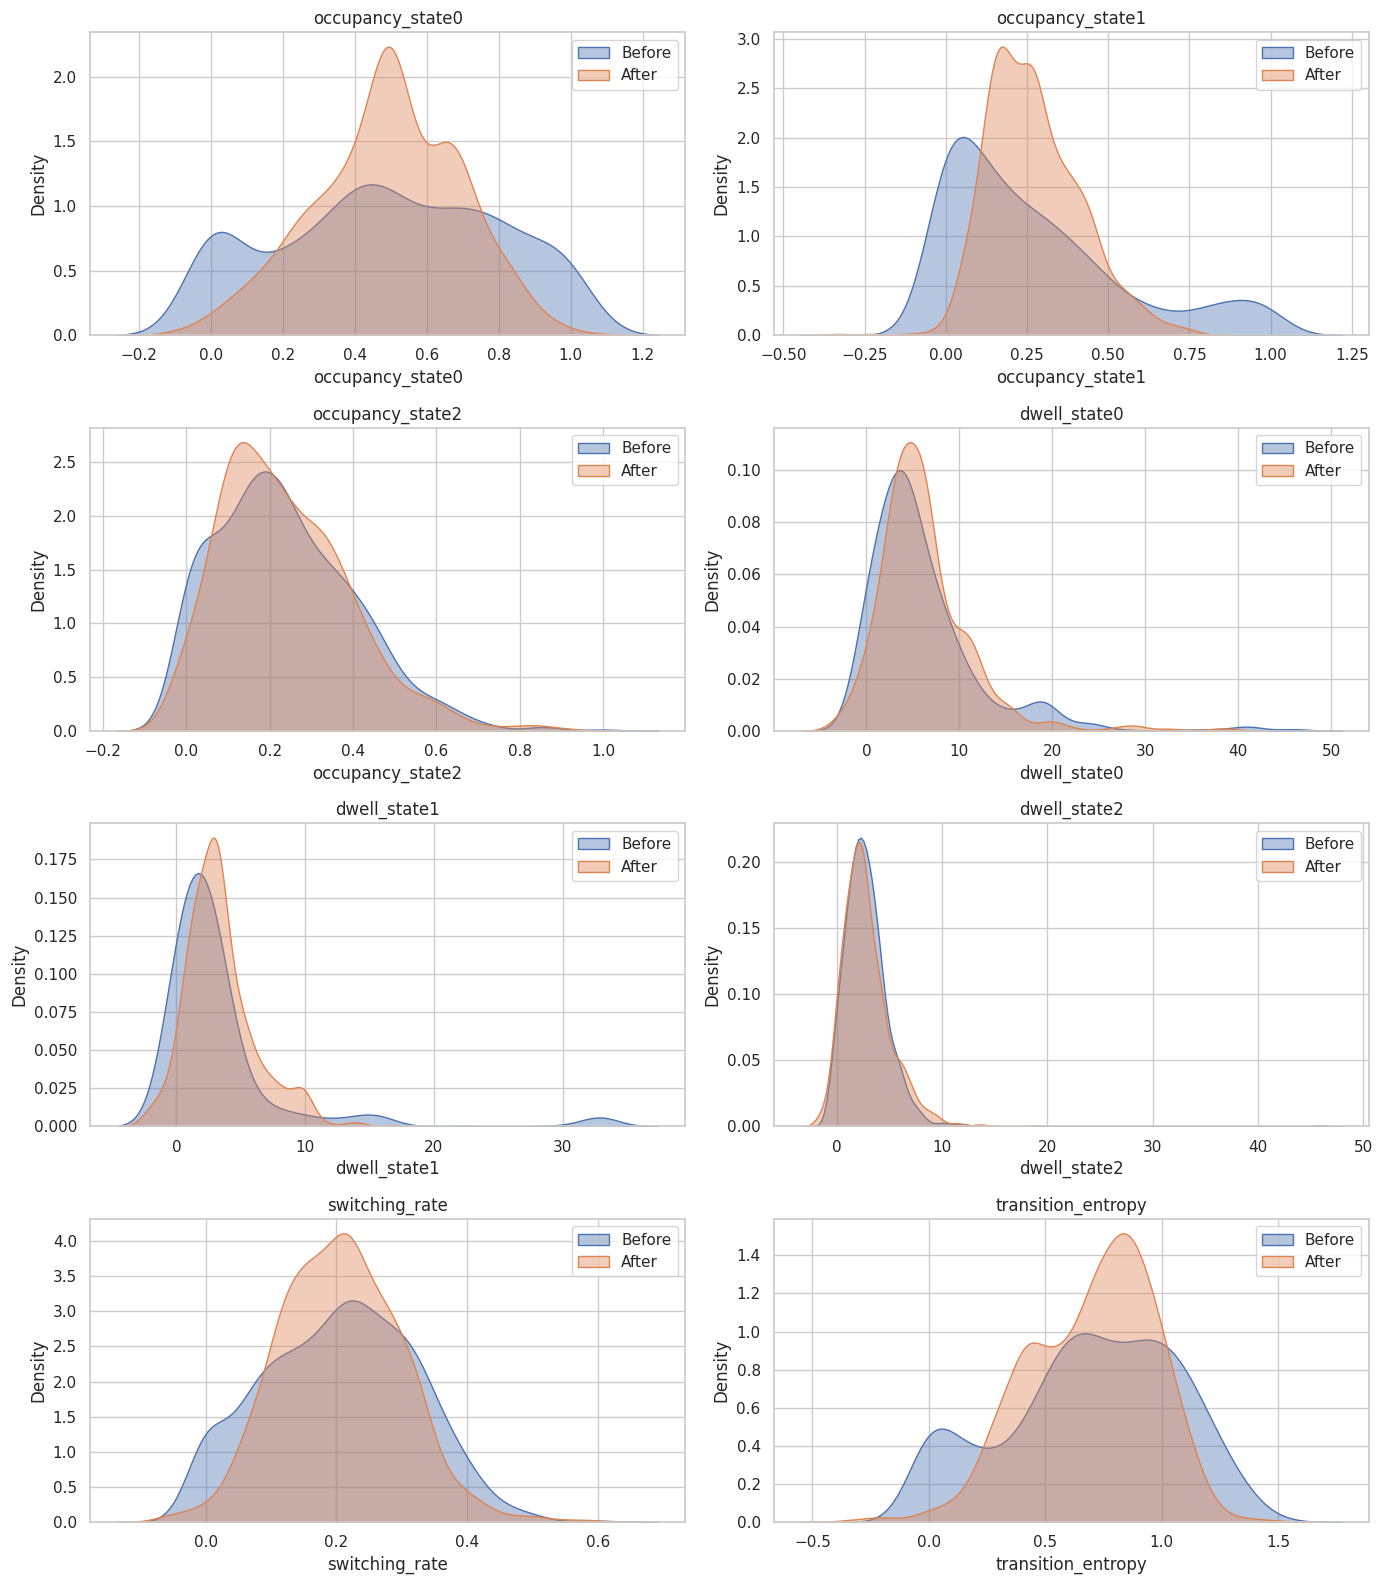

In [428]:
import math
fig, axes = plt.subplots(4, 2, figsize=(14,16))
axes = axes.flatten()
for ax, feature in zip(axes, harmonize_features):
    sns.kdeplot(
        dynamic_df[feature],
        fill=True,
        alpha=0.4,
        label="Before",
        ax=ax
    )
    sns.kdeplot(
        harmonized_df[feature],
        fill=True,
        alpha=0.4,
        label="After",
        ax=ax
    )
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "distribution_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Site Effect After Harmonization
The Kruskal–Wallis H-test is repeated on the harmonized biomarkers.
Successful harmonization should substantially reduce both statistical significance and effect size.

In [429]:
results_after = []
for feature in harmonize_features:
    groups = [
        harmonized_df.loc[
            harmonized_df.site == s,
            feature
        ].values
        for s in sites
    ]
    H, p = kruskal(*groups)
    eta2 = max(0, (H - k + 1)/(N-k))
    results_after.append({
        "Feature":feature,
        "H_after":H,
        "p_after":p,
        "Eta2_after":eta2
    })
after_df = pd.DataFrame(results_after)
after_df

,Feature,H_after,p_after,Eta2_after
0,occupancy_state0,5.056170,0.751556,0.000000
1,occupancy_state1,5.655503,0.685757,0.000000
2,occupancy_state2,0.316539,0.999977,0.000000
3,dwell_state0,22.334203,0.004333,0.018986
4,dwell_state1,7.591161,0.474389,0.000000
5,dwell_state2,2.425201,0.965128,0.000000
6,switching_rate,3.692946,0.883710,0.000000
7,transition_entropy,4.038974,0.853590,0.000000


In [430]:
comparison = site_effect_df.merge(
    after_df,
    on="Feature"
)
comparison["Eta2 Reduction"] = (
    comparison["Eta²"]
    - comparison["Eta2_after"]
)

comparison = comparison.sort_values(
    "Eta2 Reduction",
    ascending=False
)

comparison

,Feature,H,p-value,Eta²,Significant,H_after,p_after,Eta2_after,Eta2 Reduction
0,dwell_state1,443.960163,7.276940e-91,0.577431,True,7.591161,0.474389,0.000000,0.577431
1,occupancy_state1,428.614462,1.408008e-87,0.557105,True,5.655503,0.685757,0.000000,0.557105
2,transition_entropy,375.601050,3.084347e-76,0.486889,True,4.038974,0.853590,0.000000,0.486889
3,occupancy_state0,366.453182,2.777454e-74,0.474772,True,5.056170,0.751556,0.000000,0.474772
4,dwell_state0,335.328100,1.222899e-67,0.433547,True,22.334203,0.004333,0.018986,0.414561
5,switching_rate,275.680709,6.111651e-55,0.354544,True,3.692946,0.883710,0.000000,0.354544
6,occupancy_state2,101.785237,1.841924e-18,0.124219,True,0.316539,0.999977,0.000000,0.124219
7,dwell_state2,87.167025,1.745651e-15,0.104857,True,2.425201,0.965128,0.000000,0.104857


In [431]:
comparison.to_csv(
    OUTPUT_DIR / "combat_validation_summary.csv",
    index=False
)
comparison

,Feature,H,p-value,Eta²,Significant,H_after,p_after,Eta2_after,Eta2 Reduction
0,dwell_state1,443.960163,7.276940e-91,0.577431,True,7.591161,0.474389,0.000000,0.577431
1,occupancy_state1,428.614462,1.408008e-87,0.557105,True,5.655503,0.685757,0.000000,0.557105
2,transition_entropy,375.601050,3.084347e-76,0.486889,True,4.038974,0.853590,0.000000,0.486889
3,occupancy_state0,366.453182,2.777454e-74,0.474772,True,5.056170,0.751556,0.000000,0.474772
4,dwell_state0,335.328100,1.222899e-67,0.433547,True,22.334203,0.004333,0.018986,0.414561
5,switching_rate,275.680709,6.111651e-55,0.354544,True,3.692946,0.883710,0.000000,0.354544
6,occupancy_state2,101.785237,1.841924e-18,0.124219,True,0.316539,0.999977,0.000000,0.124219
7,dwell_state2,87.167025,1.745651e-15,0.104857,True,2.425201,0.965128,0.000000,0.104857


In [432]:
print("="*60)
print("Mean Eta² Before:",
      comparison["Eta²"].mean())
print("Mean Eta² After:",
      comparison["Eta2_after"].mean())
print()
print("Reduction:",
      comparison["Eta2 Reduction"].mean())
print()
print("Significant Before:",
      (comparison["p-value"]<0.05).sum())

print("Significant After:",
      (comparison["p_after"]<0.05).sum())

Mean Eta² Before: 0.38917051783919887
Mean Eta² After: 0.002373212399556659

Reduction: 0.3867973054396422

Significant Before: 8
Significant After: 1


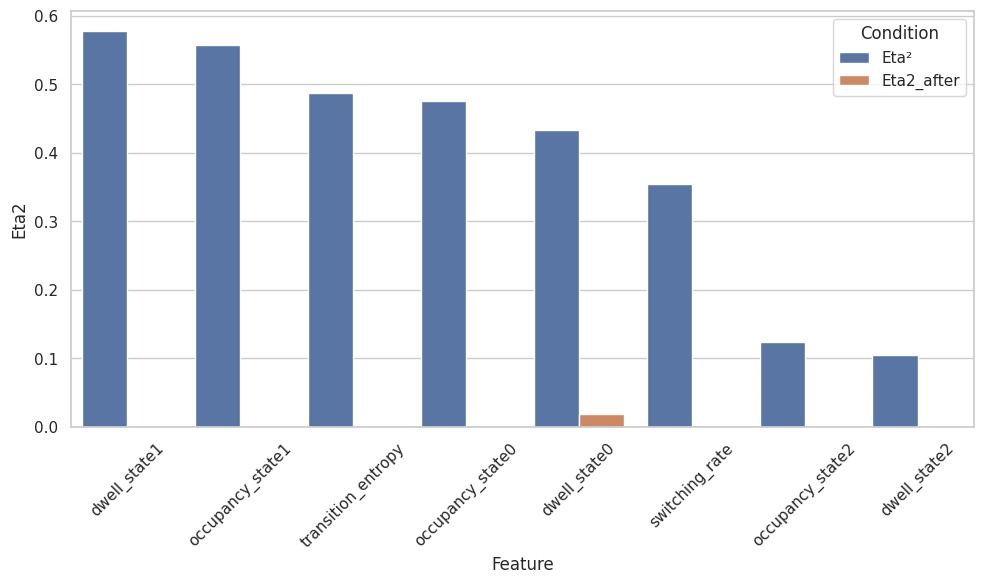

In [433]:
plot_df = comparison.melt(
    id_vars="Feature",
    value_vars=["Eta²","Eta2_after"],
    var_name="Condition",
    value_name="Eta2"
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=plot_df,
    x="Feature",
    y="Eta2",
    hue="Condition"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR/"eta2_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [435]:
corr_before = dynamic_df[harmonize_features].corr()
corr_after = harmonized_df[harmonize_features].corr()

r = np.corrcoef(
    corr_before.values.flatten(),
    corr_after.values.flatten()
)[0, 1]

print(f"Correlation preservation (matrix correlation): {r:.4f}")

Correlation preservation (matrix correlation): 0.9661


# Principal Component Analysis (PCA)
## Objective
Principal Component Analysis (PCA) provides a low-dimensional visualization of the dynamic biomarker space.
Successful harmonization should:

- Reduce clustering by acquisition site.
- Preserve the intrinsic biological structure associated with ADHD diagnosis.

Four visualizations are produced:

1. Before ComBat (colored by site)
2. After ComBat (colored by site)
3. Before ComBat (colored by diagnosis)
4. After ComBat (colored by diagnosis)

In [436]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pca_before = pca.fit_transform(dynamic_df[harmonize_features])
explained_before = pca.explained_variance_ratio_
pca_after = pca.fit_transform(harmonized_df[harmonize_features])
explained_after = pca.explained_variance_ratio_

In [437]:
pca_before_df = pd.DataFrame(
    pca_before,
    columns=["PC1", "PC2"]
)
pca_before_df["Site"] = dynamic_df["site"].values
pca_before_df["Diagnosis"] = dynamic_df["diagnosis_binary"].values
pca_after_df = pd.DataFrame(
    pca_after,
    columns=["PC1", "PC2"]
)

pca_after_df["Site"] = harmonized_df["site"].values
pca_after_df["Diagnosis"] = harmonized_df["diagnosis_binary"].values

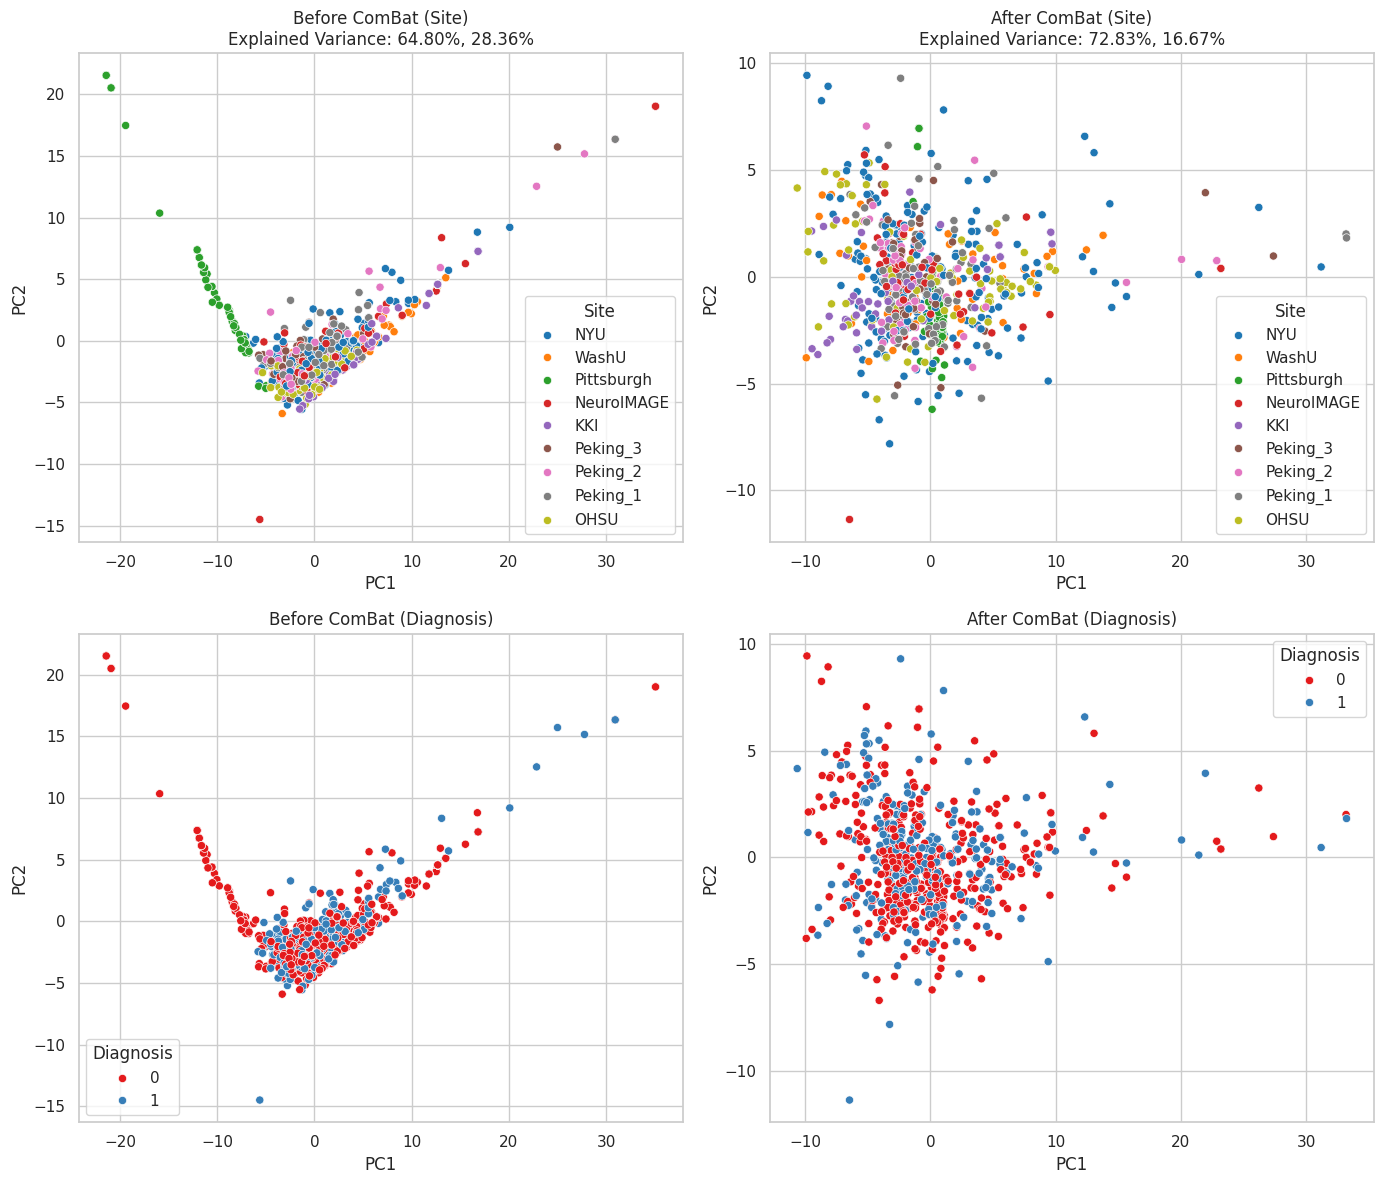

In [438]:
fig, axes = plt.subplots(2,2, figsize=(14,12))
# Before - Site
sns.scatterplot(
    data=pca_before_df,
    x="PC1",
    y="PC2",
    hue="Site",
    palette="tab10",
    s=35,
    ax=axes[0,0]
)
axes[0,0].set_title(
    f"Before ComBat (Site)\nExplained Variance: "
    f"{explained_before[0]:.2%}, {explained_before[1]:.2%}"
)

# After - Site
sns.scatterplot(
    data=pca_after_df,
    x="PC1",
    y="PC2",
    hue="Site",
    palette="tab10",
    s=35,
    ax=axes[0,1]
)
axes[0,1].set_title(
    f"After ComBat (Site)\nExplained Variance: "
    f"{explained_after[0]:.2%}, {explained_after[1]:.2%}"
)

# Before - Diagnosis
sns.scatterplot(
    data=pca_before_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette="Set1",
    s=35,
    ax=axes[1,0]
)
axes[1,0].set_title("Before ComBat (Diagnosis)")
# After - Diagnosis
sns.scatterplot(
    data=pca_after_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette="Set1",
    s=35,
    ax=axes[1,1]
)
axes[1,1].set_title("After ComBat (Diagnosis)")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "PCA_validation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Uniform Manifold Approximation and Projection (UMAP)
PCA captures only linear variation.
UMAP provides a nonlinear embedding capable of revealing more subtle site-dependent or diagnosis-related structure.
Successful harmonization should reduce clustering by acquisition site while maintaining the overall manifold structure.

In [439]:
try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap

In [440]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
umap_before = reducer.fit_transform(
    dynamic_df[harmonize_features]
)
umap_after = reducer.fit_transform(
    harmonized_df[harmonize_features]
)

In [441]:
umap_before_df = pd.DataFrame(
    umap_before,
    columns=["UMAP1","UMAP2"]
)

umap_before_df["Site"] = dynamic_df.site
umap_before_df["Diagnosis"] = dynamic_df.diagnosis_binary

umap_after_df = pd.DataFrame(
    umap_after,
    columns=["UMAP1","UMAP2"]
)

umap_after_df["Site"] = harmonized_df.site
umap_after_df["Diagnosis"] = harmonized_df.diagnosis_binary

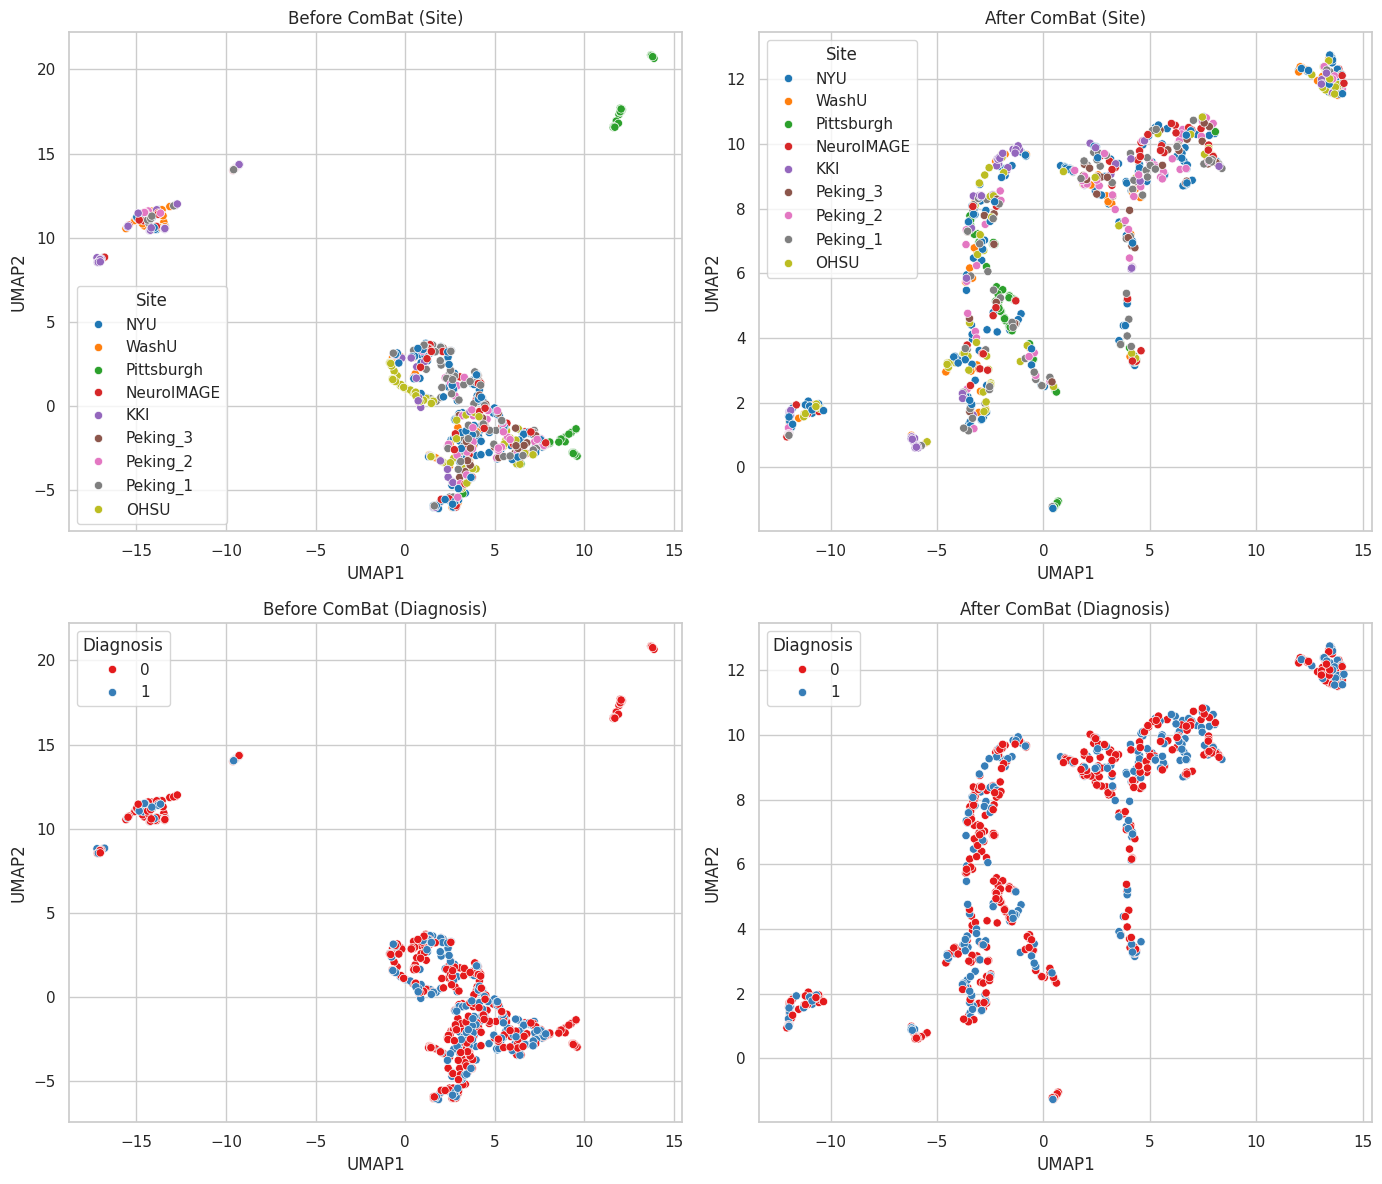

In [442]:
fig, axes = plt.subplots(2,2, figsize=(14,12))

sns.scatterplot(
    data=umap_before_df,
    x="UMAP1",
    y="UMAP2",
    hue="Site",
    palette="tab10",
    s=35,
    ax=axes[0,0]
)

axes[0,0].set_title("Before ComBat (Site)")

sns.scatterplot(
    data=umap_after_df,
    x="UMAP1",
    y="UMAP2",
    hue="Site",
    palette="tab10",
    s=35,
    ax=axes[0,1]
)

axes[0,1].set_title("After ComBat (Site)")

sns.scatterplot(
    data=umap_before_df,
    x="UMAP1",
    y="UMAP2",
    hue="Diagnosis",
    palette="Set1",
    s=35,
    ax=axes[1,0]
)

axes[1,0].set_title("Before ComBat (Diagnosis)")

sns.scatterplot(
    data=umap_after_df,
    x="UMAP1",
    y="UMAP2",
    hue="Diagnosis",
    palette="Set1",
    s=35,
    ax=axes[1,1]
)

axes[1,1].set_title("After ComBat (Diagnosis)")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "UMAP_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Random Forest Validation

## Objective

The final validation evaluates whether ComBat successfully removes acquisition-site information while preserving clinically relevant ADHD-related information.

Two independent classification tasks are performed.

Task 1:
- Predict acquisition site

Expected outcome:
- Accuracy should decrease after harmonization.

Task 2:
- Predict ADHD diagnosis

Expected outcome:
- Performance should remain similar after harmonization.

A Stratified 5-fold Cross Validation protocol is used throughout.

In [443]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [444]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy":"accuracy",
    "balanced_accuracy":"balanced_accuracy",
    "precision":make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall":make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1":"f1"
}

## Site Prediction
If ComBat successfully removes batch effects, predicting acquisition site should become substantially more difficult.

In [448]:
rf_site = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

In [449]:
site_before = cross_validate(
    rf_site,
    dynamic_df[harmonize_features],
    dynamic_df["site"],
    cv=cv,
    scoring={
        "accuracy":"accuracy",
        "balanced_accuracy":"balanced_accuracy"
    },
    n_jobs=-1
)
site_after = cross_validate(
    rf_site,
    harmonized_df[harmonize_features],
    harmonized_df["site"],
    cv=cv,
    scoring={
        "accuracy":"accuracy",
        "balanced_accuracy":"balanced_accuracy"
    },
    n_jobs=-1
)

/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/py

In [450]:
site_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Balanced Accuracy"
    ],
    "Before":[
        site_before["test_accuracy"].mean(),
        site_before["test_balanced_accuracy"].mean()
    ],
    "After":[
        site_after["test_accuracy"].mean(),
        site_after["test_balanced_accuracy"].mean()
    ]
})
site_results["Reduction"] = (
    site_results["Before"]
    -
    site_results["After"]
)
site_results

,Metric,Before,After,Reduction
0,Accuracy,0.565454,0.569384,-0.003930
1,Balanced Accuracy,0.453063,0.462250,-0.009186


## ADHD Diagnosis Prediction

The diagnosis prediction task evaluates whether harmonization preserves clinically meaningful biological information.

Ideally, diagnosis prediction performance should remain comparable before and after harmonization.

In [451]:
rf_diag = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

In [452]:
diag_before = cross_validate(
    rf_diag,
    dynamic_df[harmonize_features],
    dynamic_df["diagnosis_binary"],
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
diag_after = cross_validate(
    rf_diag,
    harmonized_df[harmonize_features],
    harmonized_df["diagnosis_binary"],
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/py

In [453]:
diagnosis_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1"

    ],
    "Before":[
        diag_before["test_accuracy"].mean(),
        diag_before["test_balanced_accuracy"].mean(),
        diag_before["test_precision"].mean(),
        diag_before["test_recall"].mean(),
        diag_before["test_f1"].mean()
    ],

    "After":[
        diag_after["test_accuracy"].mean(),
        diag_after["test_balanced_accuracy"].mean(),
        diag_after["test_precision"].mean(),
        diag_after["test_recall"].mean(),
        diag_after["test_f1"].mean()
    ]
})
diagnosis_results["Difference"] = (
    diagnosis_results["After"]
    -
    diagnosis_results["Before"]
)
diagnosis_results

,Metric,Before,After,Difference
0,Accuracy,0.625645,0.675353,0.049708
1,Balanced Accuracy,0.569844,0.618842,0.048998
2,Precision,0.482716,0.587959,0.105242
3,Recall,0.360714,0.407143,0.046429
4,F1,0.411263,0.479614,0.068351


In [454]:
print(dynamic_df["site"].value_counts())

site
NYU           215
Pittsburgh     88
Peking_1       85
KKI            83
OHSU           79
Peking_2       67
WashU          57
NeuroIMAGE     48
Peking_3       42
Name: count, dtype: int64


In [455]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
dummy = DummyClassifier(strategy="most_frequent")
scores = cross_val_score(
    dummy,
    dynamic_df[harmonize_features],
    dynamic_df["site"],
    cv=cv
)

print(scores.mean())

0.2814155486756106


In [456]:
print(
    f"Site Accuracy Before: "
    f"{site_before['test_accuracy'].mean():.3f} ± "
    f"{site_before['test_accuracy'].std():.3f}"
)

print(
    f"Site Accuracy After: "
    f"{site_after['test_accuracy'].mean():.3f} ± "
    f"{site_after['test_accuracy'].std():.3f}"
)

Site Accuracy Before: 0.565 ± 0.017
Site Accuracy After: 0.569 ± 0.026


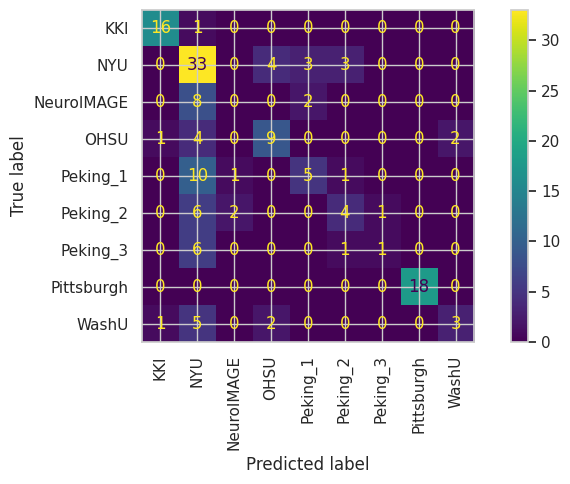

In [457]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    harmonized_df[harmonize_features],
    harmonized_df["site"],
    test_size=0.2,
    stratify=harmonized_df["site"],
    random_state=42,
)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.tight_layout()
plt.show()

In [458]:
importance = pd.DataFrame({
    "Feature": harmonize_features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

,Feature,Importance
3,dwell_state0,0.161496
1,occupancy_state1,0.141670
4,dwell_state1,0.140292
0,occupancy_state0,0.137573
6,switching_rate,0.109863
7,transition_entropy,0.108425
5,dwell_state2,0.104950
2,occupancy_state2,0.095730


In [459]:
site_results.to_csv(
    OUTPUT_DIR / "rf_site_validation.csv",
    index=False
)
diagnosis_results.to_csv(
    OUTPUT_DIR / "rf_diagnosis_validation.csv",
    index=False
)
display(site_results)
display(diagnosis_results)

,Metric,Before,After,Reduction
0,Accuracy,0.565454,0.569384,-0.003930
1,Balanced Accuracy,0.453063,0.462250,-0.009186


,Metric,Before,After,Difference
0,Accuracy,0.625645,0.675353,0.049708
1,Balanced Accuracy,0.569844,0.618842,0.048998
2,Precision,0.482716,0.587959,0.105242
3,Recall,0.360714,0.407143,0.046429
4,F1,0.411263,0.479614,0.068351


In [460]:
summary = pd.DataFrame({
    "Validation Metric":[
        "Mean Eta²",
        "Significant Site Features",
        "Correlation Preservation",
        "RF Site Accuracy",
        "RF Diagnosis Accuracy"
    ],
    "Before":[
        comparison["Eta²"].mean(),
        (comparison["p-value"]<0.05).sum(),
        np.nan,
        site_results.loc[
            site_results.Metric=="Accuracy",
            "Before"
        ].iloc[0],
        diagnosis_results.loc[
            diagnosis_results.Metric=="Accuracy",
            "Before"
        ].iloc[0]
    ],
    "After":[
        comparison["Eta2_after"].mean(),
        (comparison["p_after"]<0.05).sum(),
        r,
        site_results.loc[
            site_results.Metric=="Accuracy",
            "After"
        ].iloc[0],
        diagnosis_results.loc[
            diagnosis_results.Metric=="Accuracy",
            "After"
        ].iloc[0]
    ]
})

summary

,Validation Metric,Before,After
0,Mean Eta²,0.389171,0.002373
1,Significant Site Features,8.000000,1.000000
2,Correlation Preservation,NaN,0.966079
3,RF Site Accuracy,0.565454,0.569384
4,RF Diagnosis Accuracy,0.625645,0.675353


In [461]:
comparison = pd.DataFrame({
    "Raw Mean": dynamic_df[harmonize_features].mean(),
    "Combat Mean": harmonized_df[harmonize_features].mean(),
    "Difference": (
        harmonized_df[harmonize_features].mean()
        -
        dynamic_df[harmonize_features].mean()
    )
})

display(comparison)

,Raw Mean,Combat Mean,Difference
occupancy_state0,0.490484,0.490632,0.000148
occupancy_state1,0.273182,0.270875,-0.002307
occupancy_state2,0.236334,0.236797,0.000462
dwell_state0,6.235832,6.234687,-0.001145
dwell_state1,3.435935,3.407552,-0.028382
dwell_state2,2.829163,2.836111,0.006948
switching_rate,0.204769,0.206013,0.001244
transition_entropy,0.692535,0.697925,0.005390


# Residual Site Information Analysis

The previous analyses demonstrated a substantial reduction in feature-wise site effects following ComBat harmonization.

However, Random Forest site prediction remained above chance.

This section investigates whether the remaining site information arises from:

- individual biomarkers,
- linear multivariate structure, or
- higher-order nonlinear interactions.

Three complementary analyses are performed:

1. Single-feature Random Forest classification.
2. Linear Discriminant Analysis (LDA).
3. Pairwise site centroid distance analysis.

In [462]:
from sklearn.model_selection import cross_val_score
single_feature_results = []
for feature in harmonize_features:
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    before = cross_val_score(
        rf,
        dynamic_df[[feature]],
        dynamic_df["site"],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    after = cross_val_score(
        rf,
        harmonized_df[[feature]],
        harmonized_df["site"],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    single_feature_results.append({
        "Feature": feature,
        "Before": before.mean(),
        "After": after.mean(),
        "Reduction": before.mean() - after.mean()
    })
single_feature_results = pd.DataFrame(single_feature_results)
display(single_feature_results)

/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nvidia/.venv/lib/py

,Feature,Before,After,Reduction
0,occupancy_state0,0.706871,0.751350,-0.044479
1,occupancy_state1,0.679446,0.812840,-0.133394
2,occupancy_state2,0.709451,0.853466,-0.144014
3,dwell_state0,0.367793,0.549682,-0.181889
4,dwell_state1,0.434598,0.709434,-0.274837
5,dwell_state2,0.303655,0.666280,-0.362625
6,switching_rate,0.683239,0.907052,-0.223813
7,transition_entropy,0.336352,0.270958,0.065394


In [464]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

feature = "switching_rate"

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf,
    dynamic_df[[feature]],
    dynamic_df["site"],
    cv=cv,
    scoring="accuracy"
)

print(scores)
print("Mean:", scores.mean())
print("Std :", scores.std())

[0.70588235 0.62745098 0.70588235 0.69934641 0.67763158]
Mean: 0.6832387340901274
Std : 0.029761174944258655


In [465]:
site_feature_summary = (
    dynamic_df
    .groupby("site")[harmonize_features]
    .mean()
)
site_feature_summary_combat = (
    harmonized_df
    .groupby("site")[harmonize_features]
    .mean()
)

for feature in harmonize_features:

    print("\n" + "="*70)
    print(feature)
    print("="*70)

    temp = pd.DataFrame({
        "Before": site_feature_summary[feature],
        "After": site_feature_summary_combat[feature]
    })
    temp["Difference"] = temp["After"] - temp["Before"]
    display(temp)


occupancy_state0


,Before,After,Difference
site,,,
KKI,0.855078,0.495672,-0.359407
NYU,0.473536,0.484842,0.011305
NeuroIMAGE,0.544837,0.490147,-0.054690
OHSU,0.592358,0.497386,-0.094972
Peking_1,0.514491,0.491767,-0.022724
Peking_2,0.454678,0.478594,0.023917
Peking_3,0.371661,0.476057,0.104396
Pittsburgh,0.000000,0.498798,0.498798
WashU,0.687622,0.506771,-0.180851



occupancy_state1


,Before,After,Difference
site,,,
KKI,0.004809,0.270085,0.265276
NYU,0.241620,0.275865,0.034245
NeuroIMAGE,0.220109,0.266476,0.046368
OHSU,0.147562,0.272640,0.125078
Peking_1,0.243329,0.267551,0.024223
Peking_2,0.280306,0.274434,-0.005872
Peking_3,0.347271,0.278373,-0.068898
Pittsburgh,0.864325,0.264519,-0.599807
WashU,0.070728,0.259519,0.188792



occupancy_state2


...

,Before,After,Difference
site,,,
KKI,1.947791,2.820892,0.873100
NYU,3.347367,2.853426,-0.493941
NeuroIMAGE,3.858333,2.961643,-0.896690
OHSU,1.866034,2.836578,0.970544
Peking_1,2.895266,2.808761,-0.086505
Peking_2,3.100569,2.829255,-0.271313
Peking_3,3.020692,2.817156,-0.203536
Pittsburgh,2.246402,2.793169,0.546768
WashU,2.967105,2.815712,-0.151393



switching_rate


,Before,After,Difference
site,,,
KKI,0.089867,0.203482,0.113616
NYU,0.253571,0.207303,-0.046269
NeuroIMAGE,0.226389,0.206599,-0.019790
OHSU,0.187157,0.206236,0.019079
Peking_1,0.256765,0.206623,-0.050142
Peking_2,0.261567,0.210291,-0.051276
Peking_3,0.288095,0.209874,-0.078221
Pittsburgh,0.099787,0.202039,0.102252
WashU,0.150585,0.201383,0.050798



transition_entropy


,Before,After,Difference
site,,,
KKI,0.297222,0.687129,0.389907
NYU,0.853401,0.702213,-0.151188
NeuroIMAGE,0.892276,0.719145,-0.173130
OHSU,0.375759,0.688197,0.312438
Peking_1,0.949984,0.704501,-0.245483
Peking_2,0.919146,0.717288,-0.201858
Peking_3,0.985029,0.711889,-0.273140
Pittsburgh,0.434237,0.680531,0.246294
WashU,0.465200,0.677085,0.211885


In [467]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

lda = LinearDiscriminantAnalysis()

scores_before = cross_val_score(
    lda,
    dynamic_df[harmonize_features],
    dynamic_df["site"],
    cv=cv,
    scoring="accuracy"
)

scores_after = cross_val_score(
    lda,
    harmonized_df[harmonize_features],
    harmonized_df["site"],
    cv=cv,
    scoring="accuracy"
)

print("Before:", scores_before)
print("Mean Before:", scores_before.mean())

print()

print("After:", scores_after)
print("Mean After:", scores_after.mean())

Before: [0.54901961 0.53594771 0.5620915  0.53594771 0.57236842]
Mean Before: 0.5510749914000688

After: [0.26143791 0.28104575 0.28104575 0.28104575 0.27631579]
Mean After: 0.27617819057447546
